In [ ]:
import os
import numpy as np
import scipy.io as sio
import pickle
import re

# Percorsi delle cartelle
cartella_base = "C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020"
cartella_dati = os.path.join(cartella_base, "OUTPUT_1")
cartella_output = os.path.join(cartella_base, "Dati_processati")
cartella_maschere = os.path.join(cartella_base, "MASCHERE")

# === INIZIALIZZA DIZIONARIO PER I DATI ===
dati_concatenati = {}

# === FUNZIONE PER ESTRARE DOY E ORA DAL NOME DEL FILE ===
def estrai_doy_time(nome_file):
    # Supponiamo che il formato del nome del file sia qualcosa come 'DOY123_TIME45.mat'
    match = re.search(r"DOY(\d+)_TIME(\d+)", nome_file)
    if match:
        doy = int(match.group(1))
        time = int(match.group(2))
        return doy, time
    return float('inf'), float('inf')  # Restituisce valori molto alti se non trova match

# === CREATI LA CARTELLA DI OUTPUT SE NON ESISTE ===
os.makedirs(cartella_output, exist_ok=True)

# === CARICA E ORDINA I FILE ===
# Ottieni i file .mat e ordina in base a DOY e TIME
file_ordinati = sorted(
    [f for f in os.listdir(cartella_dati) if f.endswith('.mat')],
    key=lambda x: estrai_doy_time(x)
)

# === CARICAMENTO E CONCATENAZIONE DEI DATI ===
print("Caricamento e concatenazione dei dati...")
for filename in file_ordinati:
    filepath = os.path.join(cartella_dati, filename)
    #print(f"Caricando file: {filename}")
    dati_mat = sio.loadmat(filepath)

    # Concatenazione dei dati
    for chiave, valore in dati_mat.items():
        if chiave.startswith('__'):
            continue  # Salta le chiavi di sistema di MATLAB (__header__, __globals__, ecc.)

        valore = valore.flatten()

        # Aggiungi i dati al dizionario
        if chiave not in dati_concatenati:
            dati_concatenati[chiave] = [valore]
        else:
            dati_concatenati[chiave].append(valore)

# === RISULTATO ===
print(f"Numero totale di chiavi di dati caricati: {len(dati_concatenati)}")
# Unisci tutti i dati per ogni chiave
for chiave in dati_concatenati:
    dati_concatenati[chiave] = np.concatenate(dati_concatenati[chiave])

print("Tutti i dati caricati e concatenati.")

# Estrai la matrice DPR (precipitazione) e salva in un file pickle
DPR_raw = dati_concatenati['dpr']
print("📊 DPR grezzo dal .mat:", DPR_raw.shape, DPR_raw.dtype)
DPR = np.vstack(DPR_raw)
print("📊 DPR dopo vstack:", DPR.shape, DPR.dtype)
with open(os.path.join(cartella_output, 'DPR.pickle'), 'wb') as file:
    pickle.dump(DPR, file)
print("✅ DPR salvato in", cartella_output)

LAT = dati_concatenati['12']
print("📊 LAT grezzo dal .mat:", LAT.shape, LAT.dtype)
LAT = np.vstack(LAT)
print("📊 LONG dopo vstack:", LAT.shape, LAT.dtype)
with open(os.path.join(cartella_output, 'LAT.pickle'), 'wb') as file:
    pickle.dump(LAT, file)
print("✅ LAT salvato in", cartella_output)

LONG = dati_concatenati['13']
print("📊 LONG grezzo dal .mat:", LONG.shape, LONG.dtype)
LONG = np.vstack(LONG)
print("📊 LONG dopo vstack:", LONG.shape, LONG.dtype)
with open(os.path.join(cartella_output, 'LONG.pickle'), 'wb') as file:
    pickle.dump(LONG, file)
print("✅ LONG salvato in", cartella_output)

DAY = dati_concatenati['dayOfYear']
print("📊 DAY grezzo dal .mat:", DAY.shape, DAY.dtype)
DAY = np.vstack(DAY)
print("📊 DAY dopo vstack:", DAY.shape, DAY.dtype)
with open(os.path.join(cartella_output, 'DAY.pickle'), 'wb') as file:
    pickle.dump(DAY, file)
print("✅ DAY salvato in", cartella_output)

TIME = dati_concatenati['iTmOfDay']
print("📊 TIME grezzo dal .mat:", TIME.shape, TIME.dtype)
TIME = np.vstack(TIME)
print("📊 TIME dopo vstack:", TIME.shape, TIME.dtype)
with open(os.path.join(cartella_output, 'TIME.pickle'), 'wb') as file:
    pickle.dump(TIME, file)
print("✅ TIME salvato in", cartella_output)


# Ricarica DPR per verifica
dpr_test = pickle.load(open(os.path.join(cartella_output, 'DPR.pickle'), 'rb'))
print("🔄 DPR ricaricato:", dpr_test.shape)

# Salvataggio separato per ogni canale CH_1, CH_2, ..., CH_11
for chiave in range(1, 12):
    chiave_str = str(chiave)
    
    if chiave_str in dati_concatenati:  # Controllo se il canale esiste nei dati
        dati_chiave_raw = dati_concatenati[chiave_str]
        print(f"📊 CH_{chiave} grezzo dal .mat:", dati_chiave_raw.shape, dati_chiave_raw.dtype)
        dati_chiave = np.vstack(dati_chiave_raw)
        print(f"📊 CH_{chiave} dopo vstack:", dati_chiave.shape, dati_chiave.dtype)
        
        # Salva ogni canale come file separato
        file_pickle = os.path.join(cartella_output, f'CH_{chiave}.pickle')
        with open(file_pickle, 'wb') as file:
            pickle.dump(dati_chiave, file)
        print(f"✅ CH_{chiave} salvato in", cartella_output)
        
        # Ricarica per verifica
        ch_test = pickle.load(open(file_pickle, 'rb'))
        print(f"🔄 CH_{chiave} ricaricato:", ch_test.shape)
    else:
        print(f"⚠️ Canale {chiave} non trovato nei dati, saltato.")

# Caricamento e salvataggio delle maschere giorno e notte
maschere = {
    "giorno": "giorno_maschera_3h.mat",
    "notte": "notte_maschera_3h.mat"
}

for nome, file_maschera in maschere.items():
    file_path = os.path.join(cartella_maschere, file_maschera)
    if os.path.exists(file_path):
        mat_data = sio.loadmat(file_path)
        print(f"🔍 Chiavi disponibili in {file_maschera}:", mat_data.keys())  # Debug
        
        # Trova la chiave corretta evitando '__header__', '__version__', '__globals__'
        chiavi_utili = [k for k in mat_data.keys() if not k.startswith('__')]
        if chiavi_utili:
            maschera = mat_data[chiavi_utili[0]]  # Prende la prima chiave valida
            print(f"📊 Maschera {nome} prima del salvataggio:", maschera.shape, maschera.dtype)
            
            with open(os.path.join(cartella_output, f'{nome}_maschera.pickle'), 'wb') as file:
                pickle.dump(maschera, file)
            print(f"✅ Maschera {nome} salvata in", cartella_output)
            
            # Ricarica per verifica
            maschera_test = pickle.load(open(os.path.join(cartella_output, f'{nome}_maschera.pickle'), 'rb'))
            print(f"🔄 Maschera {nome} ricaricata:", maschera_test.shape)
        else:
            print(f"⚠️ Nessuna chiave utile trovata in {file_maschera}.")
    else:
        print(f"⚠️ Maschera {nome} non trovata, saltata.")

# Aggiunto caricamento e salvataggio maschere aggiuntive
maschere_aggiuntive = {
    "Terra_mask_regridded": "Terra_mask_regridded.mat",
    "Mare_mask_regridded": "Mare_mask_regridded.mat",
    "stagionalita_maschera_estate_inverno": "stagionalita_maschera_estate_inverno.mat"
}

for nome, file_maschera in maschere_aggiuntive.items():
    file_path = os.path.join(cartella_maschere, file_maschera)
    if os.path.exists(file_path):
        mat_data = sio.loadmat(file_path)
        print(f"🔍 Chiavi disponibili in {file_maschera}:", mat_data.keys())  # Debug
        
        # Trova la chiave corretta evitando '__header__', '__version__', '__globals__'
        chiavi_utili = [k for k in mat_data.keys() if not k.startswith('__')]
        if chiavi_utili:
            maschera = mat_data[chiavi_utili[0]]  # Prende la prima chiave valida
            print(f"📊 Maschera {nome} prima del salvataggio:", maschera.shape, maschera.dtype)
            
            with open(os.path.join(cartella_output, f'{nome}_maschera.pickle'), 'wb') as file:
                pickle.dump(maschera, file)
            print(f"✅ Maschera {nome} salvata in", cartella_output)
            
            # Ricarica per verifica
            maschera_test = pickle.load(open(os.path.join(cartella_output, f'{nome}_maschera.pickle'), 'rb'))
            print(f"🔄 Maschera {nome} ricaricata:", maschera_test.shape)
        else:
            print(f"⚠️ Nessuna chiave utile trovata in {file_maschera}.")
    else:
        print(f"⚠️ Maschera {nome} non trovata, saltata.")

print("\n🎉 Tutti i file sono stati salvati correttamente!")

In [2]:
############### FILTRO I DATI PICKLE ################

import os
import pickle
import numpy as np

# Directory di input/output
cartella_input = "C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_processati"
#bilanciamento_4classi = "C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_processati/bilanciamento_4classi"

#os.makedirs(bilanciamento_4classi, exist_ok=True)  # Salvo nella stessa cartella

# Carica i dati da ciascun file pickle
file_names = [
    'DPR.pickle', 'CH_1.pickle', 'CH_2.pickle', 'CH_3.pickle', 'CH_4.pickle',
    'CH_5.pickle', 'CH_6.pickle', 'CH_7.pickle', 'CH_8.pickle', 'CH_9.pickle',
    'CH_10.pickle', 'CH_11.pickle', 'giorno_maschera.pickle', 'notte_maschera.pickle'
]

# Aggiungi le maschere extra (già in formato pickle con _maschera)
maschere_extra_pickle = [
    'Terra_mask_regridded_maschera.pickle', 'stagionalita_maschera_estate_inverno_maschera.pickle', 'Mare_mask_regridded_maschera.pickle'
]

file_names.extend(maschere_extra_pickle)

loaded_data = {}

# Carica tutti i file pickle
for file_name in file_names:
    file_path = os.path.join(cartella_input, file_name)
    if os.path.exists(file_path):
        with open(file_path, 'rb') as f:
            loaded_data[file_name.split('.')[0]] = pickle.load(f)
        # Stampa la dimensione dei dati caricati
        if isinstance(loaded_data[file_name.split('.')[0]], np.ndarray):
            print(f"{file_name} caricato con {loaded_data[file_name.split('.')[0]].shape}")
        else:
            print(f"{file_name} caricato.")
    else:
        print(f"⚠️ Il file {file_name} non esiste nella cartella di input.")

# Filtraggio dei dati

DPR = loaded_data.pop('DPR')
CH_1 = loaded_data.pop('CH_1')
CH_2 = loaded_data.pop('CH_2')
CH_3 = loaded_data.pop('CH_3')
CH_4 = loaded_data.pop('CH_4')
CH_5 = loaded_data.pop('CH_5')
CH_6 = loaded_data.pop('CH_6')
CH_7 = loaded_data.pop('CH_7')
CH_8 = loaded_data.pop('CH_8')
CH_9 = loaded_data.pop('CH_9')
CH_10 = loaded_data.pop('CH_10')
CH_11 = loaded_data.pop('CH_11')
GIORNO_maschera = loaded_data.pop('giorno_maschera')
NOTTE_maschera = loaded_data.pop('notte_maschera')

# Maschere extra con i nuovi nomi
TERRA_maschera = loaded_data.pop('Terra_mask_regridded_maschera', None)
STAGIONI_maschera = loaded_data.pop('stagionalita_maschera_estate_inverno_maschera', None)
MARE_maschera = loaded_data.pop('Mare_mask_regridded_maschera', None)

# Da DPR seleziono gli indici in anticipo
DPR = DPR.astype(np.float16)
DPR = DPR.flatten()

# Trova gli indici da eliminare (NaN e valori minori di zero)
indici_nan = np.where(np.isnan(DPR))[0]
indici_minori_di_zero = np.where(DPR < 0)[0]

# Carica CH_4 per individuare i valori errati
CH_4 = CH_4.astype(np.float16)
CH_4 = CH_4.flatten()

# Trova gli indici errati in CH_4 (valori < 0)
indici_errati_ch4 = np.where(CH_4 < 0)[0]

# Concateno gli indici da eliminare (NaN, valori minori di zero, errati in CH_4)
indici_da_eliminare = np.unique(np.concatenate((indici_nan, indici_minori_di_zero, indici_errati_ch4)))

# Applica il filtro a tutte le variabili
DPR = np.delete(DPR, indici_da_eliminare)

CH_1 = CH_1.astype(np.float16)
CH_1 = CH_1.flatten()
CH_1 = np.delete(CH_1, indici_da_eliminare)

CH_2 = CH_2.astype(np.float16)
CH_2 = CH_2.flatten()
CH_2 = np.delete(CH_2, indici_da_eliminare)

CH_3 = CH_3.astype(np.float16)
CH_3 = CH_3.flatten()
CH_3 = np.delete(CH_3, indici_da_eliminare)

CH_4 = CH_4.astype(np.float16)
CH_4 = CH_4.flatten()
CH_4 = np.delete(CH_4, indici_da_eliminare)

CH_5 = CH_5.astype(np.float16)
CH_5 = CH_5.flatten()
CH_5 = np.delete(CH_5, indici_da_eliminare)

CH_6 = CH_6.astype(np.float16)
CH_6 = CH_6.flatten()
CH_6 = np.delete(CH_6, indici_da_eliminare)

CH_7 = CH_7.astype(np.float16)
CH_7 = CH_7.flatten()
CH_7 = np.delete(CH_7, indici_da_eliminare)

CH_8 = CH_8.astype(np.float16)
CH_8 = CH_8.flatten()
CH_8 = np.delete(CH_8, indici_da_eliminare)

CH_9 = CH_9.astype(np.float16)
CH_9 = CH_9.flatten()
CH_9 = np.delete(CH_9, indici_da_eliminare)

CH_10 = CH_10.astype(np.float16)
CH_10 = CH_10.flatten()
CH_10 = np.delete(CH_10, indici_da_eliminare)

CH_11 = CH_11.astype(np.float16)
CH_11 = CH_11.flatten()
CH_11 = np.delete(CH_11, indici_da_eliminare)

GIORNO_maschera = GIORNO_maschera.flatten()
GIORNO_maschera = np.delete(GIORNO_maschera, indici_da_eliminare)

NOTTE_maschera = NOTTE_maschera.flatten()
NOTTE_maschera = np.delete(NOTTE_maschera, indici_da_eliminare)

if TERRA_maschera is not None:
    TERRA_maschera = TERRA_maschera.flatten()
    TERRA_maschera = np.delete(TERRA_maschera, indici_da_eliminare)

if STAGIONI_maschera is not None:
    STAGIONI_maschera = STAGIONI_maschera.flatten()
    STAGIONI_maschera = np.delete(STAGIONI_maschera, indici_da_eliminare)

if MARE_maschera is not None:
    MARE_maschera = MARE_maschera.flatten()
    MARE_maschera = np.delete(MARE_maschera, indici_da_eliminare)

# Salvataggio dei dati in formato pickle
with open(os.path.join(cartella_input, 'CH_1.pickle'), 'wb') as file:
    pickle.dump(CH_1, file)
with open(os.path.join(cartella_input, 'CH_2.pickle'), 'wb') as file:
    pickle.dump(CH_2, file)
with open(os.path.join(cartella_input, 'CH_3.pickle'), 'wb') as file:
    pickle.dump(CH_3, file)
with open(os.path.join(cartella_input, 'CH_4.pickle'), 'wb') as file:
    pickle.dump(CH_4, file)
with open(os.path.join(cartella_input, 'CH_5.pickle'), 'wb') as file:
    pickle.dump(CH_5, file)
with open(os.path.join(cartella_input, 'CH_6.pickle'), 'wb') as file:
    pickle.dump(CH_6, file)
with open(os.path.join(cartella_input, 'CH_7.pickle'), 'wb') as file:
    pickle.dump(CH_7, file)
with open(os.path.join(cartella_input, 'CH_8.pickle'), 'wb') as file:
    pickle.dump(CH_8, file)
with open(os.path.join(cartella_input, 'CH_9.pickle'), 'wb') as file:
    pickle.dump(CH_9, file)
with open(os.path.join(cartella_input, 'CH_10.pickle'), 'wb') as file:
    pickle.dump(CH_10, file)
with open(os.path.join(cartella_input, 'CH_11.pickle'), 'wb') as file:
    pickle.dump(CH_11, file)
with open(os.path.join(cartella_input, 'DPR.pickle'), 'wb') as file:
    pickle.dump(DPR, file)
with open(os.path.join(cartella_input, 'maschera_giorno.pickle'), 'wb') as file:
    pickle.dump(GIORNO_maschera, file)
with open(os.path.join(cartella_input, 'maschera_notte.pickle'), 'wb') as file:
    pickle.dump(NOTTE_maschera, file)

# Salvataggio delle maschere in formato pickle (già esistenti) con i nuovi nomi
if TERRA_maschera is not None:
    with open(os.path.join(cartella_input, 'TERRA_maschera.pickle'), 'wb') as file:
        pickle.dump(TERRA_maschera, file)
if STAGIONI_maschera is not None:
    with open(os.path.join(cartella_input, 'STAGIONI_maschera.pickle'), 'wb') as file:
        pickle.dump(STAGIONI_maschera, file)
if MARE_maschera is not None:
    with open(os.path.join(cartella_input, 'MARE_maschera.pickle'), 'wb') as file:
        pickle.dump(MARE_maschera, file)

print("Salvataggio completo.")

DPR.pickle caricato con (5898240, 1)
CH_1.pickle caricato con (5898240, 1)
CH_2.pickle caricato con (5898240, 1)
CH_3.pickle caricato con (5898240, 1)
CH_4.pickle caricato con (5898240, 1)
CH_5.pickle caricato con (5898240, 1)
CH_6.pickle caricato con (5898240, 1)
CH_7.pickle caricato con (5898240, 1)
CH_8.pickle caricato con (5898240, 1)
CH_9.pickle caricato con (5898240, 1)
CH_10.pickle caricato con (5898240, 1)
CH_11.pickle caricato con (5898240, 1)
giorno_maschera.pickle caricato con (1, 5898240)
notte_maschera.pickle caricato con (1, 5898240)
Terra_mask_regridded_maschera.pickle caricato con (1, 5898240)
stagionalita_maschera_estate_inverno_maschera.pickle caricato con (1, 5898240)
Mare_mask_regridded_maschera.pickle caricato con (1, 5898240)
Salvataggio completo.


In [4]:
############## provo una nuova filtratura ################

import os
import pickle
import numpy as np

# Directory di input/output
cartella_input = "C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_processati"
#bilanciamento_4classi = "C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_processati/bilanciamento_4classi"

#os.makedirs(bilanciamento_4classi, exist_ok=True)  # Salvo nella stessa cartella

# Carica i dati da ciascun file pickle
file_names = [
    'DPR.pickle', 'CH_1.pickle', 'CH_2.pickle', 'CH_3.pickle', 'CH_4.pickle',
    'CH_5.pickle', 'CH_6.pickle', 'CH_7.pickle', 'CH_8.pickle', 'CH_9.pickle',
    'CH_10.pickle', 'CH_11.pickle', 'giorno_maschera.pickle', 'notte_maschera.pickle'
]

# Aggiungi le maschere extra (già in formato pickle con _maschera)
maschere_extra_pickle = [
    'Terra_mask_regridded_maschera.pickle', 'stagionalita_maschera_estate_inverno_maschera.pickle', 'Mare_mask_regridded_maschera.pickle'
]

file_names.extend(maschere_extra_pickle)

loaded_data = {}

# Carica tutti i file pickle
for file_name in file_names:
    file_path = os.path.join(cartella_input, file_name)
    if os.path.exists(file_path):
        with open(file_path, 'rb') as f:
            loaded_data[file_name.split('.')[0]] = pickle.load(f)
        # Stampa la dimensione dei dati caricati
        if isinstance(loaded_data[file_name.split('.')[0]], np.ndarray):
            print(f"{file_name} caricato con {loaded_data[file_name.split('.')[0]].shape}")
        else:
            print(f"{file_name} caricato.")
    else:
        print(f"⚠️ Il file {file_name} non esiste nella cartella di input.")

# Filtraggio dei dati

DPR = loaded_data.pop('DPR')
CH_1 = loaded_data.pop('CH_1')
CH_2 = loaded_data.pop('CH_2')
CH_3 = loaded_data.pop('CH_3')
CH_4 = loaded_data.pop('CH_4')
CH_5 = loaded_data.pop('CH_5')
CH_6 = loaded_data.pop('CH_6')
CH_7 = loaded_data.pop('CH_7')
CH_8 = loaded_data.pop('CH_8')
CH_9 = loaded_data.pop('CH_9')
CH_10 = loaded_data.pop('CH_10')
CH_11 = loaded_data.pop('CH_11')
GIORNO_maschera = loaded_data.pop('giorno_maschera')
NOTTE_maschera = loaded_data.pop('notte_maschera')

# Maschere extra con i nuovi nomi
TERRA_maschera = loaded_data.pop('Terra_mask_regridded_maschera', None)
STAGIONI_maschera = loaded_data.pop('stagionalita_maschera_estate_inverno_maschera', None)
MARE_maschera = loaded_data.pop('Mare_mask_regridded_maschera', None)

def sostituisci_valori_invalidi(arr, mask_invalidi):
    # Flatten entrambi
    arr = arr.flatten()
    mask_invalidi = mask_invalidi.flatten()

    # Crea maschera dei validi
    validi = ~mask_invalidi

    if not np.any(validi):
        # Se non ci sono valori validi, ritorna l'array originale
        return arr.reshape(mask_invalidi.shape)

    # Trova indici e valori validi
    indici = np.arange(len(arr))
    indici_validi = indici[validi]
    valori_validi = arr[validi]

    # Interpolazione dei valori invalidi
    arr[mask_invalidi] = np.interp(indici[mask_invalidi], indici_validi, valori_validi)

    return arr


# Maschere booleane dei valori non validi
maschera_nan_dpr = np.isnan(DPR)
maschera_neg_dpr = DPR < 0
maschera_err_ch4 = CH_4 < 0

# Maschera complessiva dei valori da sostituire
maschera_non_valida = maschera_nan_dpr | maschera_neg_dpr | maschera_err_ch4

# Sostituisci i valori non validi in DPR e in ogni canale
DPR = sostituisci_valori_invalidi(DPR, maschera_non_valida)

for ch in ['CH_1', 'CH_2', 'CH_3', 'CH_4', 'CH_5', 'CH_6', 'CH_7', 'CH_8', 'CH_9', 'CH_10', 'CH_11']:
    arr = eval(ch).flatten().astype(np.float16)
    arr = sostituisci_valori_invalidi(arr, maschera_non_valida)
    globals()[ch] = arr

# Anche le maschere
GIORNO_maschera = sostituisci_valori_invalidi(GIORNO_maschera.flatten(), maschera_non_valida)
NOTTE_maschera = sostituisci_valori_invalidi(NOTTE_maschera.flatten(), maschera_non_valida)

if TERRA_maschera is not None:
    TERRA_maschera = sostituisci_valori_invalidi(TERRA_maschera.flatten(), maschera_non_valida)
if STAGIONI_maschera is not None:
    STAGIONI_maschera = sostituisci_valori_invalidi(STAGIONI_maschera.flatten(), maschera_non_valida)
if MARE_maschera is not None:
    MARE_maschera = sostituisci_valori_invalidi(MARE_maschera.flatten(), maschera_non_valida)

# Salvataggio dei dati in formato pickle
with open(os.path.join(cartella_input, 'CH_1.pickle'), 'wb') as file:
    pickle.dump(CH_1, file)
with open(os.path.join(cartella_input, 'CH_2.pickle'), 'wb') as file:
    pickle.dump(CH_2, file)
with open(os.path.join(cartella_input, 'CH_3.pickle'), 'wb') as file:
    pickle.dump(CH_3, file)
with open(os.path.join(cartella_input, 'CH_4.pickle'), 'wb') as file:
    pickle.dump(CH_4, file)
with open(os.path.join(cartella_input, 'CH_5.pickle'), 'wb') as file:
    pickle.dump(CH_5, file)
with open(os.path.join(cartella_input, 'CH_6.pickle'), 'wb') as file:
    pickle.dump(CH_6, file)
with open(os.path.join(cartella_input, 'CH_7.pickle'), 'wb') as file:
    pickle.dump(CH_7, file)
with open(os.path.join(cartella_input, 'CH_8.pickle'), 'wb') as file:
    pickle.dump(CH_8, file)
with open(os.path.join(cartella_input, 'CH_9.pickle'), 'wb') as file:
    pickle.dump(CH_9, file)
with open(os.path.join(cartella_input, 'CH_10.pickle'), 'wb') as file:
    pickle.dump(CH_10, file)
with open(os.path.join(cartella_input, 'CH_11.pickle'), 'wb') as file:
    pickle.dump(CH_11, file)
with open(os.path.join(cartella_input, 'DPR.pickle'), 'wb') as file:
    pickle.dump(DPR, file)
with open(os.path.join(cartella_input, 'maschera_giorno.pickle'), 'wb') as file:
    pickle.dump(GIORNO_maschera, file)
with open(os.path.join(cartella_input, 'maschera_notte.pickle'), 'wb') as file:
    pickle.dump(NOTTE_maschera, file)

# Salvataggio delle maschere in formato pickle (già esistenti) con i nuovi nomi
if TERRA_maschera is not None:
    with open(os.path.join(cartella_input, 'TERRA_maschera.pickle'), 'wb') as file:
        pickle.dump(TERRA_maschera, file)
if STAGIONI_maschera is not None:
    with open(os.path.join(cartella_input, 'STAGIONI_maschera.pickle'), 'wb') as file:
        pickle.dump(STAGIONI_maschera, file)
if MARE_maschera is not None:
    with open(os.path.join(cartella_input, 'MARE_maschera.pickle'), 'wb') as file:
        pickle.dump(MARE_maschera, file)

print("Salvataggio completo.")

DPR.pickle caricato con (5898240, 1)
CH_1.pickle caricato con (5898240, 1)
CH_2.pickle caricato con (5898240, 1)
CH_3.pickle caricato con (5898240, 1)
CH_4.pickle caricato con (5898240, 1)
CH_5.pickle caricato con (5898240, 1)
CH_6.pickle caricato con (5898240, 1)
CH_7.pickle caricato con (5898240, 1)
CH_8.pickle caricato con (5898240, 1)
CH_9.pickle caricato con (5898240, 1)
CH_10.pickle caricato con (5898240, 1)
CH_11.pickle caricato con (5898240, 1)
giorno_maschera.pickle caricato con (1, 5898240)
notte_maschera.pickle caricato con (1, 5898240)
Terra_mask_regridded_maschera.pickle caricato con (1, 5898240)
stagionalita_maschera_estate_inverno_maschera.pickle caricato con (1, 5898240)
Mare_mask_regridded_maschera.pickle caricato con (1, 5898240)
Salvataggio completo.


In [ ]:
################### FEATURES 4 CLASSI ###############

import os
import numpy as np
import pandas as pd
import pickle

cartella_input = r"C:\Users\user\Documents\TESI\datigrezzi\DATI_grezzi_2020/Dati_processati/bilanciamento_4classi"

# Caricamento dei file .pickle
file_names = [
    'CH_1.pickle', 'CH_2.pickle', 'CH_3.pickle', 'CH_4.pickle', 'CH_5.pickle',
    'CH_6.pickle', 'CH_7.pickle', 'CH_8.pickle', 'CH_9.pickle', 'CH_10.pickle',
    'CH_11.pickle', 'DPR.pickle', 'maschera_giorno.pickle', 'maschera_notte.pickle', 'TERRA_maschera.pickle', 'Mare_maschera.pickle', 'STAGIONI_maschera.pickle'
]

# Caricamento diretto dei file
for file_name in file_names:
    file_path = os.path.join(cartella_input, file_name)
    
    if os.path.exists(file_path):
        with open(file_path, 'rb') as file:
            if file_name == 'maschera_giorno.pickle':
                GIORNO_maschera = pickle.load(file)
                print("GIORNO_maschera caricato correttamente.")
            elif file_name == 'maschera_notte.pickle':
                NOTTE_maschera = pickle.load(file)
                print("NOTTE_maschera caricato correttamente.")
            elif file_name == 'DPR.pickle':
                DPR = pickle.load(file)
                print("DPR caricato correttamente.")
            elif file_name == 'TERRA_maschera.pickle':
                TERRA_maschera = pickle.load(file)
                print("TERRA_maschera caricato correttamente.")
            elif file_name == 'Mare_maschera.pickle':
                Mare_maschera = pickle.load(file)
                print("Mare_maschera caricato correttamente.")
            elif file_name == 'STAGIONI_maschera.pickle':
                STAGIONI_maschera = pickle.load(file)
                print("STAGIONI_maschera caricato correttamente.")
            else:
                # Carica i canali
                globals()[file_name.split('.')[0]] = pickle.load(file)
                print(f"{file_name} caricato correttamente.")
    else:
        print(f"{file_name} non trovato nella cartella.")

# Applicazione separata delle maschere

def applica_maschera_terra(canale, maschera_terra):
    """
    Applica la maschera TERRA al canale (Terra = 1).
    """
    return np.where(maschera_terra == 1, canale, 0)

def applica_maschera_mare(canale, maschera_mare):
    """
    Applica la maschera MARE al canale (Mare = 1).
    """
    return np.where(maschera_mare == 1, canale, 0)

def applica_maschera_stagioni(canale, maschera_stagioni):
    """
    Restituisce due versioni del canale:
    - canale_estate: valori del canale dove la maschera è 0 (estate), 2 altrove
    - canale_inverno: valori del canale dove la maschera è 1 (inverno), 2 altrove
    """
    canale_estate = np.where(maschera_stagioni == 0, canale, 0)
    canale_inverno = np.where(maschera_stagioni == 1, canale, 0)
    return canale_estate, canale_inverno



CH_1_terra = applica_maschera_terra(CH_1, TERRA_maschera)
CH_1_mare = applica_maschera_mare(CH_1, Mare_maschera)
CH_1_estate, CH_1_inverno = applica_maschera_stagioni(CH_1, STAGIONI_maschera)

CH_2_terra = applica_maschera_terra(CH_2, TERRA_maschera)
CH_2_mare = applica_maschera_mare(CH_2, Mare_maschera)
CH_2_estate, CH_2_inverno = applica_maschera_stagioni(CH_2, STAGIONI_maschera)

CH_3_terra = applica_maschera_terra(CH_3, TERRA_maschera)
CH_3_mare = applica_maschera_mare(CH_3, Mare_maschera)
CH_3_estate, CH_3_inverno = applica_maschera_stagioni(CH_3, STAGIONI_maschera)

CH_4_terra = applica_maschera_terra(CH_4, TERRA_maschera)
CH_4_mare = applica_maschera_mare(CH_4, Mare_maschera)
CH_4_estate, CH_4_inverno = applica_maschera_stagioni(CH_4, STAGIONI_maschera)

CH_5_terra = applica_maschera_terra(CH_5, TERRA_maschera)
CH_5_mare = applica_maschera_mare(CH_5, Mare_maschera)
CH_5_estate, CH_5_inverno = applica_maschera_stagioni(CH_5, STAGIONI_maschera)

CH_6_terra = applica_maschera_terra(CH_6, TERRA_maschera)
CH_6_mare = applica_maschera_mare(CH_6, Mare_maschera)
CH_6_estate, CH_6_inverno = applica_maschera_stagioni(CH_6, STAGIONI_maschera)

CH_7_terra = applica_maschera_terra(CH_7, TERRA_maschera)
CH_7_mare = applica_maschera_mare(CH_7, Mare_maschera)
CH_7_estate, CH_7_inverno = applica_maschera_stagioni(CH_7, STAGIONI_maschera)

CH_8_terra = applica_maschera_terra(CH_8, TERRA_maschera)
CH_8_mare = applica_maschera_mare(CH_8, Mare_maschera)
CH_8_estate, CH_8_inverno = applica_maschera_stagioni(CH_8, STAGIONI_maschera)

CH_9_terra = applica_maschera_terra(CH_9, TERRA_maschera)
CH_9_mare = applica_maschera_mare(CH_9, Mare_maschera)
CH_9_estate, CH_9_inverno = applica_maschera_stagioni(CH_9, STAGIONI_maschera)

CH_10_terra = applica_maschera_terra(CH_10, TERRA_maschera)
CH_10_mare = applica_maschera_mare(CH_10, Mare_maschera)
CH_10_estate, CH_10_inverno = applica_maschera_stagioni(CH_10, STAGIONI_maschera)

CH_11_terra = applica_maschera_terra(CH_11, TERRA_maschera)
CH_11_mare = applica_maschera_mare(CH_11, Mare_maschera)
CH_11_estate, CH_11_inverno = applica_maschera_stagioni(CH_11, STAGIONI_maschera)

DPR_terra = applica_maschera_terra(DPR, TERRA_maschera)
DPR_mare = applica_maschera_mare(DPR, Mare_maschera)
DPR_estate, DPR_inverno = applica_maschera_stagioni(DPR, STAGIONI_maschera)


def calcola_media_std_mobile(data, finestra_size):
    """
    Calcola la media mobile e la deviazione standard mobile per finestre di dimensioni definite.

    Argomenti:
        data: Un array contenente i dati.
        finestra_size: La dimensione della finestra mobile.

    Restituisce:
        La media mobile e la deviazione standard mobile per ogni finestra.
    """
    # Verifica la lunghezza originale del dato
    print(f"Lunghezza originale del dato: {len(data)}")

    mean_data = np.empty(len(data), dtype=np.float16)
    std_data = np.empty(len(data), dtype=np.float16)

    for i in range(len(data)):
        start_index = max(0, i - finestra_size // 2)
        end_index = min(len(data), i + finestra_size // 2 + 1)
        window_data = data[start_index:end_index]

        if len(window_data) < finestra_size:
            # Riempi con NaN se la finestra è troppo piccola
            mean_data[i] = np.nan
            std_data[i] = np.nan
        else:
            # Calcola la media e la std
            mean_data[i] = np.mean(window_data, dtype=np.float16)
            std_data[i] = np.std(window_data, dtype=np.float16)

    # Aggiungi il debug per visualizzare le prime 5 voci
    print(f"Media mobile (primi 5 valori): {mean_data[:5]}")
    print(f"Deviazione standard mobile (primi 5 valori): {std_data[:5]}")

    return mean_data, std_data

def replace_nans_with_nearest(data):
    """
    Sostituisce i valori NaN con il valore valido più vicino nell'array.
    """
    valid_indices = np.flatnonzero(~np.isnan(data))
    invalid_indices = np.flatnonzero(np.isnan(data))

    for idx in invalid_indices:
        closest_valid_index = valid_indices[np.abs(valid_indices - idx).argmin()]
        data[idx] = data[closest_valid_index]

    # Aggiungi il debug per vedere se i NaN sono stati sostituiti
    print(f"Valori dopo la sostituzione NaN (primi 5): {data[:5]}")
    return data

# Esegui il debug per verificare la lunghezza dei canali originali
print(f"Lunghezza di CH_1 originale: {len(CH_1)}")
print(f"Lunghezza di CH_2 originale: {len(CH_2)}")
# Ripeti per gli altri canali...
print(f"Lunghezza di CH_11 originale: {len(CH_11)}")

# Calcola le medie mobili e le deviazioni standard mobili per ogni canale
mean_CH_1, std_CH_1 = calcola_media_std_mobile(CH_1, 5)
mean_CH_2, std_CH_2 = calcola_media_std_mobile(CH_2, 5)
mean_CH_3, std_CH_3 = calcola_media_std_mobile(CH_3, 5)
mean_CH_4, std_CH_4 = calcola_media_std_mobile(CH_4, 5)
mean_CH_5, std_CH_5 = calcola_media_std_mobile(CH_5, 5)
mean_CH_6, std_CH_6 = calcola_media_std_mobile(CH_6, 5)
mean_CH_7, std_CH_7 = calcola_media_std_mobile(CH_7, 5)
mean_CH_8, std_CH_8 = calcola_media_std_mobile(CH_8, 5)
mean_CH_9, std_CH_9 = calcola_media_std_mobile(CH_9, 5)
mean_CH_10, std_CH_10 = calcola_media_std_mobile(CH_10, 5)
mean_CH_11, std_CH_11 = calcola_media_std_mobile(CH_11, 5)

# Verifica la lunghezza dopo il calcolo della media mobile
print(f"Lunghezza dopo la media mobile (CH_1): {len(mean_CH_1)}")
print(f"Lunghezza dopo la deviazione standard mobile (CH_1): {len(std_CH_1)}")
# Ripeti per gli altri canali...

# Applicazione della funzione di sostituzione per ogni canale
mean_CH_1 = replace_nans_with_nearest(mean_CH_1)
std_CH_1 = replace_nans_with_nearest(std_CH_1)
mean_CH_2 = replace_nans_with_nearest(mean_CH_2)
std_CH_2 = replace_nans_with_nearest(std_CH_2)
mean_CH_3 = replace_nans_with_nearest(mean_CH_3)
std_CH_3 = replace_nans_with_nearest(std_CH_3)
mean_CH_4 = replace_nans_with_nearest(mean_CH_4)
std_CH_4 = replace_nans_with_nearest(std_CH_4)
mean_CH_5 = replace_nans_with_nearest(mean_CH_5)
std_CH_5 = replace_nans_with_nearest(std_CH_5)
mean_CH_6 = replace_nans_with_nearest(mean_CH_6)
std_CH_6 = replace_nans_with_nearest(std_CH_6)
mean_CH_7 = replace_nans_with_nearest(mean_CH_7)
std_CH_7 = replace_nans_with_nearest(std_CH_7)
mean_CH_8 = replace_nans_with_nearest(mean_CH_8)
std_CH_8 = replace_nans_with_nearest(std_CH_8)
mean_CH_9 = replace_nans_with_nearest(mean_CH_9)
std_CH_9 = replace_nans_with_nearest(std_CH_9)
mean_CH_10 = replace_nans_with_nearest(mean_CH_10)
std_CH_10 = replace_nans_with_nearest(std_CH_10)
mean_CH_11 = replace_nans_with_nearest(mean_CH_11)
std_CH_11 = replace_nans_with_nearest(std_CH_11)

# Calcola le differenze tra i canali specificati
diff_CH_4_5 = CH_4 - CH_5
diff_CH_4_6 = CH_4 - CH_6
diff_CH_4_7 = CH_4 - CH_7
diff_CH_4_8 = CH_4 - CH_8
diff_CH_4_10 = CH_4 - CH_10
diff_CH_4_11 = CH_4 - CH_11

diff_CH_5_6 = CH_5 - CH_6
diff_CH_5_7 = CH_5 - CH_7
diff_CH_5_8 = CH_5 - CH_8
diff_CH_5_10 = CH_5 - CH_10
diff_CH_5_11 = CH_5 - CH_11

diff_CH_6_7 = CH_6 - CH_7
diff_CH_6_8 = CH_6 - CH_8
diff_CH_6_10 = CH_6 - CH_10
diff_CH_6_11 = CH_6 - CH_11

diff_CH_7_8 = CH_7 - CH_8
diff_CH_7_10 = CH_7 - CH_10
diff_CH_7_11 = CH_7 - CH_11

diff_CH_8_11 = CH_8 - CH_11
diff_CH_9_10 = CH_9 - CH_10
diff_CH_10_11 = CH_10 - CH_11

# Aggiungi il debug per vedere le differenze calcolate
print(f"Diff CH_4_5 (primi 5 valori): {diff_CH_4_5[:5]}")
print(f"Diff CH_4_6 (primi 5 valori): {diff_CH_4_6[:5]}")
print(f"Diff CH_5_6 (primi 5 valori): {diff_CH_5_6[:5]}")

channels = ['CH_1', 'CH_2', 'CH_3', 'CH_4', 'CH_5', 'CH_6', 'CH_7', 'CH_8', 'CH_9', 'CH_10', 'CH_11', 'DPR']
suffixes = ['_terra', '_mare', '_estate', '_inverno']

for channel in channels:
    for suffix in suffixes:
        var_name = f'{channel}{suffix}'
        var = globals().get(var_name)
        
        if var is not None:
            print(f"🔄 Correzione di {var_name}...")
            globals()[var_name] = replace_nans_with_nearest(var)
            print(f"✅ Variabile {var_name} corretta.")
            
            
import os
import pandas as pd
import pickle

# Nuova directory principale
directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus'

# Verifica se la directory esiste, se no la crea
if not os.path.exists(directory):
    os.makedirs(directory)

# Creazione del DataFrame
data = {
    # Canali
    'CH_1': CH_1, 'CH_1_terra': CH_1_terra, 'CH_1_mare': CH_1_mare, 'CH_1_estate': CH_1_estate, 'CH_1_inverno': CH_1_inverno,
    'CH_2': CH_2, 'CH_2_terra': CH_2_terra, 'CH_2_mare': CH_2_mare, 'CH_2_estate': CH_2_estate, 'CH_2_inverno': CH_2_inverno,
    'CH_3': CH_3, 'CH_3_terra': CH_3_terra, 'CH_3_mare': CH_3_mare, 'CH_3_estate': CH_3_estate, 'CH_3_inverno': CH_3_inverno,
    'CH_4': CH_4, 'CH_4_terra': CH_4_terra, 'CH_4_mare': CH_4_mare, 'CH_4_estate': CH_4_estate, 'CH_4_inverno': CH_4_inverno,
    'CH_5': CH_5, 'CH_5_terra': CH_5_terra, 'CH_5_mare': CH_5_mare, 'CH_5_estate': CH_5_estate, 'CH_5_inverno': CH_5_inverno,
    'CH_6': CH_6, 'CH_6_terra': CH_6_terra, 'CH_6_mare': CH_6_mare, 'CH_6_estate': CH_6_estate, 'CH_6_inverno': CH_6_inverno,
    'CH_7': CH_7, 'CH_7_terra': CH_7_terra, 'CH_7_mare': CH_7_mare, 'CH_7_estate': CH_7_estate, 'CH_7_inverno': CH_7_inverno,
    'CH_8': CH_8, 'CH_8_terra': CH_8_terra, 'CH_8_mare': CH_8_mare, 'CH_8_estate': CH_8_estate, 'CH_8_inverno': CH_8_inverno,
    'CH_9': CH_9, 'CH_9_terra': CH_9_terra, 'CH_9_mare': CH_9_mare, 'CH_9_estate': CH_9_estate, 'CH_9_inverno': CH_9_inverno,
    'CH_10': CH_10, 'CH_10_terra': CH_10_terra, 'CH_10_mare': CH_10_mare, 'CH_10_estate': CH_10_estate, 'CH_10_inverno': CH_10_inverno,
    'CH_11': CH_11, 'CH_11_terra': CH_11_terra, 'CH_11_mare': CH_11_mare, 'CH_11_estate': CH_11_estate, 'CH_11_inverno': CH_11_inverno,

    # Statistiche
    'mean_CH_1': mean_CH_1, 'std_CH_1': std_CH_1,
    'mean_CH_2': mean_CH_2, 'std_CH_2': std_CH_2,
    'mean_CH_3': mean_CH_3, 'std_CH_3': std_CH_3,
    'mean_CH_4': mean_CH_4, 'std_CH_4': std_CH_4,
    'mean_CH_5': mean_CH_5, 'std_CH_5': std_CH_5,
    'mean_CH_6': mean_CH_6, 'std_CH_6': std_CH_6,
    'mean_CH_7': mean_CH_7, 'std_CH_7': std_CH_7,
    'mean_CH_8': mean_CH_8, 'std_CH_8': std_CH_8,
    'mean_CH_9': mean_CH_9, 'std_CH_9': std_CH_9,
    'mean_CH_10': mean_CH_10, 'std_CH_10': std_CH_10,
    'mean_CH_11': mean_CH_11, 'std_CH_11': std_CH_11,

    # Differenze tra canali
    'diff_CH_4_5': diff_CH_4_5, 'diff_CH_4_6': diff_CH_4_6, 'diff_CH_4_7': diff_CH_4_7, 'diff_CH_4_8': diff_CH_4_8, 'diff_CH_4_10': diff_CH_4_10, 'diff_CH_4_11': diff_CH_4_11,
    'diff_CH_5_6': diff_CH_5_6, 'diff_CH_5_7': diff_CH_5_7, 'diff_CH_5_8': diff_CH_5_8, 'diff_CH_5_10': diff_CH_5_10, 'diff_CH_5_11': diff_CH_5_11,
    'diff_CH_6_7': diff_CH_6_7, 'diff_CH_6_8': diff_CH_6_8, 'diff_CH_6_10': diff_CH_6_10, 'diff_CH_6_11': diff_CH_6_11,
    'diff_CH_7_8': diff_CH_7_8, 'diff_CH_7_10': diff_CH_7_10, 'diff_CH_7_11': diff_CH_7_11,
    'diff_CH_9_10': diff_CH_9_10, 'diff_CH_8_11': diff_CH_8_11, 'diff_CH_10_11': diff_CH_10_11,

    # DPR
    #'DPR_terra': DPR_terra, 'DPR_mare': DPR_mare, 'DPR_estate': DPR_estate, 'DPR_inverno': DPR_inverno, 
}


print(f"Lunghezza CH_1 dataframe: {len(CH_1)}")
print(f"Lunghezza di CH_2 dataframe: {len(CH_2)}")
# Ripeti per gli altri canali...
print(f"Lunghezza di CH_11 dataframe: {len(CH_11)}")

df_features = pd.DataFrame(data)

# Salvo il dataframe delle features
with open(os.path.join(directory, 'df_features.pickle'), 'wb') as file:
    pickle.dump(df_features, file)

print('Il DataFrame è stato salvato in formato Pickle')

# Salvo DPR
with open(os.path.join(directory, 'DPR_ml.pickle'), 'wb') as file:
    pickle.dump(DPR, file)
    
print('DPR è stato salvato in formato Pickle')

# Salvo maschera giorno
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'wb') as file:
    pickle.dump(GIORNO_maschera, file)   
    
# Salvo maschera notte
with open(os.path.join(directory, 'maschera_notte_ml.pickle'), 'wb') as file:
    pickle.dump(NOTTE_maschera, file)

print('Maschere giorno e notte salvate in formato Pickle')

In [142]:
################### FEATURES 5 CLASSI ###############

import os
import numpy as np
import pandas as pd
import pickle

cartella_input = r"C:\Users\user\Documents\TESI\datigrezzi\DATI_grezzi_2020/Dati_processati"

# Caricamento dei file .pickle
file_names = [
    'CH_1.pickle', 'CH_2.pickle', 'CH_3.pickle', 'CH_4.pickle', 'CH_5.pickle',
    'CH_6.pickle', 'CH_7.pickle', 'CH_8.pickle', 'CH_9.pickle', 'CH_10.pickle',
    'CH_11.pickle', 'DPR.pickle', 'maschera_giorno.pickle', 'maschera_notte.pickle', 'TERRA_maschera.pickle', 'Mare_maschera.pickle', 'STAGIONI_maschera.pickle'
]

# Caricamento diretto dei file
for file_name in file_names:
    file_path = os.path.join(cartella_input, file_name)
    
    if os.path.exists(file_path):
        with open(file_path, 'rb') as file:
            if file_name == 'maschera_giorno.pickle':
                GIORNO_maschera = pickle.load(file)
                print("GIORNO_maschera caricato correttamente.")
            elif file_name == 'maschera_notte.pickle':
                NOTTE_maschera = pickle.load(file)
                print("NOTTE_maschera caricato correttamente.")
            elif file_name == 'DPR.pickle':
                DPR = pickle.load(file)
                print("DPR caricato correttamente.")
            elif file_name == 'TERRA_maschera.pickle':
                TERRA_maschera = pickle.load(file)
                print("TERRA_maschera caricato correttamente.")
            elif file_name == 'Mare_maschera.pickle':
                Mare_maschera = pickle.load(file)
                print("Mare_maschera caricato correttamente.")
            elif file_name == 'STAGIONI_maschera.pickle':
                STAGIONI_maschera = pickle.load(file)
                print("STAGIONI_maschera caricato correttamente.")
            else:
                # Carica i canali
                globals()[file_name.split('.')[0]] = pickle.load(file)
                print(f"{file_name} caricato correttamente.")
    else:
        print(f"{file_name} non trovato nella cartella.")

# Applicazione separata delle maschere

def applica_maschera_terra(canale, maschera_terra):
    """
    Applica la maschera TERRA al canale (Terra = 1).
    """
    return np.where(maschera_terra == 1, canale, 0)

def applica_maschera_mare(canale, maschera_mare):
    """
    Applica la maschera MARE al canale (Mare = 1).
    """
    return np.where(maschera_mare == 1, canale, 0)

def applica_maschera_stagioni(canale, maschera_stagioni):
    """
    Restituisce due versioni del canale:
    - canale_estate: valori del canale dove la maschera è 0 (estate), 2 altrove
    - canale_inverno: valori del canale dove la maschera è 1 (inverno), 2 altrove
    """
    canale_estate = np.where(maschera_stagioni == 0, canale, 0)
    canale_inverno = np.where(maschera_stagioni == 1, canale, 0)
    return canale_estate, canale_inverno



CH_1_terra = applica_maschera_terra(CH_1, TERRA_maschera)
CH_1_mare = applica_maschera_mare(CH_1, Mare_maschera)
CH_1_estate, CH_1_inverno = applica_maschera_stagioni(CH_1, STAGIONI_maschera)

CH_2_terra = applica_maschera_terra(CH_2, TERRA_maschera)
CH_2_mare = applica_maschera_mare(CH_2, Mare_maschera)
CH_2_estate, CH_2_inverno = applica_maschera_stagioni(CH_2, STAGIONI_maschera)

CH_3_terra = applica_maschera_terra(CH_3, TERRA_maschera)
CH_3_mare = applica_maschera_mare(CH_3, Mare_maschera)
CH_3_estate, CH_3_inverno = applica_maschera_stagioni(CH_3, STAGIONI_maschera)

CH_4_terra = applica_maschera_terra(CH_4, TERRA_maschera)
CH_4_mare = applica_maschera_mare(CH_4, Mare_maschera)
CH_4_estate, CH_4_inverno = applica_maschera_stagioni(CH_4, STAGIONI_maschera)

CH_5_terra = applica_maschera_terra(CH_5, TERRA_maschera)
CH_5_mare = applica_maschera_mare(CH_5, Mare_maschera)
CH_5_estate, CH_5_inverno = applica_maschera_stagioni(CH_5, STAGIONI_maschera)

CH_6_terra = applica_maschera_terra(CH_6, TERRA_maschera)
CH_6_mare = applica_maschera_mare(CH_6, Mare_maschera)
CH_6_estate, CH_6_inverno = applica_maschera_stagioni(CH_6, STAGIONI_maschera)

CH_7_terra = applica_maschera_terra(CH_7, TERRA_maschera)
CH_7_mare = applica_maschera_mare(CH_7, Mare_maschera)
CH_7_estate, CH_7_inverno = applica_maschera_stagioni(CH_7, STAGIONI_maschera)

CH_8_terra = applica_maschera_terra(CH_8, TERRA_maschera)
CH_8_mare = applica_maschera_mare(CH_8, Mare_maschera)
CH_8_estate, CH_8_inverno = applica_maschera_stagioni(CH_8, STAGIONI_maschera)

CH_9_terra = applica_maschera_terra(CH_9, TERRA_maschera)
CH_9_mare = applica_maschera_mare(CH_9, Mare_maschera)
CH_9_estate, CH_9_inverno = applica_maschera_stagioni(CH_9, STAGIONI_maschera)

CH_10_terra = applica_maschera_terra(CH_10, TERRA_maschera)
CH_10_mare = applica_maschera_mare(CH_10, Mare_maschera)
CH_10_estate, CH_10_inverno = applica_maschera_stagioni(CH_10, STAGIONI_maschera)

CH_11_terra = applica_maschera_terra(CH_11, TERRA_maschera)
CH_11_mare = applica_maschera_mare(CH_11, Mare_maschera)
CH_11_estate, CH_11_inverno = applica_maschera_stagioni(CH_11, STAGIONI_maschera)

DPR_terra = applica_maschera_terra(DPR, TERRA_maschera)
DPR_mare = applica_maschera_mare(DPR, Mare_maschera)
DPR_estate, DPR_inverno = applica_maschera_stagioni(DPR, STAGIONI_maschera)


def calcola_media_std_mobile(data, finestra_size):
    """
    Calcola la media mobile e la deviazione standard mobile per finestre di dimensioni definite.

    Argomenti:
        data: Un array contenente i dati.
        finestra_size: La dimensione della finestra mobile.

    Restituisce:
        La media mobile e la deviazione standard mobile per ogni finestra.
    """
    # Verifica la lunghezza originale del dato
    print(f"Lunghezza originale del dato: {len(data)}")

    mean_data = np.empty(len(data), dtype=np.float16)
    std_data = np.empty(len(data), dtype=np.float16)

    for i in range(len(data)):
        start_index = max(0, i - finestra_size // 2)
        end_index = min(len(data), i + finestra_size // 2 + 1)
        window_data = data[start_index:end_index]

        if len(window_data) < finestra_size:
            # Riempi con NaN se la finestra è troppo piccola
            mean_data[i] = np.nan
            std_data[i] = np.nan
        else:
            # Calcola la media e la std
            mean_data[i] = np.mean(window_data, dtype=np.float16)
            std_data[i] = np.std(window_data, dtype=np.float16)

    # Aggiungi il debug per visualizzare le prime 5 voci
    print(f"Media mobile (primi 5 valori): {mean_data[:5]}")
    print(f"Deviazione standard mobile (primi 5 valori): {std_data[:5]}")

    return mean_data, std_data

def replace_nans_with_nearest(data):
    """
    Sostituisce i valori NaN con il valore valido più vicino nell'array.
    """
    valid_indices = np.flatnonzero(~np.isnan(data))
    invalid_indices = np.flatnonzero(np.isnan(data))

    for idx in invalid_indices:
        closest_valid_index = valid_indices[np.abs(valid_indices - idx).argmin()]
        data[idx] = data[closest_valid_index]

    # Aggiungi il debug per vedere se i NaN sono stati sostituiti
    print(f"Valori dopo la sostituzione NaN (primi 5): {data[:5]}")
    return data

# Esegui il debug per verificare la lunghezza dei canali originali
print(f"Lunghezza di CH_1 originale: {len(CH_1)}")
print(f"Lunghezza di CH_2 originale: {len(CH_2)}")
# Ripeti per gli altri canali...
print(f"Lunghezza di CH_11 originale: {len(CH_11)}")

# Calcola le medie mobili e le deviazioni standard mobili per ogni canale
mean_CH_1, std_CH_1 = calcola_media_std_mobile(CH_1, 5)
mean_CH_2, std_CH_2 = calcola_media_std_mobile(CH_2, 5)
mean_CH_3, std_CH_3 = calcola_media_std_mobile(CH_3, 5)
mean_CH_4, std_CH_4 = calcola_media_std_mobile(CH_4, 5)
mean_CH_5, std_CH_5 = calcola_media_std_mobile(CH_5, 5)
mean_CH_6, std_CH_6 = calcola_media_std_mobile(CH_6, 5)
mean_CH_7, std_CH_7 = calcola_media_std_mobile(CH_7, 5)
mean_CH_8, std_CH_8 = calcola_media_std_mobile(CH_8, 5)
mean_CH_9, std_CH_9 = calcola_media_std_mobile(CH_9, 5)
mean_CH_10, std_CH_10 = calcola_media_std_mobile(CH_10, 5)
mean_CH_11, std_CH_11 = calcola_media_std_mobile(CH_11, 5)

# Verifica la lunghezza dopo il calcolo della media mobile
print(f"Lunghezza dopo la media mobile (CH_1): {len(mean_CH_1)}")
print(f"Lunghezza dopo la deviazione standard mobile (CH_1): {len(std_CH_1)}")
# Ripeti per gli altri canali...

# Applicazione della funzione di sostituzione per ogni canale
mean_CH_1 = replace_nans_with_nearest(mean_CH_1)
std_CH_1 = replace_nans_with_nearest(std_CH_1)
mean_CH_2 = replace_nans_with_nearest(mean_CH_2)
std_CH_2 = replace_nans_with_nearest(std_CH_2)
mean_CH_3 = replace_nans_with_nearest(mean_CH_3)
std_CH_3 = replace_nans_with_nearest(std_CH_3)
mean_CH_4 = replace_nans_with_nearest(mean_CH_4)
std_CH_4 = replace_nans_with_nearest(std_CH_4)
mean_CH_5 = replace_nans_with_nearest(mean_CH_5)
std_CH_5 = replace_nans_with_nearest(std_CH_5)
mean_CH_6 = replace_nans_with_nearest(mean_CH_6)
std_CH_6 = replace_nans_with_nearest(std_CH_6)
mean_CH_7 = replace_nans_with_nearest(mean_CH_7)
std_CH_7 = replace_nans_with_nearest(std_CH_7)
mean_CH_8 = replace_nans_with_nearest(mean_CH_8)
std_CH_8 = replace_nans_with_nearest(std_CH_8)
mean_CH_9 = replace_nans_with_nearest(mean_CH_9)
std_CH_9 = replace_nans_with_nearest(std_CH_9)
mean_CH_10 = replace_nans_with_nearest(mean_CH_10)
std_CH_10 = replace_nans_with_nearest(std_CH_10)
mean_CH_11 = replace_nans_with_nearest(mean_CH_11)
std_CH_11 = replace_nans_with_nearest(std_CH_11)

# Calcola le differenze tra i canali specificati
diff_CH_4_5 = CH_4 - CH_5
diff_CH_4_6 = CH_4 - CH_6
diff_CH_4_7 = CH_4 - CH_7
diff_CH_4_8 = CH_4 - CH_8
diff_CH_4_10 = CH_4 - CH_10
diff_CH_4_11 = CH_4 - CH_11

diff_CH_5_6 = CH_5 - CH_6
diff_CH_5_7 = CH_5 - CH_7
diff_CH_5_8 = CH_5 - CH_8
diff_CH_5_10 = CH_5 - CH_10
diff_CH_5_11 = CH_5 - CH_11

diff_CH_6_7 = CH_6 - CH_7
diff_CH_6_8 = CH_6 - CH_8
diff_CH_6_10 = CH_6 - CH_10
diff_CH_6_11 = CH_6 - CH_11

diff_CH_7_8 = CH_7 - CH_8
diff_CH_7_10 = CH_7 - CH_10
diff_CH_7_11 = CH_7 - CH_11

diff_CH_8_11 = CH_8 - CH_11
diff_CH_9_10 = CH_9 - CH_10
diff_CH_10_11 = CH_10 - CH_11

# Aggiungi il debug per vedere le differenze calcolate
print(f"Diff CH_4_5 (primi 5 valori): {diff_CH_4_5[:5]}")
print(f"Diff CH_4_6 (primi 5 valori): {diff_CH_4_6[:5]}")
print(f"Diff CH_5_6 (primi 5 valori): {diff_CH_5_6[:5]}")

channels = ['CH_1', 'CH_2', 'CH_3', 'CH_4', 'CH_5', 'CH_6', 'CH_7', 'CH_8', 'CH_9', 'CH_10', 'CH_11', 'DPR']
suffixes = ['_terra', '_mare', '_estate', '_inverno']

for channel in channels:
    for suffix in suffixes:
        var_name = f'{channel}{suffix}'
        var = globals().get(var_name)
        
        if var is not None:
            print(f"🔄 Correzione di {var_name}...")
            globals()[var_name] = replace_nans_with_nearest(var)
            print(f"✅ Variabile {var_name} corretta.")
            
            
import os
import pandas as pd
import pickle

# Nuova directory principale
directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_5classi'

# Verifica se la directory esiste, se no la crea
if not os.path.exists(directory):
    os.makedirs(directory)

# Creazione del DataFrame
data = {
    # Canali
    'CH_1': CH_1, 'CH_1_terra': CH_1_terra, 'CH_1_mare': CH_1_mare, 'CH_1_estate': CH_1_estate, 'CH_1_inverno': CH_1_inverno,
    'CH_2': CH_2, 'CH_2_terra': CH_2_terra, 'CH_2_mare': CH_2_mare, 'CH_2_estate': CH_2_estate, 'CH_2_inverno': CH_2_inverno,
    'CH_3': CH_3, 'CH_3_terra': CH_3_terra, 'CH_3_mare': CH_3_mare, 'CH_3_estate': CH_3_estate, 'CH_3_inverno': CH_3_inverno,
    'CH_4': CH_4, 'CH_4_terra': CH_4_terra, 'CH_4_mare': CH_4_mare, 'CH_4_estate': CH_4_estate, 'CH_4_inverno': CH_4_inverno,
    'CH_5': CH_5, 'CH_5_terra': CH_5_terra, 'CH_5_mare': CH_5_mare, 'CH_5_estate': CH_5_estate, 'CH_5_inverno': CH_5_inverno,
    'CH_6': CH_6, 'CH_6_terra': CH_6_terra, 'CH_6_mare': CH_6_mare, 'CH_6_estate': CH_6_estate, 'CH_6_inverno': CH_6_inverno,
    'CH_7': CH_7, 'CH_7_terra': CH_7_terra, 'CH_7_mare': CH_7_mare, 'CH_7_estate': CH_7_estate, 'CH_7_inverno': CH_7_inverno,
    'CH_8': CH_8, 'CH_8_terra': CH_8_terra, 'CH_8_mare': CH_8_mare, 'CH_8_estate': CH_8_estate, 'CH_8_inverno': CH_8_inverno,
    'CH_9': CH_9, 'CH_9_terra': CH_9_terra, 'CH_9_mare': CH_9_mare, 'CH_9_estate': CH_9_estate, 'CH_9_inverno': CH_9_inverno,
    'CH_10': CH_10, 'CH_10_terra': CH_10_terra, 'CH_10_mare': CH_10_mare, 'CH_10_estate': CH_10_estate, 'CH_10_inverno': CH_10_inverno,
    'CH_11': CH_11, 'CH_11_terra': CH_11_terra, 'CH_11_mare': CH_11_mare, 'CH_11_estate': CH_11_estate, 'CH_11_inverno': CH_11_inverno,

    # Statistiche
    'mean_CH_1': mean_CH_1, 'std_CH_1': std_CH_1,
    'mean_CH_2': mean_CH_2, 'std_CH_2': std_CH_2,
    'mean_CH_3': mean_CH_3, 'std_CH_3': std_CH_3,
    'mean_CH_4': mean_CH_4, 'std_CH_4': std_CH_4,
    'mean_CH_5': mean_CH_5, 'std_CH_5': std_CH_5,
    'mean_CH_6': mean_CH_6, 'std_CH_6': std_CH_6,
    'mean_CH_7': mean_CH_7, 'std_CH_7': std_CH_7,
    'mean_CH_8': mean_CH_8, 'std_CH_8': std_CH_8,
    'mean_CH_9': mean_CH_9, 'std_CH_9': std_CH_9,
    'mean_CH_10': mean_CH_10, 'std_CH_10': std_CH_10,
    'mean_CH_11': mean_CH_11, 'std_CH_11': std_CH_11,

    # Differenze tra canali
    'diff_CH_4_5': diff_CH_4_5, 'diff_CH_4_6': diff_CH_4_6, 'diff_CH_4_7': diff_CH_4_7, 'diff_CH_4_8': diff_CH_4_8, 'diff_CH_4_10': diff_CH_4_10, 'diff_CH_4_11': diff_CH_4_11,
    'diff_CH_5_6': diff_CH_5_6, 'diff_CH_5_7': diff_CH_5_7, 'diff_CH_5_8': diff_CH_5_8, 'diff_CH_5_10': diff_CH_5_10, 'diff_CH_5_11': diff_CH_5_11,
    'diff_CH_6_7': diff_CH_6_7, 'diff_CH_6_8': diff_CH_6_8, 'diff_CH_6_10': diff_CH_6_10, 'diff_CH_6_11': diff_CH_6_11,
    'diff_CH_7_8': diff_CH_7_8, 'diff_CH_7_10': diff_CH_7_10, 'diff_CH_7_11': diff_CH_7_11,
    'diff_CH_9_10': diff_CH_9_10, 'diff_CH_8_11': diff_CH_8_11, 'diff_CH_10_11': diff_CH_10_11,

    # DPR
    #'DPR_terra': DPR_terra, 'DPR_mare': DPR_mare, 'DPR_estate': DPR_estate, 'DPR_inverno': DPR_inverno, 
}


print(f"Lunghezza CH_1 dataframe: {len(CH_1)}")
print(f"Lunghezza di CH_2 dataframe: {len(CH_2)}")
# Ripeti per gli altri canali...
print(f"Lunghezza di CH_11 dataframe: {len(CH_11)}")

df_features = pd.DataFrame(data)

# Salvo il dataframe delle features
with open(os.path.join(directory, 'df_features.pickle'), 'wb') as file:
    pickle.dump(df_features, file)

print('Il DataFrame è stato salvato in formato Pickle')

# Salvo DPR
with open(os.path.join(directory, 'DPR_ml.pickle'), 'wb') as file:
    pickle.dump(DPR, file)
    
print('DPR è stato salvato in formato Pickle')

# Salvo maschera giorno
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'wb') as file:
    pickle.dump(GIORNO_maschera, file)   
    
# Salvo maschera notte
with open(os.path.join(directory, 'maschera_notte_ml.pickle'), 'wb') as file:
    pickle.dump(NOTTE_maschera, file)

print('Maschere giorno e notte salvate in formato Pickle')

CH_1.pickle caricato correttamente.
CH_2.pickle caricato correttamente.
CH_3.pickle caricato correttamente.
CH_4.pickle caricato correttamente.
CH_5.pickle caricato correttamente.
CH_6.pickle caricato correttamente.
CH_7.pickle caricato correttamente.
CH_8.pickle caricato correttamente.
CH_9.pickle caricato correttamente.
CH_10.pickle caricato correttamente.
CH_11.pickle caricato correttamente.
DPR caricato correttamente.
GIORNO_maschera caricato correttamente.
NOTTE_maschera caricato correttamente.
TERRA_maschera caricato correttamente.
Mare_maschera caricato correttamente.
STAGIONI_maschera caricato correttamente.
Lunghezza di CH_1 originale: 5898240
Lunghezza di CH_2 originale: 5898240
Lunghezza di CH_11 originale: 5898240
Lunghezza originale del dato: 5898240
Media mobile (primi 5 valori): [nan nan  0.  0.  0.]
Deviazione standard mobile (primi 5 valori): [nan nan  0.  0.  0.]
Lunghezza originale del dato: 5898240
Media mobile (primi 5 valori): [ nan  nan 0.11 0.11 0.11]
Deviazione

Valori dopo la sostituzione NaN (primi 5): [0. 0. 0. 0. 0.]
✅ Variabile CH_9_terra corretta.
🔄 Correzione di CH_9_mare...
Valori dopo la sostituzione NaN (primi 5): [0. 0. 0. 0. 0.]
✅ Variabile CH_9_mare corretta.
🔄 Correzione di CH_9_estate...
Valori dopo la sostituzione NaN (primi 5): [0. 0. 0. 0. 0.]
✅ Variabile CH_9_estate corretta.
🔄 Correzione di CH_9_inverno...
Valori dopo la sostituzione NaN (primi 5): [0. 0. 0. 0. 0.]
✅ Variabile CH_9_inverno corretta.
🔄 Correzione di CH_10_terra...
Valori dopo la sostituzione NaN (primi 5): [0. 0. 0. 0. 0.]
✅ Variabile CH_10_terra corretta.
🔄 Correzione di CH_10_mare...
Valori dopo la sostituzione NaN (primi 5): [0. 0. 0. 0. 0.]
✅ Variabile CH_10_mare corretta.
🔄 Correzione di CH_10_estate...
Valori dopo la sostituzione NaN (primi 5): [0. 0. 0. 0. 0.]
✅ Variabile CH_10_estate corretta.
🔄 Correzione di CH_10_inverno...
Valori dopo la sostituzione NaN (primi 5): [0. 0. 0. 0. 0.]
✅ Variabile CH_10_inverno corretta.
🔄 Correzione di CH_11_terra...

In [ ]:
##################### FEATURE 7 CLASSI ##################
import os
import numpy as np
import pandas as pd
import pickle

cartella_input = r"C:\Users\user\Documents\TESI\datigrezzi/DATI_grezzi_2020\Dati_processati/bilanciamento_7classi"

# Caricamento dei file .pickle
file_names = [
    'CH_1.pickle', 'CH_2.pickle', 'CH_3.pickle', 'CH_4.pickle', 'CH_5.pickle',
    'CH_6.pickle', 'CH_7.pickle', 'CH_8.pickle', 'CH_9.pickle', 'CH_10.pickle',
    'CH_11.pickle', 'DPR.pickle', 'maschera_giorno.pickle', 'maschera_notte.pickle', 'TERRA_maschera.pickle', 'Mare_maschera.pickle', 'STAGIONI_maschera.pickle'
]

# Caricamento diretto dei file
for file_name in file_names:
    file_path = os.path.join(cartella_input, file_name)
    
    if os.path.exists(file_path):
        with open(file_path, 'rb') as file:
            if file_name == 'maschera_giorno.pickle':
                GIORNO_maschera = pickle.load(file)
                print("GIORNO_maschera caricato correttamente.")
            elif file_name == 'maschera_notte.pickle':
                NOTTE_maschera = pickle.load(file)
                print("NOTTE_maschera caricato correttamente.")
            elif file_name == 'DPR.pickle':
                DPR = pickle.load(file)
                print("DPR caricato correttamente.")
            elif file_name == 'TERRA_maschera.pickle':
                TERRA_maschera = pickle.load(file)
                print("TERRA_maschera caricato correttamente.")
            elif file_name == 'Mare_maschera.pickle':
                Mare_maschera = pickle.load(file)
                print("Mare_maschera caricato correttamente.")
            elif file_name == 'STAGIONI_maschera.pickle':
                STAGIONI_maschera = pickle.load(file)
                print("STAGIONI_maschera caricato correttamente.")
            else:
                # Carica i canali
                globals()[file_name.split('.')[0]] = pickle.load(file)
                print(f"{file_name} caricato correttamente.")
    else:
        print(f"{file_name} non trovato nella cartella.")

# Applicazione separata delle maschere

def applica_maschera_terra(canale, maschera_terra):
    """
    Applica la maschera TERRA al canale (Terra = 1).
    """
    return np.where(maschera_terra == 1, canale, 0)

def applica_maschera_mare(canale, maschera_mare):
    """
    Applica la maschera MARE al canale (Mare = 1).
    """
    return np.where(maschera_mare == 1, canale, 0)

def applica_maschera_stagioni(canale, maschera_stagioni):
    """
    Restituisce due versioni del canale:
    - canale_estate: valori del canale dove la maschera è 0 (estate), 2 altrove
    - canale_inverno: valori del canale dove la maschera è 1 (inverno), 2 altrove
    """
    canale_estate = np.where(maschera_stagioni == 0, canale, 0)
    canale_inverno = np.where(maschera_stagioni == 1, canale, 0)
    return canale_estate, canale_inverno



CH_1_terra = applica_maschera_terra(CH_1, TERRA_maschera)
CH_1_mare = applica_maschera_mare(CH_1, Mare_maschera)
CH_1_estate, CH_1_inverno = applica_maschera_stagioni(CH_1, STAGIONI_maschera)

CH_2_terra = applica_maschera_terra(CH_2, TERRA_maschera)
CH_2_mare = applica_maschera_mare(CH_2, Mare_maschera)
CH_2_estate, CH_2_inverno = applica_maschera_stagioni(CH_2, STAGIONI_maschera)

CH_3_terra = applica_maschera_terra(CH_3, TERRA_maschera)
CH_3_mare = applica_maschera_mare(CH_3, Mare_maschera)
CH_3_estate, CH_3_inverno = applica_maschera_stagioni(CH_3, STAGIONI_maschera)

CH_4_terra = applica_maschera_terra(CH_4, TERRA_maschera)
CH_4_mare = applica_maschera_mare(CH_4, Mare_maschera)
CH_4_estate, CH_4_inverno = applica_maschera_stagioni(CH_4, STAGIONI_maschera)

CH_5_terra = applica_maschera_terra(CH_5, TERRA_maschera)
CH_5_mare = applica_maschera_mare(CH_5, Mare_maschera)
CH_5_estate, CH_5_inverno = applica_maschera_stagioni(CH_5, STAGIONI_maschera)

CH_6_terra = applica_maschera_terra(CH_6, TERRA_maschera)
CH_6_mare = applica_maschera_mare(CH_6, Mare_maschera)
CH_6_estate, CH_6_inverno = applica_maschera_stagioni(CH_6, STAGIONI_maschera)

CH_7_terra = applica_maschera_terra(CH_7, TERRA_maschera)
CH_7_mare = applica_maschera_mare(CH_7, Mare_maschera)
CH_7_estate, CH_7_inverno = applica_maschera_stagioni(CH_7, STAGIONI_maschera)

CH_8_terra = applica_maschera_terra(CH_8, TERRA_maschera)
CH_8_mare = applica_maschera_mare(CH_8, Mare_maschera)
CH_8_estate, CH_8_inverno = applica_maschera_stagioni(CH_8, STAGIONI_maschera)

CH_9_terra = applica_maschera_terra(CH_9, TERRA_maschera)
CH_9_mare = applica_maschera_mare(CH_9, Mare_maschera)
CH_9_estate, CH_9_inverno = applica_maschera_stagioni(CH_9, STAGIONI_maschera)

CH_10_terra = applica_maschera_terra(CH_10, TERRA_maschera)
CH_10_mare = applica_maschera_mare(CH_10, Mare_maschera)
CH_10_estate, CH_10_inverno = applica_maschera_stagioni(CH_10, STAGIONI_maschera)

CH_11_terra = applica_maschera_terra(CH_11, TERRA_maschera)
CH_11_mare = applica_maschera_mare(CH_11, Mare_maschera)
CH_11_estate, CH_11_inverno = applica_maschera_stagioni(CH_11, STAGIONI_maschera)

DPR_terra = applica_maschera_terra(DPR, TERRA_maschera)
DPR_mare = applica_maschera_mare(DPR, Mare_maschera)
DPR_estate, DPR_inverno = applica_maschera_stagioni(DPR, STAGIONI_maschera)


def calcola_media_std_mobile(data, finestra_size):
    """
    Calcola la media mobile e la deviazione standard mobile per finestre di dimensioni definite.

    Argomenti:
        data: Un array contenente i dati.
        finestra_size: La dimensione della finestra mobile.

    Restituisce:
        La media mobile e la deviazione standard mobile per ogni finestra.
    """
    # Verifica la lunghezza originale del dato
    print(f"Lunghezza originale del dato: {len(data)}")

    mean_data = np.empty(len(data), dtype=np.float16)
    std_data = np.empty(len(data), dtype=np.float16)

    for i in range(len(data)):
        start_index = max(0, i - finestra_size // 2)
        end_index = min(len(data), i + finestra_size // 2 + 1)
        window_data = data[start_index:end_index]

        if len(window_data) < finestra_size:
            # Riempi con NaN se la finestra è troppo piccola
            mean_data[i] = np.nan
            std_data[i] = np.nan
        else:
            # Calcola la media e la std
            mean_data[i] = np.mean(window_data, dtype=np.float16)
            std_data[i] = np.std(window_data, dtype=np.float16)

    # Aggiungi il debug per visualizzare le prime 5 voci
    print(f"Media mobile (primi 5 valori): {mean_data[:5]}")
    print(f"Deviazione standard mobile (primi 5 valori): {std_data[:5]}")

    return mean_data, std_data

def replace_nans_with_nearest(data):
    """
    Sostituisce i valori NaN con il valore valido più vicino nell'array.
    """
    valid_indices = np.flatnonzero(~np.isnan(data))
    invalid_indices = np.flatnonzero(np.isnan(data))

    for idx in invalid_indices:
        closest_valid_index = valid_indices[np.abs(valid_indices - idx).argmin()]
        data[idx] = data[closest_valid_index]

    # Aggiungi il debug per vedere se i NaN sono stati sostituiti
    print(f"Valori dopo la sostituzione NaN (primi 5): {data[:5]}")
    return data

# Esegui il debug per verificare la lunghezza dei canali originali
print(f"Lunghezza di CH_1 originale: {len(CH_1)}")
print(f"Lunghezza di CH_2 originale: {len(CH_2)}")
# Ripeti per gli altri canali...
print(f"Lunghezza di CH_11 originale: {len(CH_11)}")

# Calcola le medie mobili e le deviazioni standard mobili per ogni canale
mean_CH_1, std_CH_1 = calcola_media_std_mobile(CH_1, 5)
mean_CH_2, std_CH_2 = calcola_media_std_mobile(CH_2, 5)
mean_CH_3, std_CH_3 = calcola_media_std_mobile(CH_3, 5)
mean_CH_4, std_CH_4 = calcola_media_std_mobile(CH_4, 5)
mean_CH_5, std_CH_5 = calcola_media_std_mobile(CH_5, 5)
mean_CH_6, std_CH_6 = calcola_media_std_mobile(CH_6, 5)
mean_CH_7, std_CH_7 = calcola_media_std_mobile(CH_7, 5)
mean_CH_8, std_CH_8 = calcola_media_std_mobile(CH_8, 5)
mean_CH_9, std_CH_9 = calcola_media_std_mobile(CH_9, 5)
mean_CH_10, std_CH_10 = calcola_media_std_mobile(CH_10, 5)
mean_CH_11, std_CH_11 = calcola_media_std_mobile(CH_11, 5)

# Verifica la lunghezza dopo il calcolo della media mobile
print(f"Lunghezza dopo la media mobile (CH_1): {len(mean_CH_1)}")
print(f"Lunghezza dopo la deviazione standard mobile (CH_1): {len(std_CH_1)}")
# Ripeti per gli altri canali...

# Applicazione della funzione di sostituzione per ogni canale
mean_CH_1 = replace_nans_with_nearest(mean_CH_1)
std_CH_1 = replace_nans_with_nearest(std_CH_1)
mean_CH_2 = replace_nans_with_nearest(mean_CH_2)
std_CH_2 = replace_nans_with_nearest(std_CH_2)
mean_CH_3 = replace_nans_with_nearest(mean_CH_3)
std_CH_3 = replace_nans_with_nearest(std_CH_3)
mean_CH_4 = replace_nans_with_nearest(mean_CH_4)
std_CH_4 = replace_nans_with_nearest(std_CH_4)
mean_CH_5 = replace_nans_with_nearest(mean_CH_5)
std_CH_5 = replace_nans_with_nearest(std_CH_5)
mean_CH_6 = replace_nans_with_nearest(mean_CH_6)
std_CH_6 = replace_nans_with_nearest(std_CH_6)
mean_CH_7 = replace_nans_with_nearest(mean_CH_7)
std_CH_7 = replace_nans_with_nearest(std_CH_7)
mean_CH_8 = replace_nans_with_nearest(mean_CH_8)
std_CH_8 = replace_nans_with_nearest(std_CH_8)
mean_CH_9 = replace_nans_with_nearest(mean_CH_9)
std_CH_9 = replace_nans_with_nearest(std_CH_9)
mean_CH_10 = replace_nans_with_nearest(mean_CH_10)
std_CH_10 = replace_nans_with_nearest(std_CH_10)
mean_CH_11 = replace_nans_with_nearest(mean_CH_11)
std_CH_11 = replace_nans_with_nearest(std_CH_11)

# Calcola le differenze tra i canali specificati
diff_CH_4_5 = CH_4 - CH_5
diff_CH_4_6 = CH_4 - CH_6
diff_CH_4_7 = CH_4 - CH_7
diff_CH_4_8 = CH_4 - CH_8
diff_CH_4_10 = CH_4 - CH_10
diff_CH_4_11 = CH_4 - CH_11

diff_CH_5_6 = CH_5 - CH_6
diff_CH_5_7 = CH_5 - CH_7
diff_CH_5_8 = CH_5 - CH_8
diff_CH_5_10 = CH_5 - CH_10
diff_CH_5_11 = CH_5 - CH_11

diff_CH_6_7 = CH_6 - CH_7
diff_CH_6_8 = CH_6 - CH_8
diff_CH_6_10 = CH_6 - CH_10
diff_CH_6_11 = CH_6 - CH_11

diff_CH_7_8 = CH_7 - CH_8
diff_CH_7_10 = CH_7 - CH_10
diff_CH_7_11 = CH_7 - CH_11

diff_CH_8_11 = CH_8 - CH_11
diff_CH_9_10 = CH_9 - CH_10
diff_CH_10_11 = CH_10 - CH_11

# Aggiungi il debug per vedere le differenze calcolate
print(f"Diff CH_4_5 (primi 5 valori): {diff_CH_4_5[:5]}")
print(f"Diff CH_4_6 (primi 5 valori): {diff_CH_4_6[:5]}")
print(f"Diff CH_5_6 (primi 5 valori): {diff_CH_5_6[:5]}")

channels = ['CH_1', 'CH_2', 'CH_3', 'CH_4', 'CH_5', 'CH_6', 'CH_7', 'CH_8', 'CH_9', 'CH_10', 'CH_11', 'DPR']
suffixes = ['_terra', '_mare', '_estate', '_inverno']

for channel in channels:
    for suffix in suffixes:
        var_name = f'{channel}{suffix}'
        var = globals().get(var_name)
        
        if var is not None:
            print(f"🔄 Correzione di {var_name}...")
            globals()[var_name] = replace_nans_with_nearest(var)
            print(f"✅ Variabile {var_name} corretta.")
            
            
import os
import pandas as pd
import pickle

# Nuova directory principale
directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_7classi'

# Verifica se la directory esiste, se no la crea
if not os.path.exists(directory):
    os.makedirs(directory)

# Creazione del DataFrame
data = {
    # Canali
    'CH_1': CH_1, 'CH_1_terra': CH_1_terra, 'CH_1_mare': CH_1_mare, 'CH_1_estate': CH_1_estate, 'CH_1_inverno': CH_1_inverno,
    'CH_2': CH_2, 'CH_2_terra': CH_2_terra, 'CH_2_mare': CH_2_mare, 'CH_2_estate': CH_2_estate, 'CH_2_inverno': CH_2_inverno,
    'CH_3': CH_3, 'CH_3_terra': CH_3_terra, 'CH_3_mare': CH_3_mare, 'CH_3_estate': CH_3_estate, 'CH_3_inverno': CH_3_inverno,
    'CH_4': CH_4, 'CH_4_terra': CH_4_terra, 'CH_4_mare': CH_4_mare, 'CH_4_estate': CH_4_estate, 'CH_4_inverno': CH_4_inverno,
    'CH_5': CH_5, 'CH_5_terra': CH_5_terra, 'CH_5_mare': CH_5_mare, 'CH_5_estate': CH_5_estate, 'CH_5_inverno': CH_5_inverno,
    'CH_6': CH_6, 'CH_6_terra': CH_6_terra, 'CH_6_mare': CH_6_mare, 'CH_6_estate': CH_6_estate, 'CH_6_inverno': CH_6_inverno,
    'CH_7': CH_7, 'CH_7_terra': CH_7_terra, 'CH_7_mare': CH_7_mare, 'CH_7_estate': CH_7_estate, 'CH_7_inverno': CH_7_inverno,
    'CH_8': CH_8, 'CH_8_terra': CH_8_terra, 'CH_8_mare': CH_8_mare, 'CH_8_estate': CH_8_estate, 'CH_8_inverno': CH_8_inverno,
    'CH_9': CH_9, 'CH_9_terra': CH_9_terra, 'CH_9_mare': CH_9_mare, 'CH_9_estate': CH_9_estate, 'CH_9_inverno': CH_9_inverno,
    'CH_10': CH_10, 'CH_10_terra': CH_10_terra, 'CH_10_mare': CH_10_mare, 'CH_10_estate': CH_10_estate, 'CH_10_inverno': CH_10_inverno,
    'CH_11': CH_11, 'CH_11_terra': CH_11_terra, 'CH_11_mare': CH_11_mare, 'CH_11_estate': CH_11_estate, 'CH_11_inverno': CH_11_inverno,

    # Statistiche
    'mean_CH_1': mean_CH_1, 'std_CH_1': std_CH_1,
    'mean_CH_2': mean_CH_2, 'std_CH_2': std_CH_2,
    'mean_CH_3': mean_CH_3, 'std_CH_3': std_CH_3,
    'mean_CH_4': mean_CH_4, 'std_CH_4': std_CH_4,
    'mean_CH_5': mean_CH_5, 'std_CH_5': std_CH_5,
    'mean_CH_6': mean_CH_6, 'std_CH_6': std_CH_6,
    'mean_CH_7': mean_CH_7, 'std_CH_7': std_CH_7,
    'mean_CH_8': mean_CH_8, 'std_CH_8': std_CH_8,
    'mean_CH_9': mean_CH_9, 'std_CH_9': std_CH_9,
    'mean_CH_10': mean_CH_10, 'std_CH_10': std_CH_10,
    'mean_CH_11': mean_CH_11, 'std_CH_11': std_CH_11,

    # Differenze tra canali
    'diff_CH_4_5': diff_CH_4_5, 'diff_CH_4_6': diff_CH_4_6, 'diff_CH_4_7': diff_CH_4_7, 'diff_CH_4_8': diff_CH_4_8, 'diff_CH_4_10': diff_CH_4_10, 'diff_CH_4_11': diff_CH_4_11,
    'diff_CH_5_6': diff_CH_5_6, 'diff_CH_5_7': diff_CH_5_7, 'diff_CH_5_8': diff_CH_5_8, 'diff_CH_5_10': diff_CH_5_10, 'diff_CH_5_11': diff_CH_5_11,
    'diff_CH_6_7': diff_CH_6_7, 'diff_CH_6_8': diff_CH_6_8, 'diff_CH_6_10': diff_CH_6_10, 'diff_CH_6_11': diff_CH_6_11,
    'diff_CH_7_8': diff_CH_7_8, 'diff_CH_7_10': diff_CH_7_10, 'diff_CH_7_11': diff_CH_7_11,
    'diff_CH_9_10': diff_CH_9_10, 'diff_CH_8_11': diff_CH_8_11, 'diff_CH_10_11': diff_CH_10_11,

    # DPR
    #'DPR_terra': DPR_terra, 'DPR_mare': DPR_mare, 'DPR_estate': DPR_estate, 'DPR_inverno': DPR_inverno, 
}


print(f"Lunghezza CH_1 dataframe: {len(CH_1)}")
print(f"Lunghezza di CH_2 dataframe: {len(CH_2)}")
# Ripeti per gli altri canali...
print(f"Lunghezza di CH_11 dataframe: {len(CH_11)}")

df_features = pd.DataFrame(data)

# Salvo il dataframe delle features
with open(os.path.join(directory, 'df_features.pickle'), 'wb') as file:
    pickle.dump(df_features, file)

print('Il DataFrame è stato salvato in formato Pickle')

# Salvo DPR
with open(os.path.join(directory, 'DPR_ml.pickle'), 'wb') as file:
    pickle.dump(DPR, file)
    
print('DPR è stato salvato in formato Pickle')

# Salvo maschera giorno
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'wb') as file:
    pickle.dump(GIORNO_maschera, file)   
    
# Salvo maschera notte
with open(os.path.join(directory, 'maschera_notte_ml.pickle'), 'wb') as file:
    pickle.dump(NOTTE_maschera, file)

print('Maschere giorno e notte salvate in formato Pickle')

In [ ]:
##################### FEATURE 15 CLASSI ##################
import os
import numpy as np
import pandas as pd
import pickle

cartella_input = r"C:\Users\user\Documents\TESI\datigrezzi\Dati_grezzi_2020\Dati_processati/bilanciamento_15classi"

# Caricamento dei file .pickle
file_names = [
    'CH_1.pickle', 'CH_2.pickle', 'CH_3.pickle', 'CH_4.pickle', 'CH_5.pickle',
    'CH_6.pickle', 'CH_7.pickle', 'CH_8.pickle', 'CH_9.pickle', 'CH_10.pickle',
    'CH_11.pickle', 'DPR.pickle', 'maschera_giorno.pickle', 'maschera_notte.pickle', 'TERRA_maschera.pickle', 'Mare_maschera.pickle', 'STAGIONI_maschera.pickle'
]

# Caricamento diretto dei file
for file_name in file_names:
    file_path = os.path.join(cartella_input, file_name)
    
    if os.path.exists(file_path):
        with open(file_path, 'rb') as file:
            if file_name == 'maschera_giorno.pickle':
                GIORNO_maschera = pickle.load(file)
                print("GIORNO_maschera caricato correttamente.")
            elif file_name == 'maschera_notte.pickle':
                NOTTE_maschera = pickle.load(file)
                print("NOTTE_maschera caricato correttamente.")
            elif file_name == 'DPR.pickle':
                DPR = pickle.load(file)
                print("DPR caricato correttamente.")
            elif file_name == 'TERRA_maschera.pickle':
                TERRA_maschera = pickle.load(file)
                print("TERRA_maschera caricato correttamente.")
            elif file_name == 'Mare_maschera.pickle':
                Mare_maschera = pickle.load(file)
                print("Mare_maschera caricato correttamente.")
            elif file_name == 'STAGIONI_maschera.pickle':
                STAGIONI_maschera = pickle.load(file)
                print("STAGIONI_maschera caricato correttamente.")
            else:
                # Carica i canali
                globals()[file_name.split('.')[0]] = pickle.load(file)
                print(f"{file_name} caricato correttamente.")
    else:
        print(f"{file_name} non trovato nella cartella.")

# Applicazione separata delle maschere

def applica_maschera_terra(canale, maschera_terra):
    """
    Applica la maschera TERRA al canale (Terra = 1).
    """
    return np.where(maschera_terra == 1, canale, 0)

def applica_maschera_mare(canale, maschera_mare):
    """
    Applica la maschera MARE al canale (Mare = 1).
    """
    return np.where(maschera_mare == 1, canale, 0)

def applica_maschera_stagioni(canale, maschera_stagioni):
    """
    Restituisce due versioni del canale:
    - canale_estate: valori del canale dove la maschera è 0 (estate), 2 altrove
    - canale_inverno: valori del canale dove la maschera è 1 (inverno), 2 altrove
    """
    canale_estate = np.where(maschera_stagioni == 0, canale, 0)
    canale_inverno = np.where(maschera_stagioni == 1, canale, 0)
    return canale_estate, canale_inverno



CH_1_terra = applica_maschera_terra(CH_1, TERRA_maschera)
CH_1_mare = applica_maschera_mare(CH_1, Mare_maschera)
CH_1_estate, CH_1_inverno = applica_maschera_stagioni(CH_1, STAGIONI_maschera)

CH_2_terra = applica_maschera_terra(CH_2, TERRA_maschera)
CH_2_mare = applica_maschera_mare(CH_2, Mare_maschera)
CH_2_estate, CH_2_inverno = applica_maschera_stagioni(CH_2, STAGIONI_maschera)

CH_3_terra = applica_maschera_terra(CH_3, TERRA_maschera)
CH_3_mare = applica_maschera_mare(CH_3, Mare_maschera)
CH_3_estate, CH_3_inverno = applica_maschera_stagioni(CH_3, STAGIONI_maschera)

CH_4_terra = applica_maschera_terra(CH_4, TERRA_maschera)
CH_4_mare = applica_maschera_mare(CH_4, Mare_maschera)
CH_4_estate, CH_4_inverno = applica_maschera_stagioni(CH_4, STAGIONI_maschera)

CH_5_terra = applica_maschera_terra(CH_5, TERRA_maschera)
CH_5_mare = applica_maschera_mare(CH_5, Mare_maschera)
CH_5_estate, CH_5_inverno = applica_maschera_stagioni(CH_5, STAGIONI_maschera)

CH_6_terra = applica_maschera_terra(CH_6, TERRA_maschera)
CH_6_mare = applica_maschera_mare(CH_6, Mare_maschera)
CH_6_estate, CH_6_inverno = applica_maschera_stagioni(CH_6, STAGIONI_maschera)

CH_7_terra = applica_maschera_terra(CH_7, TERRA_maschera)
CH_7_mare = applica_maschera_mare(CH_7, Mare_maschera)
CH_7_estate, CH_7_inverno = applica_maschera_stagioni(CH_7, STAGIONI_maschera)

CH_8_terra = applica_maschera_terra(CH_8, TERRA_maschera)
CH_8_mare = applica_maschera_mare(CH_8, Mare_maschera)
CH_8_estate, CH_8_inverno = applica_maschera_stagioni(CH_8, STAGIONI_maschera)

CH_9_terra = applica_maschera_terra(CH_9, TERRA_maschera)
CH_9_mare = applica_maschera_mare(CH_9, Mare_maschera)
CH_9_estate, CH_9_inverno = applica_maschera_stagioni(CH_9, STAGIONI_maschera)

CH_10_terra = applica_maschera_terra(CH_10, TERRA_maschera)
CH_10_mare = applica_maschera_mare(CH_10, Mare_maschera)
CH_10_estate, CH_10_inverno = applica_maschera_stagioni(CH_10, STAGIONI_maschera)

CH_11_terra = applica_maschera_terra(CH_11, TERRA_maschera)
CH_11_mare = applica_maschera_mare(CH_11, Mare_maschera)
CH_11_estate, CH_11_inverno = applica_maschera_stagioni(CH_11, STAGIONI_maschera)

DPR_terra = applica_maschera_terra(DPR, TERRA_maschera)
DPR_mare = applica_maschera_mare(DPR, Mare_maschera)
DPR_estate, DPR_inverno = applica_maschera_stagioni(DPR, STAGIONI_maschera)


def calcola_media_std_mobile(data, finestra_size):
    """
    Calcola la media mobile e la deviazione standard mobile per finestre di dimensioni definite.

    Argomenti:
        data: Un array contenente i dati.
        finestra_size: La dimensione della finestra mobile.

    Restituisce:
        La media mobile e la deviazione standard mobile per ogni finestra.
    """
    # Verifica la lunghezza originale del dato
    print(f"Lunghezza originale del dato: {len(data)}")

    mean_data = np.empty(len(data), dtype=np.float16)
    std_data = np.empty(len(data), dtype=np.float16)

    for i in range(len(data)):
        start_index = max(0, i - finestra_size // 2)
        end_index = min(len(data), i + finestra_size // 2 + 1)
        window_data = data[start_index:end_index]

        if len(window_data) < finestra_size:
            # Riempi con NaN se la finestra è troppo piccola
            mean_data[i] = np.nan
            std_data[i] = np.nan
        else:
            # Calcola la media e la std
            mean_data[i] = np.mean(window_data, dtype=np.float16)
            std_data[i] = np.std(window_data, dtype=np.float16)

    # Aggiungi il debug per visualizzare le prime 5 voci
    print(f"Media mobile (primi 5 valori): {mean_data[:5]}")
    print(f"Deviazione standard mobile (primi 5 valori): {std_data[:5]}")

    return mean_data, std_data

def replace_nans_with_nearest(data):
    """
    Sostituisce i valori NaN con il valore valido più vicino nell'array.
    """
    valid_indices = np.flatnonzero(~np.isnan(data))
    invalid_indices = np.flatnonzero(np.isnan(data))

    for idx in invalid_indices:
        closest_valid_index = valid_indices[np.abs(valid_indices - idx).argmin()]
        data[idx] = data[closest_valid_index]

    # Aggiungi il debug per vedere se i NaN sono stati sostituiti
    print(f"Valori dopo la sostituzione NaN (primi 5): {data[:5]}")
    return data

# Esegui il debug per verificare la lunghezza dei canali originali
print(f"Lunghezza di CH_1 originale: {len(CH_1)}")
print(f"Lunghezza di CH_2 originale: {len(CH_2)}")
# Ripeti per gli altri canali...
print(f"Lunghezza di CH_11 originale: {len(CH_11)}")

# Calcola le medie mobili e le deviazioni standard mobili per ogni canale
mean_CH_1, std_CH_1 = calcola_media_std_mobile(CH_1, 5)
mean_CH_2, std_CH_2 = calcola_media_std_mobile(CH_2, 5)
mean_CH_3, std_CH_3 = calcola_media_std_mobile(CH_3, 5)
mean_CH_4, std_CH_4 = calcola_media_std_mobile(CH_4, 5)
mean_CH_5, std_CH_5 = calcola_media_std_mobile(CH_5, 5)
mean_CH_6, std_CH_6 = calcola_media_std_mobile(CH_6, 5)
mean_CH_7, std_CH_7 = calcola_media_std_mobile(CH_7, 5)
mean_CH_8, std_CH_8 = calcola_media_std_mobile(CH_8, 5)
mean_CH_9, std_CH_9 = calcola_media_std_mobile(CH_9, 5)
mean_CH_10, std_CH_10 = calcola_media_std_mobile(CH_10, 5)
mean_CH_11, std_CH_11 = calcola_media_std_mobile(CH_11, 5)

# Verifica la lunghezza dopo il calcolo della media mobile
print(f"Lunghezza dopo la media mobile (CH_1): {len(mean_CH_1)}")
print(f"Lunghezza dopo la deviazione standard mobile (CH_1): {len(std_CH_1)}")
# Ripeti per gli altri canali...

# Applicazione della funzione di sostituzione per ogni canale
mean_CH_1 = replace_nans_with_nearest(mean_CH_1)
std_CH_1 = replace_nans_with_nearest(std_CH_1)
mean_CH_2 = replace_nans_with_nearest(mean_CH_2)
std_CH_2 = replace_nans_with_nearest(std_CH_2)
mean_CH_3 = replace_nans_with_nearest(mean_CH_3)
std_CH_3 = replace_nans_with_nearest(std_CH_3)
mean_CH_4 = replace_nans_with_nearest(mean_CH_4)
std_CH_4 = replace_nans_with_nearest(std_CH_4)
mean_CH_5 = replace_nans_with_nearest(mean_CH_5)
std_CH_5 = replace_nans_with_nearest(std_CH_5)
mean_CH_6 = replace_nans_with_nearest(mean_CH_6)
std_CH_6 = replace_nans_with_nearest(std_CH_6)
mean_CH_7 = replace_nans_with_nearest(mean_CH_7)
std_CH_7 = replace_nans_with_nearest(std_CH_7)
mean_CH_8 = replace_nans_with_nearest(mean_CH_8)
std_CH_8 = replace_nans_with_nearest(std_CH_8)
mean_CH_9 = replace_nans_with_nearest(mean_CH_9)
std_CH_9 = replace_nans_with_nearest(std_CH_9)
mean_CH_10 = replace_nans_with_nearest(mean_CH_10)
std_CH_10 = replace_nans_with_nearest(std_CH_10)
mean_CH_11 = replace_nans_with_nearest(mean_CH_11)
std_CH_11 = replace_nans_with_nearest(std_CH_11)

# Calcola le differenze tra i canali specificati
diff_CH_4_5 = CH_4 - CH_5
diff_CH_4_6 = CH_4 - CH_6
diff_CH_4_7 = CH_4 - CH_7
diff_CH_4_8 = CH_4 - CH_8
diff_CH_4_10 = CH_4 - CH_10
diff_CH_4_11 = CH_4 - CH_11

diff_CH_5_6 = CH_5 - CH_6
diff_CH_5_7 = CH_5 - CH_7
diff_CH_5_8 = CH_5 - CH_8
diff_CH_5_10 = CH_5 - CH_10
diff_CH_5_11 = CH_5 - CH_11

diff_CH_6_7 = CH_6 - CH_7
diff_CH_6_8 = CH_6 - CH_8
diff_CH_6_10 = CH_6 - CH_10
diff_CH_6_11 = CH_6 - CH_11

diff_CH_7_8 = CH_7 - CH_8
diff_CH_7_10 = CH_7 - CH_10
diff_CH_7_11 = CH_7 - CH_11

diff_CH_8_11 = CH_8 - CH_11
diff_CH_9_10 = CH_9 - CH_10
diff_CH_10_11 = CH_10 - CH_11

# Aggiungi il debug per vedere le differenze calcolate
print(f"Diff CH_4_5 (primi 5 valori): {diff_CH_4_5[:5]}")
print(f"Diff CH_4_6 (primi 5 valori): {diff_CH_4_6[:5]}")
print(f"Diff CH_5_6 (primi 5 valori): {diff_CH_5_6[:5]}")

channels = ['CH_1', 'CH_2', 'CH_3', 'CH_4', 'CH_5', 'CH_6', 'CH_7', 'CH_8', 'CH_9', 'CH_10', 'CH_11', 'DPR']
suffixes = ['_terra', '_mare', '_estate', '_inverno']

for channel in channels:
    for suffix in suffixes:
        var_name = f'{channel}{suffix}'
        var = globals().get(var_name)
        
        if var is not None:
            print(f"🔄 Correzione di {var_name}...")
            globals()[var_name] = replace_nans_with_nearest(var)
            print(f"✅ Variabile {var_name} corretta.")
            
            
import os
import pandas as pd
import pickle

# Nuova directory principale
directory = 'C:/Users/user/Documents/TESI/datigrezzi/Dati_grezzi_2020/Dati_ML_plus_15classi'

# Verifica se la directory esiste, se no la crea
if not os.path.exists(directory):
    os.makedirs(directory)

# Creazione del DataFrame
data = {
    # Canali
    'CH_1': CH_1, 'CH_1_terra': CH_1_terra, 'CH_1_mare': CH_1_mare, 'CH_1_estate': CH_1_estate, 'CH_1_inverno': CH_1_inverno,
    'CH_2': CH_2, 'CH_2_terra': CH_2_terra, 'CH_2_mare': CH_2_mare, 'CH_2_estate': CH_2_estate, 'CH_2_inverno': CH_2_inverno,
    'CH_3': CH_3, 'CH_3_terra': CH_3_terra, 'CH_3_mare': CH_3_mare, 'CH_3_estate': CH_3_estate, 'CH_3_inverno': CH_3_inverno,
    'CH_4': CH_4, 'CH_4_terra': CH_4_terra, 'CH_4_mare': CH_4_mare, 'CH_4_estate': CH_4_estate, 'CH_4_inverno': CH_4_inverno,
    'CH_5': CH_5, 'CH_5_terra': CH_5_terra, 'CH_5_mare': CH_5_mare, 'CH_5_estate': CH_5_estate, 'CH_5_inverno': CH_5_inverno,
    'CH_6': CH_6, 'CH_6_terra': CH_6_terra, 'CH_6_mare': CH_6_mare, 'CH_6_estate': CH_6_estate, 'CH_6_inverno': CH_6_inverno,
    'CH_7': CH_7, 'CH_7_terra': CH_7_terra, 'CH_7_mare': CH_7_mare, 'CH_7_estate': CH_7_estate, 'CH_7_inverno': CH_7_inverno,
    'CH_8': CH_8, 'CH_8_terra': CH_8_terra, 'CH_8_mare': CH_8_mare, 'CH_8_estate': CH_8_estate, 'CH_8_inverno': CH_8_inverno,
    'CH_9': CH_9, 'CH_9_terra': CH_9_terra, 'CH_9_mare': CH_9_mare, 'CH_9_estate': CH_9_estate, 'CH_9_inverno': CH_9_inverno,
    'CH_10': CH_10, 'CH_10_terra': CH_10_terra, 'CH_10_mare': CH_10_mare, 'CH_10_estate': CH_10_estate, 'CH_10_inverno': CH_10_inverno,
    'CH_11': CH_11, 'CH_11_terra': CH_11_terra, 'CH_11_mare': CH_11_mare, 'CH_11_estate': CH_11_estate, 'CH_11_inverno': CH_11_inverno,

    # Statistiche
    'mean_CH_1': mean_CH_1, 'std_CH_1': std_CH_1,
    'mean_CH_2': mean_CH_2, 'std_CH_2': std_CH_2,
    'mean_CH_3': mean_CH_3, 'std_CH_3': std_CH_3,
    'mean_CH_4': mean_CH_4, 'std_CH_4': std_CH_4,
    'mean_CH_5': mean_CH_5, 'std_CH_5': std_CH_5,
    'mean_CH_6': mean_CH_6, 'std_CH_6': std_CH_6,
    'mean_CH_7': mean_CH_7, 'std_CH_7': std_CH_7,
    'mean_CH_8': mean_CH_8, 'std_CH_8': std_CH_8,
    'mean_CH_9': mean_CH_9, 'std_CH_9': std_CH_9,
    'mean_CH_10': mean_CH_10, 'std_CH_10': std_CH_10,
    'mean_CH_11': mean_CH_11, 'std_CH_11': std_CH_11,

    # Differenze tra canali
    'diff_CH_4_5': diff_CH_4_5, 'diff_CH_4_6': diff_CH_4_6, 'diff_CH_4_7': diff_CH_4_7, 'diff_CH_4_8': diff_CH_4_8, 'diff_CH_4_10': diff_CH_4_10, 'diff_CH_4_11': diff_CH_4_11,
    'diff_CH_5_6': diff_CH_5_6, 'diff_CH_5_7': diff_CH_5_7, 'diff_CH_5_8': diff_CH_5_8, 'diff_CH_5_10': diff_CH_5_10, 'diff_CH_5_11': diff_CH_5_11,
    'diff_CH_6_7': diff_CH_6_7, 'diff_CH_6_8': diff_CH_6_8, 'diff_CH_6_10': diff_CH_6_10, 'diff_CH_6_11': diff_CH_6_11,
    'diff_CH_7_8': diff_CH_7_8, 'diff_CH_7_10': diff_CH_7_10, 'diff_CH_7_11': diff_CH_7_11,
    'diff_CH_9_10': diff_CH_9_10, 'diff_CH_8_11': diff_CH_8_11, 'diff_CH_10_11': diff_CH_10_11,

    # DPR
    #'DPR_terra': DPR_terra, 'DPR_mare': DPR_mare, 'DPR_estate': DPR_estate, 'DPR_inverno': DPR_inverno, 
}


print(f"Lunghezza CH_1 dataframe: {len(CH_1)}")
print(f"Lunghezza di CH_2 dataframe: {len(CH_2)}")
# Ripeti per gli altri canali...
print(f"Lunghezza di CH_11 dataframe: {len(CH_11)}")

df_features = pd.DataFrame(data)

# Salvo il dataframe delle features
with open(os.path.join(directory, 'df_features.pickle'), 'wb') as file:
    pickle.dump(df_features, file)

print('Il DataFrame è stato salvato in formato Pickle')

# Salvo DPR
with open(os.path.join(directory, 'DPR_ml.pickle'), 'wb') as file:
    pickle.dump(DPR, file)
    
print('DPR è stato salvato in formato Pickle')

# Salvo maschera giorno
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'wb') as file:
    pickle.dump(GIORNO_maschera, file)   
    
# Salvo maschera notte
with open(os.path.join(directory, 'maschera_notte_ml.pickle'), 'wb') as file:
    pickle.dump(NOTTE_maschera, file)

print('Maschere giorno e notte salvate in formato Pickle')

In [ ]:
import pickle
import os
import pickle
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from itertools import product
import logging

# === Configurazione logging ===
logging.basicConfig(level=logging.DEBUG, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger()

# === Percorsi ===
directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus'
output_directory_modelli_new = os.path.join(directory, 'output_modelli')
output_directory_new = os.path.join(directory, 'output')

os.makedirs(output_directory_modelli_new, exist_ok=True)
os.makedirs(output_directory_new, exist_ok=True)

# === Caricamento dati ===
logger.debug("Caricamento dei dati...")
try:
    with open(os.path.join(directory, 'df_features.pickle'), 'rb') as f:
        df_features = pickle.load(f)
    with open(os.path.join(directory, 'DPR_ml.pickle'), 'rb') as f:
        DPR = pickle.load(f)
    with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'rb') as f:
        GIORNO_maschera = pickle.load(f)
    logger.debug("Dati caricati correttamente.")
except Exception as e:
    logger.error(f"Errore nel caricamento dei dati: {e}")
    raise

# === Maschera giorno ===
logger.debug("Applicando la maschera giorno...")
mask_indices = np.where(GIORNO_maschera == 1)[0]
df_features = df_features.iloc[mask_indices].reset_index(drop=True)
DPR = np.array(DPR)[mask_indices]

# === Classificazione delle precipitazioni ===
logger.debug("Mappando i valori di DPR in classi...")
classes = ['Dry', 'Light', 'Moderate', 'Heavy']
class_ranges = [0, 0.1, 1, 5, 30]

def map_to_class(DPR_value):
    for i in range(len(class_ranges) - 1):
        if class_ranges[i] <= DPR_value < class_ranges[i + 1]:
            return classes[i]
    return classes[-1]

mapped_classes = [map_to_class(val) for val in DPR]
df_features['Precipitation_Class'] = mapped_classes

# === Etichette codificate ===
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_features['Precipitation_Class'])
logger.debug(f"Classi mappate: {classes}")

X = df_features.drop(columns=['Precipitation_Class'])
y = y_encoded

# === Divisione training/test set ===
logger.debug("Dividendo il dataset in training e test set...")
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, shuffle=True)
logger.debug("Divisione completata.")

# === Normalizzazione ===
logger.debug("Normalizzando i dati...")
x_min_vals = X_train.min()
x_max_vals = X_train.max()
X_train_norm = (X_train - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1
X_test_norm = (X_test - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1

# === Modello Random Forest ===
logger.debug("Avviando il modello Random Forest...")
rf_classifier = RandomForestClassifier(
    random_state=42, n_jobs=2, n_estimators=100, max_depth=30,
    min_samples_leaf=2, max_features=0.5, verbose=2
)
rf_classifier.fit(X_train, y_train)
logger.debug("Modello Random Forest addestrato.")

# === Valutazione TRAINING ===
logger.debug("Valutando il modello sul training set...")
y_train_pred = rf_classifier.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

logger.debug(f"Training Accuracy: {train_accuracy:.4f}, Precision: {train_precision:.4f}, Recall: {train_recall:.4f}, F1-Score: {train_f1:.4f}")

# === Valutazione TEST ===
logger.debug("Valutando il modello sul test set...")
y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=classes)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

logger.debug(f"Test Accuracy: {accuracy:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}, F1-Score: {f1:.4f}")

# === Calcolo metriche aggiuntive ===
for i, class_name in enumerate(classes):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    POD = TP / (TP + FN) if (TP + FN) > 0 else 0
    FAR = FP / (TP + FP) if (TP + FP) > 0 else 0
    BIAS = (TP + FP) / (TP + FN) if (TP + FN) > 0 else 0
    CSI = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    ETS = (TP - ((TP + FP) * (TP + FN) / conf_matrix.sum())) / \
          (TP + FP + FN - ((TP + FP) * (TP + FN) / conf_matrix.sum())) if (TP + FP + FN) > 0 else 0

    logger.debug(f"\nClass: {class_name}")
    logger.debug(f"POD: {POD:.3f}, FAR: {FAR:.3f}, BIAS: {BIAS:.3f}, CSI: {CSI:.3f}, ETS: {ETS:.3f}")

# === HSS ===
logger.debug("Calcolando HSS...")
total_samples = len(y_test)
correct_samples = true_positive + true_negative
random_accuracy = ((true_positive + false_positive) * (true_positive + false_negative) +
                   (false_negative + true_negative) * (false_positive + true_negative)) / (total_samples ** 2)
hss = (correct_samples - random_accuracy) / (total_samples - random_accuracy)


# === Regressione + Ricerca soglie HSS ===
logger.debug("Avviando la regressione Random Forest...")
model = RandomForestRegressor(n_estimators=100, n_jobs=2, random_state=42, verbose=2)
model.fit(X, DPR)  # DPR continuo
y_pred_reg = model.predict(X)
logger.debug("Regressione completata.")

# Ricerca soglie ottimali
logger.debug("Ricerca delle soglie ottimali per HSS...")
soglie_possibili = np.arange(0.1, 5.1, 0.2)
best_hss = -np.inf
best_soglie = None
best_matrix = None

for s1, s2, s3 in product(soglie_possibili, soglie_possibili, soglie_possibili):
    if not (s1 < s2 < s3):
        continue
    y_pred_classi = soglia_classi(y_pred_reg, [s1, s2, s3])
    hss_value, matrix = calcola_HSS(y_classi, y_pred_classi)
    if hss_value > best_hss:
        best_hss = hss_value
        best_soglie = (s1, s2, s3)
        best_matrix = matrix

logger.debug(f"\nMiglior HSS: {best_hss:.4f} con soglie {best_soglie}")
logger.debug("Matrice di confusione ottimizzata:")
logger.debug(f"{best_matrix}")

# Visualizzazione finale con seaborn (già presente nel codice originale)


print(f"\nMiglior HSS: {best_hss:.4f} con soglie {best_soglie}")
print("Matrice di confusione ottimizzata:")
print(best_matrix)

def calcola_metriche(matrix):
    TP = np.diag(matrix)
    FP = np.sum(matrix, axis=0) - TP
    FN = np.sum(matrix, axis=1) - TP
    TN = np.sum(matrix) - (TP + FP + FN)

    with np.errstate(divide='ignore', invalid='ignore'):
        POD = np.nan_to_num(TP / (TP + FN))
        FAR = np.nan_to_num(FP / (TP + FP))
        BIAS = np.nan_to_num((TP + FP) / (TP + FN))
        CSI = np.nan_to_num(TP / (TP + FP + FN))
        ETS = np.nan_to_num((TP - (TP + FP)*(TP + FN) / np.sum(matrix)) /
                            (TP + FP + FN - (TP + FP)*(TP + FN) / np.sum(matrix)))

    return POD, FAR, BIAS, CSI, ETS

# Calcolo metriche per la miglior matrice
pod, far, bias, csi, ets = calcola_metriche(best_matrix)

# Stampa in modo ordinato
print("\nMetriche per classe (Regressione + soglie):")
for i, cls in enumerate(classes):
    print(f"Classe {cls}: POD={pod[i]:.2f}, FAR={far[i]:.2f}, BIAS={bias[i]:.2f}, CSI={csi[i]:.2f}, ETS={ets[i]:.2f}")

    
# === Plot 1 per Regressione + Soglie ===
from sklearn.preprocessing import normalize

# Normalizzazione della matrice di confusione ottimizzata
conf_matrix_reg_norm = normalize(best_matrix, axis=1, norm='l1') * 100  # In percentuale

# Visualizzazione con seaborn
plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_reg_norm, annot=True, fmt='.2f', cmap='Oranges')
plt.xticks(ticks=np.arange(len(classes)) + 0.5, labels=classes, ha='center')
plt.yticks(ticks=np.arange(len(classes)) + 0.5, labels=classes, va='center')
plt.xlabel('Classi predette - RF Regression + soglie (mm/h)')
plt.ylabel('Classe misurata DPR (mm/h)')
plt.title(f'Confusion Matrix - Regressione + soglie - giorno\nHSS: {best_hss:.3f}')
percorso_reg = os.path.join(output_directory_new, 'confmatrix_rfregression_giorno.png')
plt.savefig(percorso_reg, dpi=300)
plt.show()

# Stampa HSS finale
print(f"\n=========== RISULTATI REGRESSIONE + SOGLIE ===========")
print(f'Miglior HSS (regression + soglie): {best_hss:.4f}')
print("Matrice di Confusione:")
print(best_matrix)


import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import normalize

print("\n=========== VALUTAZIONE SUL TEST SET ===========")
print('Heidke Skill Score (HSS):', hss)
print(f'Accuracy (Test): {accuracy:.4f}')
print(f'Precision (Test): {precision:.4f}')
print(f'Recall (Test): {recall:.4f}')
print(f'F1-Score (Test): {f1:.4f}')
print('\nConfusion Matrix:')
print(conf_matrix)
print('\nPOD (Probability of Detection):', POD)
print('FAR (False Alarm Rate):', FAR)
print('BIAS (Bias):', BIAS)
print('CSI (Critical Success Index):', CSI)
print('ETS (Equitable Threat Score):', ETS)

print('Classification Report:')
print(report)


# Plot 1
# Calcolo della matrice di confusione
conf_matrix = confusion_matrix(y_test, y_pred)
# Normalizzazione della matrice di confusione
conf_matrix_norm = normalize(conf_matrix, axis=1, norm='l1') * 100  # Normalizzazione in percentuale

# Visualizzazione della matrice di confusione utilizzando seaborn
# plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_norm, annot=True, fmt='.2f', cmap='Blues')
#sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
# Impostazione delle etichette degli assi
plt.xticks(ticks=np.arange(len(classes))+0.5, labels=classes, ha='center')
plt.yticks(ticks=np.arange(len(classes))+0.5, labels=classes, va='center')
plt.xlabel('Classi predette RF (mm/h)')
plt.ylabel('Classe misurata DPR (mm/h)')
plt.title('Confusion Matrix - Random Forest Classifier - giorno')
percorso_salvataggio = os.path.join(output_directory_new, 'confmatrix_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()



# Plot 2
from sklearn.preprocessing import LabelEncoder

# Inizializza l'encoder delle etichette
label_encoder = LabelEncoder()

# Codifica le classi di y_test in numeri
y_test_encoded = label_encoder.fit_transform(y_test)

# Calcolo delle probabilitра predette per tutte le classi
y_pred_prob = rf_classifier.predict_proba(X_test)

print(f"Shape di y_pred_proba: {y_pred_prob.shape}")

# Calcolo della curva ROC e dell'AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):  
    fpr[i], tpr[i], _ = roc_curve(y_test_encoded, y_pred_prob[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcolo dell'AUC pesata (weighted-average AUC)
weights = [len(y_test[y_test == i]) for i in range(len(classes))]  
weighted_auc = np.average(list(roc_auc.values()), weights=weights)

# Plot della curva ROC per ogni classe
# plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label='Class {} (AUC = {:.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Random Forest Classifier - giorno')
plt.legend(loc='lower right')
percorso_salvataggio = os.path.join(output_directory_new, 'roc_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

print("Weighted-average AUC:", weighted_auc)

# Plot 3 IMPORTANZA FEATURES

# Nomi delle features dal DataFrame df_features
feature_names = df_features.columns

# Ottieni l'importanza delle features dal modello
importances = rf_classifier.feature_importances_

# Normalizza l'importanza delle features
max_importance = max(importances)
norm_importances = importances / max_importance

# Ottieni gli indici delle features ordinate per importanza
indices = np.argsort(importances)[::-1]

# Stampa l'importanza delle prime 10 features
print("Importanza delle features:")
for f in range(40):
    print(f"{f + 1}. Feature {indices[f]}: {importances[indices[f]]}")

# Visualizza l'importanza delle features in un istogramma
plt.figure(figsize=(10, 6))
plt.title("Ranking - Random Forest classificatore - giorno")
plt.bar(range(40), norm_importances[indices][:40], align="center")
plt.xticks(range(40), [feature_names[i] for i in indices[:40]], rotation=60, ha='right', fontsize=7)
#plt.xlabel("Feature")
plt.ylabel("Importanza della feature")
percorso_salvataggio = os.path.join(output_directory_new, 'importanza_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

# Salvo il modello
metrics_class_str = f'Accuracy: {accuracy:.4f}\n' \
                   f'Precision: {precision:.4f}\n' \
                   f'Recall: {recall:.4f}\n' \
                   f'F1-Score: {f1:.4f}\n\n' \
                   f'Confusion Matrix:\n{conf_matrix}\n\n' \
                   f'POD (Probability of Detection): {POD}\n' \
                   f'FAR (False Alarm Rate): {FAR}\n' \
                   f'BIAS (Bias): {BIAS}\n' \
                   f'CSI (Critical Success Index): {CSI}\n' \
                   f'ETS (Equitable Threat Score): {ETS}\n\n' \
                   f'\nHeidke Skill Score (HSS): {hss}\n' \
                  # f'Classification Report:\n{report}\n'
# Aggiungi i primi 5 valori di importances
for i in range(10):
    metrics_class_str += f"{i+1}. Feature {indices[i]}: {importances[indices[i]]}\n"
    
with open(os.path.join(output_directory_new, "rf_class_giorno.txt"), 'w') as file:
    file.write(metrics_class_str)
joblib.dump(rf_classifier, os.path.join(output_directory_modelli_new, 'rf_giorno_classifier.pkl'))

In [ ]:
############ MODELLO 4 CLASSI CHE USO ############

import pickle
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import (
    classification_report, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix
)
from sklearn.preprocessing import LabelEncoder
from itertools import product

# === Percorsi ===
directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus'
output_directory_modelli_new = os.path.join(directory, 'output_modelli')
output_directory_new = os.path.join(directory, 'output')

os.makedirs(output_directory_modelli_new, exist_ok=True)
os.makedirs(output_directory_new, exist_ok=True)

# === Caricamento dati ===
with open(os.path.join(directory, 'df_features.pickle'), 'rb') as f:
    df_features = pickle.load(f)
with open(os.path.join(directory, 'DPR_ml.pickle'), 'rb') as f:
    DPR = pickle.load(f)
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'rb') as f:
    GIORNO_maschera = pickle.load(f)

# === Maschera giorno ===
mask_indices = np.where(GIORNO_maschera == 1)[0]
df_features = df_features.iloc[mask_indices].reset_index(drop=True)
DPR = np.array(DPR)[mask_indices]

# === Classificazione delle precipitazioni ===
classes = ['Dry', 'Light', 'Moderate', 'Heavy']
class_ranges = [0, 0.1, 1, 5, 30]

def map_to_class(DPR_value):
    for i in range(len(class_ranges) - 1):
        if class_ranges[i] <= DPR_value < class_ranges[i + 1]:
            return classes[i]
    return classes[-1]

mapped_classes = [map_to_class(val) for val in DPR]
df_features['Precipitation_Class'] = mapped_classes

# === Etichette codificate ===
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_features['Precipitation_Class'])

X = df_features.drop(columns=['Precipitation_Class'])
y = y_encoded

# === Divisione training/test set ===
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True)

# === Normalizzazione ===
x_min_vals = X_train.min()
x_max_vals = X_train.max()
X_train_norm = (X_train - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1
X_test_norm = (X_test - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1

# === Modello Random Forest ===
rf_classifier = RandomForestClassifier(
    random_state=42, n_jobs=7, n_estimators=100, max_depth=50,
    min_samples_leaf=2, max_features=0.5, max_samples=0.5, verbose=2
)
rf_classifier.fit(X_train, y_train)

# === Valutazione TRAINING ===
y_train_pred = rf_classifier.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

# === Valutazione TEST ===
y_pred = rf_classifier.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=classes)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

for i, class_name in enumerate(classes):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    POD = TP / (TP + FN) if (TP + FN) > 0 else 0
    FAR = FP / (TP + FP) if (TP + FP) > 0 else 0
    BIAS = (TP + FP) / (TP + FN) if (TP + FN) > 0 else 0
    CSI = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    ETS = (TP - ((TP + FP) * (TP + FN) / conf_matrix.sum())) / \
          (TP + FP + FN - ((TP + FP) * (TP + FN) / conf_matrix.sum())) if (TP + FP + FN) > 0 else 0

    print(f"\nClass: {class_name}")
    print(f"POD: {POD:.3f}, FAR: {FAR:.3f}, BIAS: {BIAS:.3f}, CSI: {CSI:.3f}, ETS: {ETS:.3f}")

# === HSS ===
def hss_empirical(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()
    correct = np.trace(cm)  # somma della diagonale
    observed = cm.sum(axis=1)
    predicted = cm.sum(axis=0)

    expected = np.sum((observed * predicted) / total)

    hss = (correct - expected) / (total - expected) if (total - expected) != 0 else 0
    return hss

hss_value = hss_empirical(y_test, y_pred)

# === Stampa Risultati ===
print("\n=========== VALUTAZIONE SUL TRAINING SET ===========")
print(f'Accuracy (Train): {train_accuracy:.4f}')
print(f'Precision (Train): {train_precision:.4f}')
print(f'Recall (Train): {train_recall:.4f}')
print(f'F1-Score (Train): {train_f1:.4f}')

hss_1 = cohen_kappa_score(y_test, y_pred)

print("\n=========== VALUTAZIONE SUL TEST SET ===========")
print(f"HSS empirica: {hss_value:.3f}")
print(f"Heidke Skill Score (CK): {hss_1:.3f}")
print(f'Accuracy (Test): {accuracy:.4f}')
print(f'Precision (Test): {precision:.4f}')
print(f'Recall (Test): {recall:.4f}')
print(f'F1-Score (Test): {f1:.4f}')
print('\nConfusion Matrix:')
print(conf_matrix)

print('Classification Report:')
print(report)



import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import normalize


# Plot 1
# Calcolo della matrice di confusione
conf_matrix = confusion_matrix(y_test, y_pred)
# Normalizzazione della matrice di confusione
conf_matrix_norm = normalize(conf_matrix, axis=1, norm='l1') * 100  # Normalizzazione in percentuale

# Visualizzazione della matrice di confusione utilizzando seaborn
# plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_norm, annot=True, fmt='.2f', cmap='Blues')
#sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
# Impostazione delle etichette degli assi
plt.xticks(ticks=np.arange(len(classes))+0.5, labels=classes, ha='center')
plt.yticks(ticks=np.arange(len(classes))+0.5, labels=classes, va='center')
plt.xlabel('Classi predette RF (mm/h)')
plt.ylabel('Classe misurata DPR (mm/h)')
plt.title('Confusion Matrix - Random Forest Classifier - giorno')
percorso_salvataggio = os.path.join(output_directory_new, 'confmatrix_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()



# Plot 2
from sklearn.preprocessing import LabelEncoder

# Inizializza l'encoder delle etichette
label_encoder = LabelEncoder()

# Codifica le classi di y_test in numeri
y_test_encoded = label_encoder.fit_transform(y_test)

# Calcolo delle probabilitра predette per tutte le classi
y_pred_prob = rf_classifier.predict_proba(X_test)

print(f"Shape di y_pred_proba: {y_pred_prob.shape}")

# Calcolo della curva ROC e dell'AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):  
    fpr[i], tpr[i], _ = roc_curve(y_test_encoded, y_pred_prob[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcolo dell'AUC pesata (weighted-average AUC)
weights = [len(y_test[y_test == i]) for i in range(len(classes))]  
weighted_auc = np.average(list(roc_auc.values()), weights=weights)

# Plot della curva ROC per ogni classe
# plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label='Class {} (AUC = {:.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Random Forest Classifier - giorno')
plt.legend(loc='lower right')
percorso_salvataggio = os.path.join(output_directory_new, 'roc_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

print("Weighted-average AUC:", weighted_auc)

# Plot 3 IMPORTANZA FEATURES

# Nomi delle features dal DataFrame df_features
feature_names = df_features.columns

# Ottieni l'importanza delle features dal modello
importances = rf_classifier.feature_importances_

# Normalizza l'importanza delle features
max_importance = max(importances)
norm_importances = importances / max_importance

# Ottieni gli indici delle features ordinate per importanza
indices = np.argsort(importances)[::-1]

# Stampa l'importanza delle prime 10 features
print("Importanza delle features:")
for f in range(40):
    print(f"{f + 1}. Feature {indices[f]}: {importances[indices[f]]}")

# Visualizza l'importanza delle features in un istogramma
plt.figure(figsize=(10, 6))
plt.title("Ranking - Random Forest classificatore - giorno")
plt.bar(range(40), norm_importances[indices][:40], align="center")
plt.xticks(range(40), [feature_names[i] for i in indices[:40]], rotation=60, ha='right', fontsize=7)
#plt.xlabel("Feature")
plt.ylabel("Importanza della feature")
percorso_salvataggio = os.path.join(output_directory_new, 'importanza_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

# Salvo il modello
metrics_class_str = f'Accuracy: {accuracy:.4f}\n' \
                   f'Precision: {precision:.4f}\n' \
                   f'Recall: {recall:.4f}\n' \
                   f'F1-Score: {f1:.4f}\n\n' \
                   f'Confusion Matrix:\n{conf_matrix}\n\n' \
                   f'POD (Probability of Detection): {POD}\n' \
                   f'FAR (False Alarm Rate): {FAR}\n' \
                   f'BIAS (Bias): {BIAS}\n' \
                   f'CSI (Critical Success Index): {CSI}\n' \
                   f'ETS (Equitable Threat Score): {ETS}\n\n' \
                   f'\nHeidke Skill Score (HSS): {hss}\n' \
                  # f'Classification Report:\n{report}\n'
# Aggiungi i primi 5 valori di importances
for i in range(10):
    metrics_class_str += f"{i+1}. Feature {indices[i]}: {importances[indices[i]]}\n"
    
with open(os.path.join(output_directory_new, "rf_class_giorno.txt"), 'w') as file:
    file.write(metrics_class_str)
joblib.dump(rf_classifier, os.path.join(output_directory_modelli_new, 'rf_giorno_classifier.pkl'))

Lunghezza df_features: 13355
Lunghezza DPR: 13355
13355
13355
Distribuzione delle classi nel test set: [178 219 201 187 214]
Valori unici di y_test: [0 1 2 3 4]

=========== VALUTAZIONE SUL TRAINING SET ===========
Accuracy (Train): 0.9504
Precision (Train): 0.9510
Recall (Train): 0.9504
F1-Score (Train): 0.9505


2025-05-15 15:16:51,411 - DEBUG - locator: <matplotlib.ticker.AutoLocator object at 0x000001B568A576D0>



Class: Dry
POD: 0.781, FAR: 0.228, BIAS: 1.011, CSI: 0.635, ETS: 0.572

Class: Light
POD: 0.406, FAR: 0.527, BIAS: 0.858, CSI: 0.280, ETS: 0.173

Class: Moderate
POD: 0.687, FAR: 0.457, BIAS: 1.264, CSI: 0.435, ETS: 0.327

Class: Heavy
POD: 0.476, FAR: 0.557, BIAS: 1.075, CSI: 0.298, ETS: 0.197

Class: Intense
POD: 0.341, FAR: 0.585, BIAS: 0.822, CSI: 0.230, ETS: 0.126

=========== VALUTAZIONE SUL TEST SET ===========
HSS empirica: 0.411
Heidke Skill Score (CK): 0.411
Heidke Skill Score (HSS): 0.10539969772431378
Accuracy (Test): 0.5285
Precision (Test): 0.5224
Recall (Test): 0.5285
F1-Score (Test): 0.5224

Confusion Matrix:
[[139   3   4  23   9]
 [  6  89  59  26  39]
 [  8  32 138   9  14]
 [ 18  17  22  89  41]
 [  9  47  31  54  73]]
Classification Report:
              precision    recall  f1-score   support

         Dry       0.77      0.78      0.78       178
       Light       0.47      0.41      0.44       219
    Moderate       0.54      0.69      0.61       201
       Hea

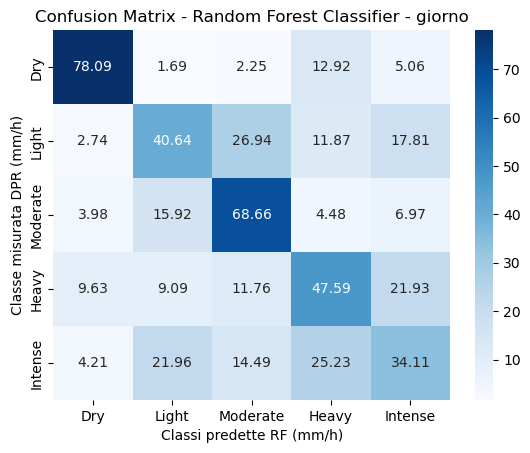

Shape di y_pred_proba: (999, 5)


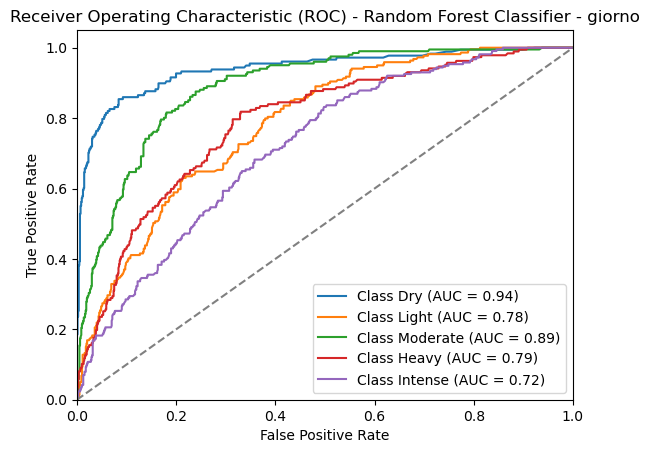

Weighted-average AUC: 0.8186631685657523
Importanza delle features:
1. Feature 94: 0.06092976601685476
2. Feature 88: 0.03676424216365107
3. Feature 62: 0.030577502978932074
4. Feature 56: 0.02907851635704616
5. Feature 58: 0.0290214288902708
6. Feature 64: 0.026794335752781246
7. Feature 60: 0.02599151039427363
8. Feature 86: 0.02529926150208807
9. Feature 90: 0.025170361180463226
10. Feature 97: 0.02160483284178
11. Feature 85: 0.020269182677787496
12. Feature 84: 0.019469790510167333
13. Feature 55: 0.01919200073812877
14. Feature 0: 0.01856232017870204
15. Feature 57: 0.018233226277482827
16. Feature 92: 0.017699458053169404
17. Feature 5: 0.017408158319759413
18. Feature 96: 0.016952317666795925
19. Feature 89: 0.016822879829347905
20. Feature 66: 0.01663715554623346
21. Feature 59: 0.016622351994431638
22. Feature 91: 0.0160563506260173
23. Feature 70: 0.016041343510439173
24. Feature 61: 0.015744931182616984
25. Feature 95: 0.015728152648847384
26. Feature 76: 0.0156655176243887

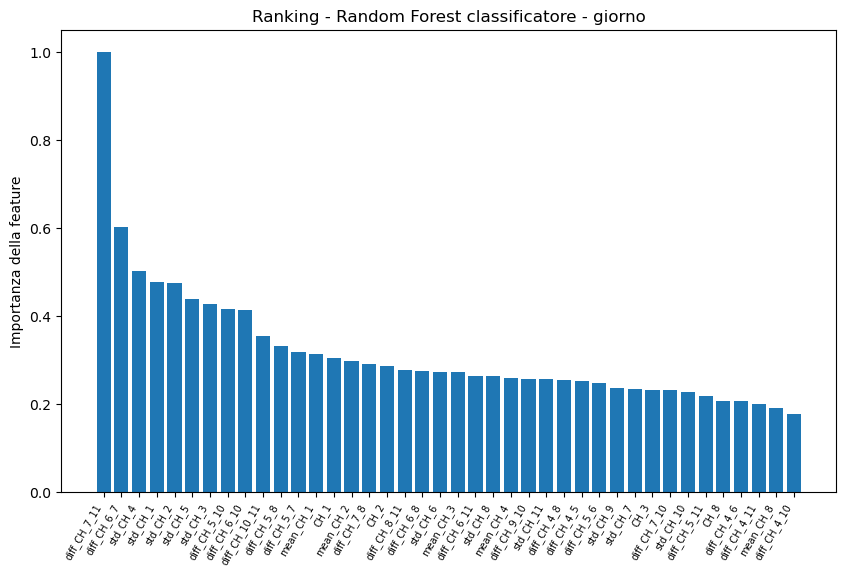

Lunghezza y_pred: 999
Pixel per immagine: 4096
Numero immagini calcolate: 0


In [162]:
############### MODELLO SOLO GIORNO 5 CLASSI ##################

import pickle
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_5classi/Bilanciamento_5classi'
output_directory_modelli_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_5classi/output_modelli'
output_directory_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_5classi/output'

# Creazione delle cartelle se non esistono
os.makedirs(output_directory_modelli_new, exist_ok=True)
os.makedirs(output_directory_new, exist_ok=True)


# Carica il file Dataframe pickle
with open(os.path.join(directory, 'df_features.pickle'), 'rb') as f:
    df_features = pickle.load(f)
# Carica il file DPR pickle
with open(os.path.join(directory, 'DPR_ml.pickle'), 'rb') as f:
    DPR = pickle.load(f)    
# Carica le maschere
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'rb') as f:
    GIORNO_maschera = pickle.load(f)  
#with open(os.path.join(directory, 'maschera_notte_ml.pickle'), 'rb') as f:
#    NOTTE_maschera = pickle.load(f)  

print(f"Lunghezza df_features: {len(df_features)}")
print(f"Lunghezza DPR: {len(DPR)}")

print(len(df_features))
print(len(GIORNO_maschera))

# Applicazione della maschera giorno
mask_indices = np.where(GIORNO_maschera == 1)[0]
df_features = df_features.iloc[mask_indices].reset_index(drop=True)
DPR = np.array(DPR)[mask_indices]

# Definizione delle classi e conversione in numeri
#classes = ['Dry', 'Light', 'Moderate', 'Heavy', 'Extreme']
#class_ranges = [0, 0.1, 1, 5, 30]  # Classi corrispondenti agli intervalli

max_value = np.max(DPR)
classes = [
    'Dry',
    'Light',
    'Moderate',
    'Heavy',
    'Intense',
]

class_ranges = [0, 0.1,1,5, 15, max_value ]

# Funzione per mappare i valori di DPR alle classi
def map_to_class(DPR_value):
    for i in range(len(class_ranges) - 1):
        if class_ranges[i] <= DPR_value < class_ranges[i + 1]:
            return classes[i]
    # Se il valore di DPR ри oltre l'ultimo intervallo, lo consideriamo come "Heavy"
    return classes[-1]

# Mappiamo i valori di DPR alle classi utilizzando la funzione definita
mapped_classes = [map_to_class(val) for val in DPR]

# Aggiungi la colonna della classe mappata al DataFrame
df_features['Precipitation_Class'] = mapped_classes

from sklearn.preprocessing import LabelEncoder

# Codifica le etichette di precipitazione (se sono stringhe) in numeri
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_features['Precipitation_Class'])

# ======= NUOVA DIVISIONE CASUALE ============
X = df_features.drop(columns=['Precipitation_Class'])
y = df_features['Precipitation_Class']

# Dividi i dati in training e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, shuffle=True
)

print(f"Distribuzione delle classi nel test set: {np.bincount(y_test)}")
print(f"Valori unici di y_test: {np.unique(y_test)}")

# ========== NORMALIZZAZIONE ================
# Calcolata solo sul training set!
x_min_vals = X_train.min()
x_max_vals = X_train.max()

X_train_norm = (X_train - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1
X_test_norm = (X_test - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1



rf_hyperparameters = {
    'random_state': 42,
    'n_jobs': 7,
    'n_estimators': 100,
    'max_depth': 50,
    'min_samples_leaf': 2,
    'max_features': 0.5,
    'max_samples': 0.5,
}


# # Parametri del modello Random Forest
# rf_hyperparameters = {
#     'random_state': 42,
#     'n_jobs': 7,
#     'n_estimators': 200,         # Aumentato per una migliore rappresentazione
#     'max_depth': 30,             # Diminuire leggermente per evitare overfitting
#     'min_samples_leaf': 2,       # Diminuire per consentire una migliore discriminazione tra classi
#     'max_features': 'sqrt',      # Utilizzo della radice quadrata del numero di feature per maggiore diversitр
#     'bootstrap': True,           # Bootstrap per un'analisi pi∙ robusta
#     'class_weight': 'balanced'   # Bilancia automaticamente il peso delle classi
# }


# Inizializza il modello Random Forest con i parametri specificati
rf_classifier = RandomForestClassifier(**rf_hyperparameters)

# Addestra il modello
rf_classifier.fit(X_train, y_train)

# ======= VALUTAZIONE SUL TRAINING SET =======
y_train_pred = rf_classifier.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print("\n=========== VALUTAZIONE SUL TRAINING SET ===========")
print(f'Accuracy (Train): {train_accuracy:.4f}')
print(f'Precision (Train): {train_precision:.4f}')
print(f'Recall (Train): {train_recall:.4f}')
print(f'F1-Score (Train): {train_f1:.4f}')


# ======= VALUTAZIONE SUL TEST SET =======
# Effettua le previsioni sui dati di test
y_pred = rf_classifier.predict(X_test)

# Valutazione del modello
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=classes)

# Calcolo delle metriche di valutazione aggiuntive
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)


for i, class_name in enumerate(classes):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    POD = TP / (TP + FN) if (TP + FN) > 0 else 0
    FAR = FP / (TP + FP) if (TP + FP) > 0 else 0
    BIAS = (TP + FP) / (TP + FN) if (TP + FN) > 0 else 0
    CSI = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    ETS = (TP - ((TP + FP) * (TP + FN) / conf_matrix.sum())) / \
          (TP + FP + FN - ((TP + FP) * (TP + FN) / conf_matrix.sum())) if (TP + FP + FN) > 0 else 0

    print(f"\nClass: {class_name}")
    print(f"POD: {POD:.3f}, FAR: {FAR:.3f}, BIAS: {BIAS:.3f}, CSI: {CSI:.3f}, ETS: {ETS:.3f}")

    
def hss_empirical(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()
    correct = np.trace(cm)  # somma della diagonale
    observed = cm.sum(axis=1)
    predicted = cm.sum(axis=0)

    expected = np.sum((observed * predicted) / total)

    hss = (correct - expected) / (total - expected) if (total - expected) != 0 else 0
    return hss

hss_value = hss_empirical(y_test, y_pred)



hss_1 = cohen_kappa_score(y_test, y_pred)


print("\n=========== VALUTAZIONE SUL TEST SET ===========")
print(f"HSS empirica: {hss_value:.3f}")
print(f"Heidke Skill Score (CK): {hss_1:.3f}")
print('Heidke Skill Score (HSS):', hss)
print(f'Accuracy (Test): {accuracy:.4f}')
print(f'Precision (Test): {precision:.4f}')
print(f'Recall (Test): {recall:.4f}')
print(f'F1-Score (Test): {f1:.4f}')
print('\nConfusion Matrix:')
print(conf_matrix)

print('Classification Report:')
print(report)


import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import normalize


num_pixel_per_image = 64 * 64
num_images = len(y_pred) // num_pixel_per_image

for i in range(num_images):
    image = y_pred[i * num_pixel_per_image : (i + 1) * num_pixel_per_image]
    image_2d = image.reshape((64, 64))
    plt.imshow(image_2d, cmap='tab10')  # o qualsiasi colormap per classi
    plt.title(f'Immagine {i}')
    plt.colorbar()
    plt.show()

# Plot 1
# Calcolo della matrice di confusione
conf_matrix = confusion_matrix(y_test, y_pred)
# Normalizzazione della matrice di confusione
conf_matrix_norm = normalize(conf_matrix, axis=1, norm='l1') * 100  # Normalizzazione in percentuale

# Visualizzazione della matrice di confusione utilizzando seaborn
# plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_norm, annot=True, fmt='.2f', cmap='Blues')
#sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
# Impostazione delle etichette degli assi
plt.xticks(ticks=np.arange(len(classes))+0.5, labels=classes, ha='center')
plt.yticks(ticks=np.arange(len(classes))+0.5, labels=classes, va='center')
plt.xlabel('Classi predette RF (mm/h)')
plt.ylabel('Classe misurata DPR (mm/h)')
plt.title('Confusion Matrix - Random Forest Classifier - giorno')
percorso_salvataggio = os.path.join(output_directory_new, 'confmatrix_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()



# Plot 2
from sklearn.preprocessing import LabelEncoder

# Inizializza l'encoder delle etichette
label_encoder = LabelEncoder()

# Codifica le classi di y_test in numeri
y_test_encoded = label_encoder.fit_transform(y_test)

# Calcolo delle probabilitра predette per tutte le classi
y_pred_prob = rf_classifier.predict_proba(X_test)

print(f"Shape di y_pred_proba: {y_pred_prob.shape}")

# Calcolo della curva ROC e dell'AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):  
    fpr[i], tpr[i], _ = roc_curve(y_test_encoded, y_pred_prob[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcolo dell'AUC pesata (weighted-average AUC)
weights = [len(y_test[y_test == i]) for i in range(len(classes))]  
weighted_auc = np.average(list(roc_auc.values()), weights=weights)

# Plot della curva ROC per ogni classe
# plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label='Class {} (AUC = {:.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Random Forest Classifier - giorno')
plt.legend(loc='lower right')
percorso_salvataggio = os.path.join(output_directory_new, 'roc_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

print("Weighted-average AUC:", weighted_auc)

# Plot 3 IMPORTANZA FEATURES

# Nomi delle features dal DataFrame df_features
feature_names = df_features.columns

# Ottieni l'importanza delle features dal modello
importances = rf_classifier.feature_importances_

# Normalizza l'importanza delle features
max_importance = max(importances)
norm_importances = importances / max_importance

# Ottieni gli indici delle features ordinate per importanza
indices = np.argsort(importances)[::-1]

# Stampa l'importanza delle prime 10 features
print("Importanza delle features:")
for f in range(40):
    print(f"{f + 1}. Feature {indices[f]}: {importances[indices[f]]}")

# Visualizza l'importanza delle features in un istogramma
plt.figure(figsize=(10, 6))
plt.title("Ranking - Random Forest classificatore - giorno")
plt.bar(range(40), norm_importances[indices][:40], align="center")
plt.xticks(range(40), [feature_names[i] for i in indices[:40]], rotation=60, ha='right', fontsize=7)
#plt.xlabel("Feature")
plt.ylabel("Importanza della feature")
percorso_salvataggio = os.path.join(output_directory_new, 'importanza_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

# Salvo il modello
metrics_class_str = f'Accuracy: {accuracy:.4f}\n' \
                   f'Precision: {precision:.4f}\n' \
                   f'Recall: {recall:.4f}\n' \
                   f'F1-Score: {f1:.4f}\n\n' \
                   f'Confusion Matrix:\n{conf_matrix}\n\n' \
                   f'POD (Probability of Detection): {POD}\n' \
                   f'FAR (False Alarm Rate): {FAR}\n' \
                   f'BIAS (Bias): {BIAS}\n' \
                   f'CSI (Critical Success Index): {CSI}\n' \
                   f'ETS (Equitable Threat Score): {ETS}\n\n' \
                   f'\nHeidke Skill Score (HSS): {hss}\n' \
                  # f'Classification Report:\n{report}\n'
# Aggiungi i primi 5 valori di importances
for i in range(10):
    metrics_class_str += f"{i+1}. Feature {indices[i]}: {importances[indices[i]]}\n"
    
with open(os.path.join(output_directory_new, "rf_class_giorno.txt"), 'w') as file:
    file.write(metrics_class_str)
joblib.dump(rf_classifier, os.path.join(output_directory_modelli_new, 'rf_giorno_classifier.pkl'))

print(f"Lunghezza y_pred: {len(y_pred)}")
print(f"Pixel per immagine: {num_pixel_per_image}")
print(f"Numero immagini calcolate: {num_images}")



In [18]:
######### MODELLO 5 CLASSI PROVA ########

import pickle
import pandas as pd
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import cohen_kappa_score

# Definizione delle cartelle
directory_features = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_5classi'
directory_features_bil5 = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_5classi/bilanciamento_5classi'
output_directory_modelli_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_5classi/output_modelli'
output_directory_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_5classi/output'

# Creazione delle cartelle se non esistono
os.makedirs(output_directory_modelli_new, exist_ok=True)
os.makedirs(output_directory_new, exist_ok=True)

# Caricamento dei dati originali e bilanciati
with open(os.path.join(directory_features, 'df_features.pickle'), 'rb') as f:
    df_features = pickle.load(f)

with open(os.path.join(directory_features, 'DPR_ml.pickle'), 'rb') as f:
    DPR = pickle.load(f)

with open(os.path.join(directory_features, 'maschera_giorno_ml.pickle'), 'rb') as f:
    GIORNO_maschera = pickle.load(f)


# Caricamento delle features bilanciate
with open(os.path.join(directory_features_bil5, 'df_features.pickle'), 'rb') as f:
    df_features_balanced = pickle.load(f)

with open(os.path.join(directory_features_bil5, 'DPR_ml.pickle'), 'rb') as f:
    DPR_balanced = pickle.load(f)

with open(os.path.join(directory_features_bil5, 'maschera_giorno_ml.pickle'), 'rb') as f:
    GIORNO_maschera_bil = pickle.load(f)

print(f"Lunghezza df_features: {len(df_features)}")
print(f"Lunghezza DPR: {len(DPR)}")


pixels_per_image = 64 * 64
num_images = len(GIORNO_maschera) // pixels_per_image
immagini_giorno = []

for i in range(num_images):
    start = i * pixels_per_image
    end = (i + 1) * pixels_per_image
    frazione_giorno = np.sum(GIORNO_maschera[start:end] == 1) / pixels_per_image
    immagini_giorno.append(1 if frazione_giorno >= 0.8 else 0)

immagini_valide = [i for i, val in enumerate(immagini_giorno) if val == 1]

#df_features = pd.concat([
#    df_features[i * pixels_per_image : (i + 1) * pixels_per_image]
#    for i in immagini_valide
#], ignore_index=True)

#DPR = [
#    DPR[i * pixels_per_image + j]
#    for i in immagini_valide
#    for j in range(pixels_per_image)
#]




#df_features_balanced = df_features_balanced[GIORNO_maschera_bil == 1].reset_index(drop=True)
#DPR_balanced = np.array(DPR_balanced)[GIORNO_maschera_bil == 1].tolist()


# Creazione delle classi e mappatura
max_value = np.max(DPR)
classes = ['Dry', 'Light', 'Moderate', 'Heavy', 'Intense']
class_ranges = [0, 0.1, 1, 5, 15, max_value]

# Funzione per mappare i valori di DPR alle classi
def map_to_class(DPR_value):
    for i in range(len(class_ranges) - 1):
        if class_ranges[i] <= DPR_value < class_ranges[i + 1]:
            return classes[i]
    return classes[-1]

# Mappiamo i valori di DPR alle classi
mapped_classes = [map_to_class(val) for val in DPR]

# Aggiunta della colonna 'Precipitation_Class' al DataFrame
df_features['Precipitation_Class'] = mapped_classes

# Mappiamo i valori di DPR alle classi per i dati bilanciati
mapped_classes_balanced = [map_to_class(val) for val in DPR_balanced]

# Aggiunta della colonna 'Precipitation_Class' ai dati bilanciati
df_features_balanced['Precipitation_Class'] = mapped_classes_balanced

# Codifica le etichette di precipitazione
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_features['Precipitation_Class'])
y_encoded_balanced = label_encoder.transform(df_features_balanced['Precipitation_Class'])

# Divisione dei dati in training e test (non bilanciato)
X_train_balanced = df_features_balanced.drop(columns=['Precipitation_Class'])
y_train_balanced = df_features_balanced['Precipitation_Class'].values

X_test = df_features.drop(columns=['Precipitation_Class'])
y_test = df_features['Precipitation_Class'].values

# Divisione dei dati bilanciati (solo training)
X_train_balanced = df_features_balanced.drop(columns=['Precipitation_Class'])
y_train_balanced = df_features_balanced['Precipitation_Class'].values

# Normalizzazione sui dati di training
x_min_vals = X_train_balanced.min()
x_max_vals = X_train_balanced.max()
X_train_norm = (X_train_balanced - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1
X_test_norm = (X_test - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1

# Inizializzazione del modello RandomForest
rf_hyperparameters = {
    'random_state': 42,
    'n_jobs': 7,
    'n_estimators': 100,
    'max_depth': 50,
    'min_samples_leaf': 2,
    'max_features': 0.5,
    'max_samples': 0.5,
}

rf_classifier = RandomForestClassifier(**rf_hyperparameters)

# Addestramento del modello sui dati bilanciati
rf_classifier.fit(X_train_norm, y_train_balanced)

# Previsioni sul training set
y_train_pred = rf_classifier.predict(X_train_norm)

# Valutazione sul training set
train_accuracy = accuracy_score(y_train_balanced, y_train_pred)
train_precision = precision_score(y_train_balanced, y_train_pred, average='weighted')
train_recall = recall_score(y_train_balanced, y_train_pred, average='weighted')
train_f1 = f1_score(y_train_balanced, y_train_pred, average='weighted')

print("\n=========== VALUTAZIONE SUL TRAINING SET ===========")
print(f'Accuracy (Train): {train_accuracy:.4f}')
print(f'Precision (Train): {train_precision:.4f}')
print(f'Recall (Train): {train_recall:.4f}')
print(f'F1-Score (Train): {train_f1:.4f}')

# Previsioni sul test set (non bilanciato)
y_pred = rf_classifier.predict(X_test_norm)

# ======= VALUTAZIONE SUL TEST SET =======
# Effettua le previsioni sui dati di test
# Valutazione del modello
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=classes)

# Calcolo delle metriche di valutazione aggiuntive
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)


for i, class_name in enumerate(classes):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    POD = TP / (TP + FN) if (TP + FN) > 0 else 0
    FAR = FP / (TP + FP) if (TP + FP) > 0 else 0
    BIAS = (TP + FP) / (TP + FN) if (TP + FN) > 0 else 0
    CSI = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    ETS = (TP - ((TP + FP) * (TP + FN) / conf_matrix.sum())) / \
          (TP + FP + FN - ((TP + FP) * (TP + FN) / conf_matrix.sum())) if (TP + FP + FN) > 0 else 0

    print(f"\nClass: {class_name}")
    print(f"POD: {POD:.3f}, FAR: {FAR:.3f}, BIAS: {BIAS:.3f}, CSI: {CSI:.3f}, ETS: {ETS:.3f}")

    
def hss_empirical(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()
    correct = np.trace(cm)  # somma della diagonale
    observed = cm.sum(axis=1)
    predicted = cm.sum(axis=0)

    expected = np.sum((observed * predicted) / total)

    hss = (correct - expected) / (total - expected) if (total - expected) != 0 else 0
    return hss

hss_value = hss_empirical(y_test, y_pred)



hss_1 = cohen_kappa_score(y_test, y_pred)


print("\n=========== VALUTAZIONE SUL TEST SET ===========")
print(f"HSS empirica: {hss_value:.3f}")
print(f"Heidke Skill Score (CK): {hss_1:.3f}")
print(f'Accuracy (Test): {accuracy:.4f}')
print(f'Precision (Test): {precision:.4f}')
print(f'Recall (Test): {recall:.4f}')
print(f'F1-Score (Test): {f1:.4f}')
print('\nConfusion Matrix:')
print(conf_matrix)

print('Classification Report:')
print(report)

with open(os.path.join(output_directory_new, 'y_pred_RF.pickle'), 'wb') as f:
    pickle.dump(y_pred, f)

Lunghezza df_features: 5898240
Lunghezza DPR: 5898240

=========== VALUTAZIONE SUL TRAINING SET ===========
Accuracy (Train): 0.9541
Precision (Train): 0.9546
Recall (Train): 0.9541
F1-Score (Train): 0.9541

Class: Dry
POD: 0.759, FAR: 0.008, BIAS: 0.766, CSI: 0.754, ETS: 0.152

Class: Light
POD: 0.503, FAR: 0.949, BIAS: 9.858, CSI: 0.049, ETS: 0.046

Class: Moderate
POD: 0.976, FAR: 0.981, BIAS: 50.614, CSI: 0.019, ETS: 0.019

Class: Heavy
POD: 0.495, FAR: 0.882, BIAS: 4.198, CSI: 0.105, ETS: 0.073

Class: Intense
POD: 0.324, FAR: 0.883, BIAS: 2.768, CSI: 0.094, ETS: 0.077

=========== VALUTAZIONE SUL TEST SET ===========
HSS empirica: 0.193
Heidke Skill Score (CK): 0.193
Accuracy (Test): 0.7377
Precision (Test): 0.9330
Recall (Test): 0.7377
F1-Score (Test): 0.8145

Confusion Matrix:
[[4179106  127272   95244  816733  286897]
 [    580    9650    4257    2025    2663]
 [     28      18    2608      17       2]
 [  26542   23098   16779  114799   50708]
 [   8645   28981   16403   4006

KeyboardInterrupt: 

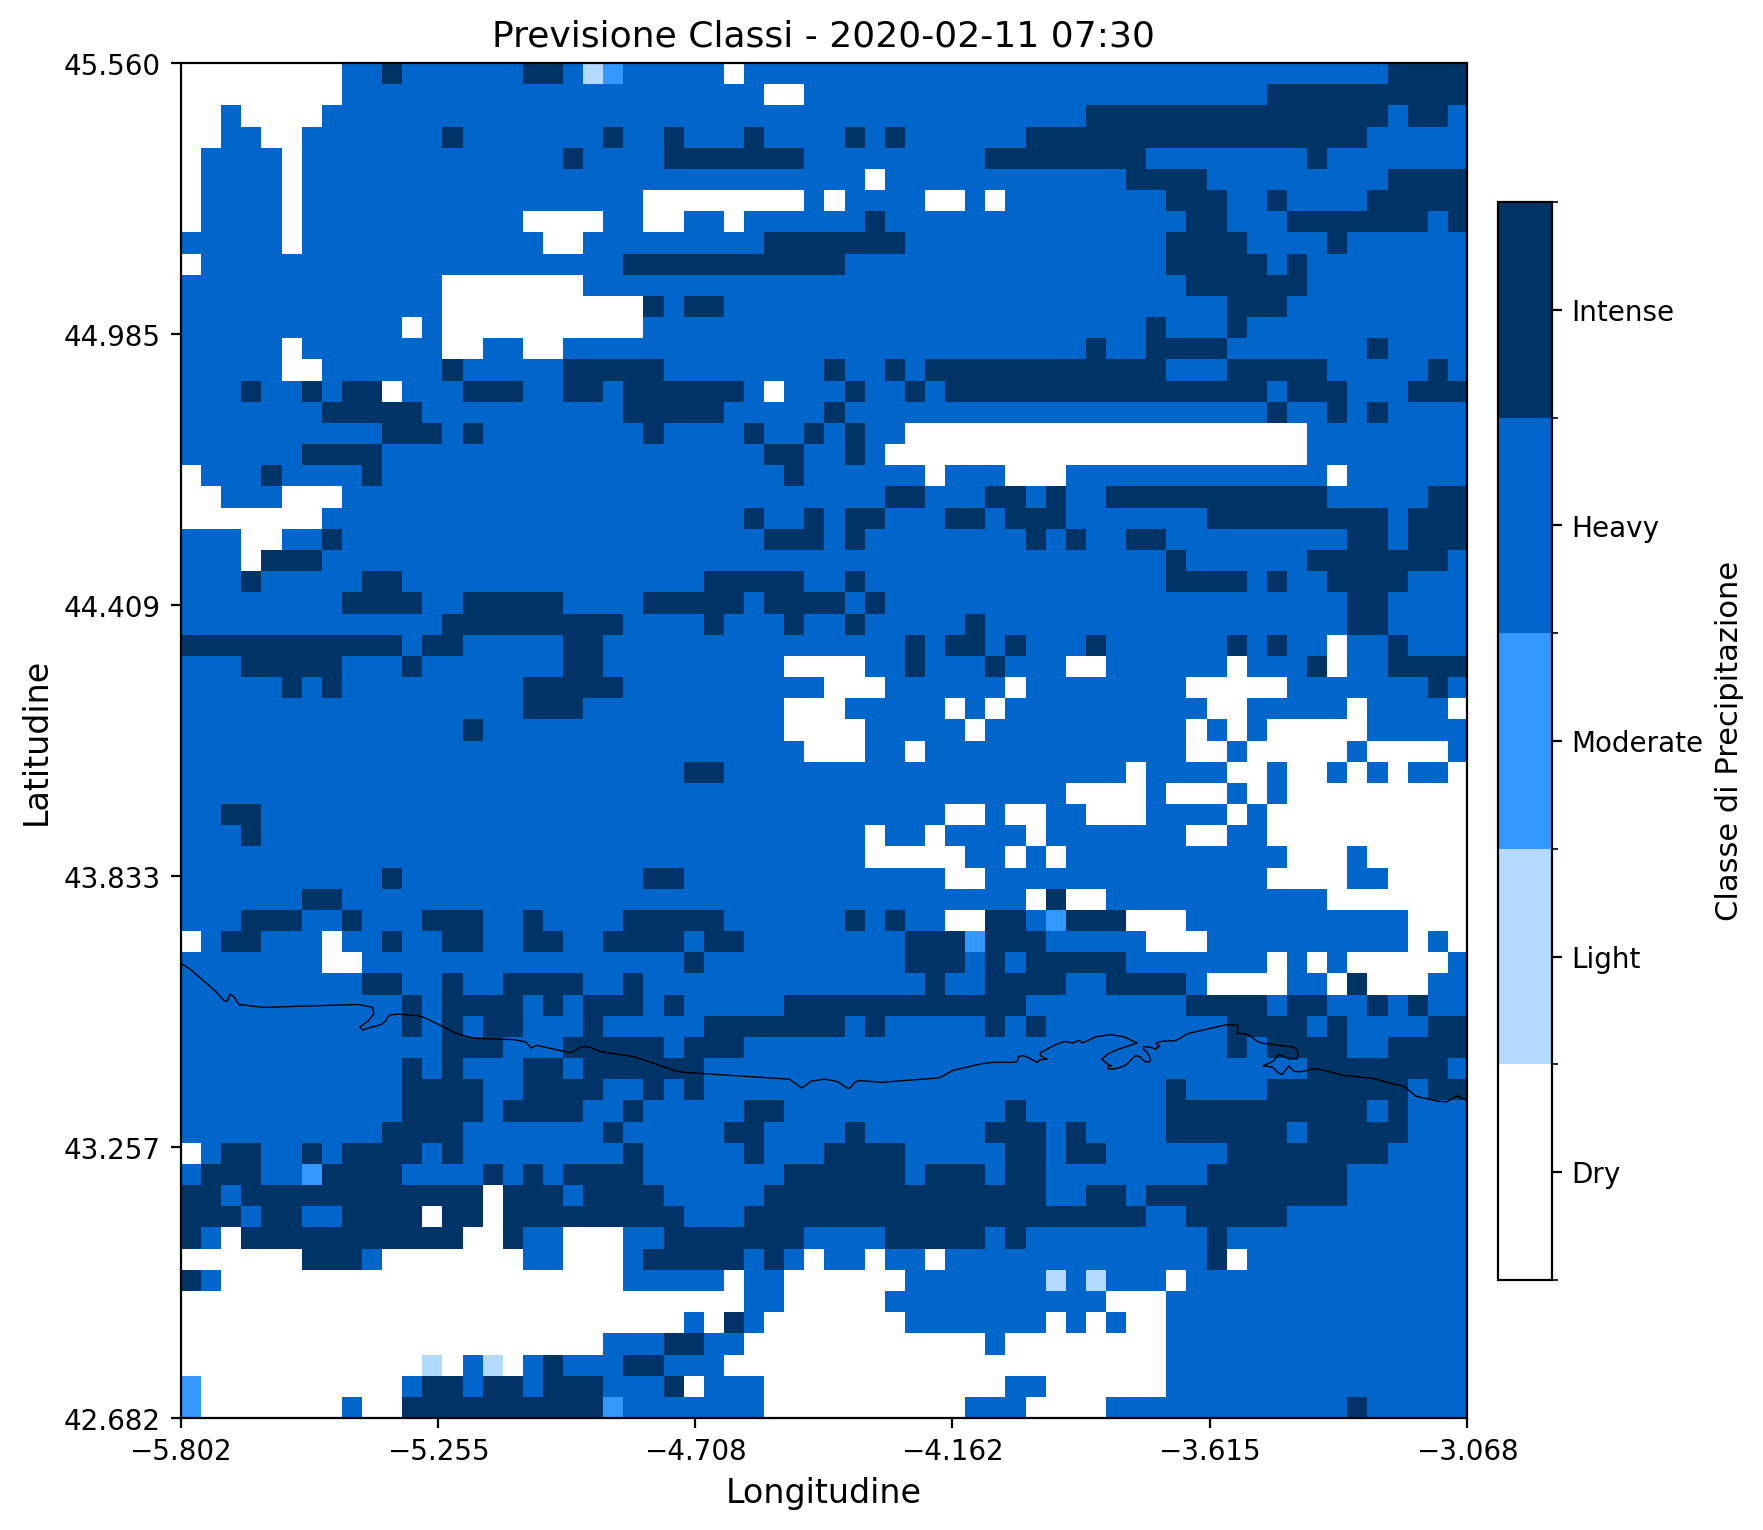

In [5]:
############## MAPPE CLASSI ##############

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
import pickle
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta

geo_dir = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_processati'

with open(os.path.join(geo_dir, 'LAT.pickle'), 'rb') as f:
    LAT = pickle.load(f)

with open(os.path.join(geo_dir, 'LONG.pickle'), 'rb') as f:
    LONG = pickle.load(f)

with open(os.path.join(geo_dir, 'DAY.pickle'), 'rb') as f:
    DAY = pickle.load(f)

with open(os.path.join(geo_dir, 'TIME.pickle'), 'rb') as f:
    TIME = pickle.load(f)

output_maps_dir = os.path.join(output_directory_new, "mappe_predizioni")
os.makedirs(output_maps_dir, exist_ok=True)

classes = ['Dry', 'Light', 'Moderate', 'Heavy', 'Intense']
class_colors = ['#ffffff', '#b3d9ff', '#3399ff', '#0066cc', '#003366']
cmap = mcolors.ListedColormap(class_colors)
bounds = np.arange(len(classes) + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

y_pred_labels = label_encoder.transform(y_pred)
n_images = len(y_pred_labels) // 4096

base_date = datetime(2020, 1, 1)

for i in range(n_images):
    start_idx = i * 4096
    end_idx = start_idx + 4096
    image = np.flipud(np.rot90(y_pred_labels[start_idx:end_idx].reshape((64, 64)), k=1))
    lat_img = np.flipud(np.rot90(LAT[start_idx:end_idx].reshape((64, 64)), k=1))
    lon_img = np.flipud(np.rot90(LONG[start_idx:end_idx].reshape((64, 64)), k=1))

    extent = [lon_img.min(), lon_img.max(), lat_img.min(), lat_img.max()]

    fig = plt.figure(figsize=(10, 10), dpi=200)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    im = ax.imshow(image, cmap=cmap, norm=norm, extent=extent,
                   origin='lower', interpolation='nearest', transform=ccrs.PlateCarree())

    ax.set_xlabel('Longitudine', fontsize=12)
    ax.set_ylabel('Latitudine', fontsize=12)
    ax.set_xticks(np.linspace(extent[0], extent[1], 6), crs=ccrs.PlateCarree())
    ax.set_yticks(np.linspace(extent[2], extent[3], 6), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=10)

    cbar = plt.colorbar(im, ax=ax, ticks=np.arange(len(classes)), orientation='vertical', shrink=0.7, pad=0.02)
    cbar.ax.set_yticklabels(classes, fontsize=10)
    cbar.set_label('Classe di Precipitazione', fontsize=11)

    # Calcola data e ora
    day_offset = int(DAY[i])
    time_slot = int(TIME[i])
    date = base_date + timedelta(days=day_offset)
    minutes = time_slot * 15
    hour = minutes // 60
    minute = minutes % 60
    time_str = f"{hour:02d}:{minute:02d}"
    date_str = date.strftime("%Y-%m-%d")

    ax.set_title(f'Previsione Classi - {date_str} {time_str}', fontsize=13)

    filename = f"pred_class_map_{i:03d}_{date_str}_T{hour:02d}{minute:02d}.png"
    plt.savefig(os.path.join(output_maps_dir, filename), bbox_inches='tight', pad_inches=0.1)
    plt.close()

KeyboardInterrupt: 

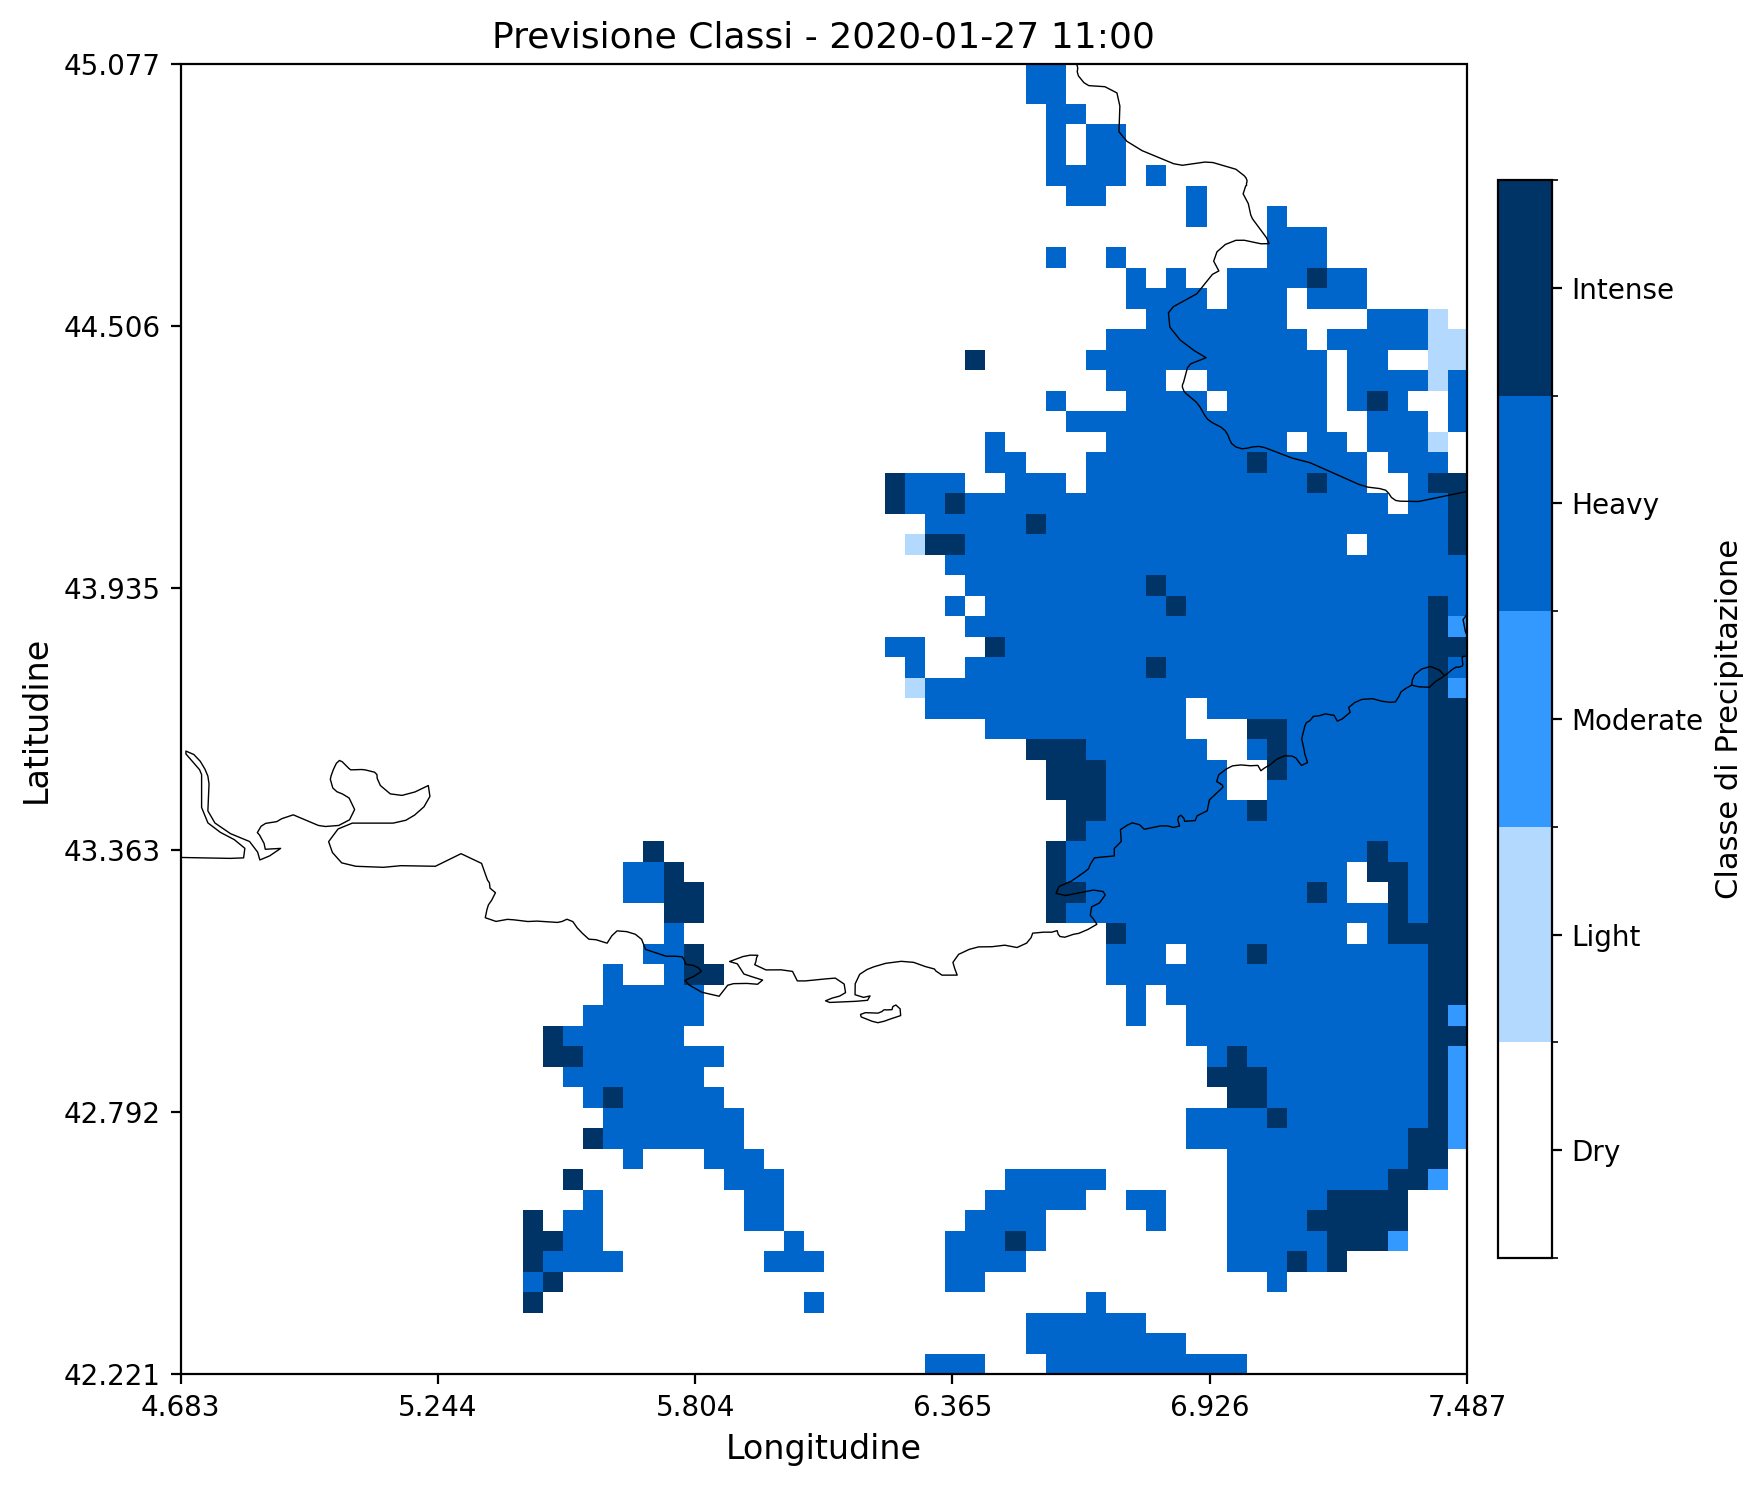

In [10]:
############## MAPPE CLASSI FILTRATE GIORNO ##############

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import os
import pickle
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta

geo_dir = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_processati'

# Caricamento array geografici e temporali
with open(os.path.join(geo_dir, 'LAT.pickle'), 'rb') as f:
    LAT = pickle.load(f)
with open(os.path.join(geo_dir, 'LONG.pickle'), 'rb') as f:
    LONG = pickle.load(f)
with open(os.path.join(geo_dir, 'DAY.pickle'), 'rb') as f:
    DAY = pickle.load(f)
with open(os.path.join(geo_dir, 'TIME.pickle'), 'rb') as f:
    TIME = pickle.load(f)

# Caricamento maschera giorno (1 = giorno, 0 = notte)
# Assumiamo che GIORNO_maschera sia già caricato come array binario (1 o 0) per ogni pixel
pixels_per_image = 64 * 64
num_images = len(GIORNO_maschera) // pixels_per_image

immagini_giorno = []
for i in range(num_images):
    start = i * pixels_per_image
    end = (i + 1) * pixels_per_image
    frazione_giorno = np.sum(GIORNO_maschera[start:end] == 1) / pixels_per_image
    immagini_giorno.append(1 if frazione_giorno >= 0.8 else 0)

immagini_valide = [i for i, val in enumerate(immagini_giorno) if val == 1]

# Parametri grafici
output_maps_dir = os.path.join(output_directory_new, "mappe_predizioni_giorno")
os.makedirs(output_maps_dir, exist_ok=True)

classes = ['Dry', 'Light', 'Moderate', 'Heavy', 'Intense']
class_colors = ['#ffffff', '#b3d9ff', '#3399ff', '#0066cc', '#003366']
cmap = mcolors.ListedColormap(class_colors)
bounds = np.arange(len(classes) + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap.N)

# Conversione label in classi
y_pred_labels = label_encoder.transform(y_pred)
base_date = datetime(2020, 1, 1)

# Ciclo solo sulle immagini di giorno
for i in immagini_valide:
    start_idx = i * pixels_per_image
    end_idx = start_idx + pixels_per_image

    image = y_pred_labels[start_idx:end_idx].reshape((64, 64))
    lat_img = LAT[start_idx:end_idx].reshape((64, 64))
    lon_img = LONG[start_idx:end_idx].reshape((64, 64))

    extent = [lon_img.min(), lon_img.max(), lat_img.min(), lat_img.max()]

    fig = plt.figure(figsize=(10, 10), dpi=200)
    ax = plt.axes(projection=ccrs.PlateCarree())
    ax.set_extent(extent, crs=ccrs.PlateCarree())

    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

    im = ax.imshow(image, cmap=cmap, norm=norm, extent=extent,
                   origin='lower', interpolation='nearest', transform=ccrs.PlateCarree())

    ax.set_xlabel('Longitudine', fontsize=12)
    ax.set_ylabel('Latitudine', fontsize=12)
    ax.set_xticks(np.linspace(extent[0], extent[1], 6), crs=ccrs.PlateCarree())
    ax.set_yticks(np.linspace(extent[2], extent[3], 6), crs=ccrs.PlateCarree())
    ax.tick_params(labelsize=10)

    cbar = plt.colorbar(im, ax=ax, ticks=np.arange(len(classes)), orientation='vertical', shrink=0.7, pad=0.02)
    cbar.ax.set_yticklabels(classes, fontsize=10)
    cbar.set_label('Classe di Precipitazione', fontsize=11)

    # Data e ora filtrati per immagine
    day_offset = int(DAY[i])
    time_slot = int(TIME[i])
    date = base_date + timedelta(days=day_offset)
    minutes = time_slot * 15
    hour = minutes // 60
    minute = minutes % 60
    time_str = f"{hour:02d}:{minute:02d}"
    date_str = date.strftime("%Y-%m-%d")

    ax.set_title(f'Previsione Classi - {date_str} {time_str}', fontsize=13)

    filename = f"pred_class_map_{i:03d}_{date_str}_T{hour:02d}{minute:02d}.png"
    plt.savefig(os.path.join(output_maps_dir, filename), bbox_inches='tight', pad_inches=0.1)
    plt.close()

In [148]:
############### MODELLO SOLO GIORNO 7 CLASSI ##################

import pickle
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_7classi'
output_directory_modelli_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_7classi/output_modelli'
output_directory_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_7classi/output'

# Creazione delle cartelle se non esistono
os.makedirs(output_directory_modelli_new, exist_ok=True)
os.makedirs(output_directory_new, exist_ok=True)


# Carica il file Dataframe pickle
with open(os.path.join(directory, 'df_features.pickle'), 'rb') as f:
    df_features = pickle.load(f)
# Carica il file DPR pickle
with open(os.path.join(directory, 'DPR_ml.pickle'), 'rb') as f:
    DPR = pickle.load(f)    
# Carica le maschere
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'rb') as f:
    GIORNO_maschera = pickle.load(f)  
with open(os.path.join(directory, 'maschera_notte_ml.pickle'), 'rb') as f:
    NOTTE_maschera = pickle.load(f)  

print(f"Lunghezza df_features: {len(df_features)}")
print(f"Lunghezza DPR: {len(DPR)}")

print(len(df_features))
print(len(GIORNO_maschera))

# Applicazione della maschera giorno
mask_indices = np.where(GIORNO_maschera == 1)[0]
df_features = df_features.iloc[mask_indices].reset_index(drop=True)
DPR = np.array(DPR)[mask_indices]

# Definizione delle classi e conversione in numeri
#classes = ['Dry', 'Light', 'Moderate', 'Heavy', 'Extreme']
#class_ranges = [0, 0.1, 1, 5, 30]  # Classi corrispondenti agli intervalli

max_value = np.max(DPR)
classes = [
    'Dry',
    'Very Light',
    'Light',
    'Moderate',
    'Intense',
    'Very Intense',
    'Heavy'
]

class_ranges = [0, 0.1, 1, 4, 7, 13, 19, max_value ]

# Funzione per mappare i valori di DPR alle classi
def map_to_class(DPR_value):
    for i in range(len(class_ranges) - 1):
        if class_ranges[i] <= DPR_value < class_ranges[i + 1]:
            return classes[i]
    # Se il valore di DPR ри oltre l'ultimo intervallo, lo consideriamo come "Heavy"
    return classes[-1]

# Mappiamo i valori di DPR alle classi utilizzando la funzione definita
mapped_classes = [map_to_class(val) for val in DPR]

# Aggiungi la colonna della classe mappata al DataFrame
df_features['Precipitation_Class'] = mapped_classes

from sklearn.preprocessing import LabelEncoder

# Codifica le etichette di precipitazione (se sono stringhe) in numeri
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_features['Precipitation_Class'])

# ======= NUOVA DIVISIONE CASUALE ============
X = df_features.drop(columns=['Precipitation_Class'])
y = df_features['Precipitation_Class']

# Dividi i dati in training e test
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, shuffle=True
)

print(f"Distribuzione delle classi nel test set: {np.bincount(y_test)}")
print(f"Valori unici di y_test: {np.unique(y_test)}")

# ========== NORMALIZZAZIONE ================
# Calcolata solo sul training set!
x_min_vals = X_train.min()
x_max_vals = X_train.max()

X_train_norm = (X_train - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1
X_test_norm = (X_test - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1


# Parametri del modello Random Forest
rf_hyperparameters = {
    'random_state': 42,
    'n_jobs': 7,
    'n_estimators': 100,
    'max_depth': 50,
    'min_samples_leaf': 3,
    'max_features': 0.5,
    'max_samples': 0.5
}


# # Parametri del modello Random Forest
# rf_hyperparameters = {
#     'random_state': 42,
#     'n_jobs': 7,
#     'n_estimators': 200,         # Aumentato per una migliore rappresentazione
#     'max_depth': 30,             # Diminuire leggermente per evitare overfitting
#     'min_samples_leaf': 2,       # Diminuire per consentire una migliore discriminazione tra classi
#     'max_features': 'sqrt',      # Utilizzo della radice quadrata del numero di feature per maggiore diversitр
#     'bootstrap': True,           # Bootstrap per un'analisi pi∙ robusta
#     'class_weight': 'balanced'   # Bilancia automaticamente il peso delle classi
# }


# Inizializza il modello Random Forest con i parametri specificati
rf_classifier = RandomForestClassifier(**rf_hyperparameters)

# Addestra il modello
rf_classifier.fit(X_train, y_train)

# ======= VALUTAZIONE SUL TRAINING SET =======
y_train_pred = rf_classifier.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print("\n=========== VALUTAZIONE SUL TRAINING SET ===========")
print(f'Accuracy (Train): {train_accuracy:.4f}')
print(f'Precision (Train): {train_precision:.4f}')
print(f'Recall (Train): {train_recall:.4f}')
print(f'F1-Score (Train): {train_f1:.4f}')


# ======= VALUTAZIONE SUL TEST SET =======
# Effettua le previsioni sui dati di test
y_pred = rf_classifier.predict(X_test)

# Valutazione del modello
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=classes)

# Calcolo delle metriche di valutazione aggiuntive
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

# Calcolo delle metriche aggiuntive
for i, class_name in enumerate(classes):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    POD = TP / (TP + FN) if (TP + FN) > 0 else 0
    FAR = FP / (TP + FP) if (TP + FP) > 0 else 0
    BIAS = (TP + FP) / (TP + FN) if (TP + FN) > 0 else 0
    CSI = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    ETS = (TP - ((TP + FP) * (TP + FN) / conf_matrix.sum())) / \
          (TP + FP + FN - ((TP + FP) * (TP + FN) / conf_matrix.sum())) if (TP + FP + FN) > 0 else 0

    print(f"\nClass: {class_name}")
    print(f"POD: {POD:.3f}, FAR: {FAR:.3f}, BIAS: {BIAS:.3f}, CSI: {CSI:.3f}, ETS: {ETS:.3f}")
    
    
def hss_empirical(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()
    correct = np.trace(cm)  # somma della diagonale
    observed = cm.sum(axis=1)
    predicted = cm.sum(axis=0)

    expected = np.sum((observed * predicted) / total)

    hss = (correct - expected) / (total - expected) if (total - expected) != 0 else 0
    return hss

hss_value = hss_empirical(y_test, y_pred)



hss_1 = cohen_kappa_score(y_test, y_pred)

print("\n=========== VALUTAZIONE SUL TEST SET ===========")
print(f"HSS empirica: {hss_value:.3f}")
print(f"Heidke Skill Score (CK): {hss_1:.3f}")
print('Heidke Skill Score (HSS):', hss)
print(f'Accuracy (Test): {accuracy:.4f}')
print(f'Precision (Test): {precision:.4f}')
print(f'Recall (Test): {recall:.4f}')
print(f'F1-Score (Test): {f1:.4f}')
print('\nConfusion Matrix:')
print(conf_matrix)


print('Classification Report:')
print(report)

import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import normalize


# Plot 1
# Calcolo della matrice di confusione
conf_matrix = confusion_matrix(y_test, y_pred)
# Normalizzazione della matrice di confusione
conf_matrix_norm = normalize(conf_matrix, axis=1, norm='l1') * 100  # Normalizzazione in percentuale

# Visualizzazione della matrice di confusione utilizzando seaborn
# plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix_norm, annot=True, fmt='.2f', cmap='Blues')
#sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
# Impostazione delle etichette degli assi
plt.xticks(ticks=np.arange(len(classes))+0.5, labels=classes, ha='center')
plt.yticks(ticks=np.arange(len(classes))+0.5, labels=classes, va='center')
plt.xlabel('Classi predette RF (mm/h)')
plt.ylabel('Classe misurata DPR (mm/h)')
plt.title('Confusion Matrix - Random Forest Classifier - giorno')
percorso_salvataggio = os.path.join(output_directory_new, 'confmatrix_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()



# Plot 2
from sklearn.preprocessing import LabelEncoder

# Inizializza l'encoder delle etichette
label_encoder = LabelEncoder()

# Codifica le classi di y_test in numeri
y_test_encoded = label_encoder.fit_transform(y_test)

# Calcolo delle probabilitра predette per tutte le classi
y_pred_prob = rf_classifier.predict_proba(X_test)

print(f"Shape di y_pred_proba: {y_pred_prob.shape}")

# Calcolo della curva ROC e dell'AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):  
    fpr[i], tpr[i], _ = roc_curve(y_test_encoded, y_pred_prob[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcolo dell'AUC pesata (weighted-average AUC)
weights = [len(y_test[y_test == i]) for i in range(len(classes))]  
weighted_auc = np.average(list(roc_auc.values()), weights=weights)

# Plot della curva ROC per ogni classe
# plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label='Class {} (AUC = {:.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Random Forest Classifier - giorno')
plt.legend(loc='lower right')
percorso_salvataggio = os.path.join(output_directory_new, 'roc_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

print("Weighted-average AUC:", weighted_auc)

# Plot 3 IMPORTANZA FEATURES

# Nomi delle features dal DataFrame df_features
feature_names = df_features.columns

# Ottieni l'importanza delle features dal modello
importances = rf_classifier.feature_importances_

# Normalizza l'importanza delle features
max_importance = max(importances)
norm_importances = importances / max_importance

# Ottieni gli indici delle features ordinate per importanza
indices = np.argsort(importances)[::-1]

# Stampa l'importanza delle prime 10 features
print("Importanza delle features:")
for f in range(40):
    print(f"{f + 1}. Feature {indices[f]}: {importances[indices[f]]}")

# Visualizza l'importanza delle features in un istogramma
plt.figure(figsize=(10, 6))
plt.title("Ranking - Random Forest classificatore - giorno")
plt.bar(range(40), norm_importances[indices][:40], align="center")
plt.xticks(range(40), [feature_names[i] for i in indices[:40]], rotation=60, ha='right', fontsize=7)
#plt.xlabel("Feature")
plt.ylabel("Importanza della feature")
percorso_salvataggio = os.path.join(output_directory_new, 'importanza_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

# Salvo il modello
metrics_class_str = f'Accuracy: {accuracy:.4f}\n' \
                   f'Precision: {precision:.4f}\n' \
                   f'Recall: {recall:.4f}\n' \
                   f'F1-Score: {f1:.4f}\n\n' \
                   f'Confusion Matrix:\n{conf_matrix}\n\n' \
                   f'POD (Probability of Detection): {POD}\n' \
                   f'FAR (False Alarm Rate): {FAR}\n' \
                   f'BIAS (Bias): {BIAS}\n' \
                   f'CSI (Critical Success Index): {CSI}\n' \
                   f'ETS (Equitable Threat Score): {ETS}\n\n' \
                   f'\nHeidke Skill Score (HSS): {hss}\n' \
                  # f'Classification Report:\n{report}\n'
# Aggiungi i primi 5 valori di importances
for i in range(10):
    metrics_class_str += f"{i+1}. Feature {indices[i]}: {importances[indices[i]]}\n"
    
with open(os.path.join(output_directory_new, "rf_class_giorno.txt"), 'w') as file:
    file.write(metrics_class_str)
joblib.dump(rf_classifier, os.path.join(output_directory_modelli_new, 'rf_giorno_classifier.pkl'))

Lunghezza df_features: 10577
Lunghezza DPR: 10577
10577
10577
Distribuzione delle classi nel test set: [ 87 134 129  97 135 117 109]
Valori unici di y_test: [0 1 2 3 4 5 6]


KeyboardInterrupt: 

In [ ]:
############### MODELLO SOLO GIORNO 15 CLASSI ##################

import pickle
import os
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix


directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_15classi'
output_directory_modelli_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_15classi/output_modelli'
output_directory_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus_15classi/output'

# Creazione delle cartelle se non esistono
os.makedirs(output_directory_modelli_new, exist_ok=True)
os.makedirs(output_directory_new, exist_ok=True)


# Carica il file Dataframe pickle
with open(os.path.join(directory, 'df_features.pickle'), 'rb') as f:
    df_features = pickle.load(f)
# Carica il file DPR pickle
with open(os.path.join(directory, 'DPR_ml.pickle'), 'rb') as f:
    DPR = pickle.load(f)    
# Carica le maschere
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'rb') as f:
    GIORNO_maschera = pickle.load(f)  
with open(os.path.join(directory, 'maschera_notte_ml.pickle'), 'rb') as f:
    NOTTE_maschera = pickle.load(f)  

print(f"Lunghezza df_features: {len(df_features)}")
print(f"Lunghezza DPR: {len(DPR)}")

print(len(df_features))
print(len(GIORNO_maschera))

# Applicazione della maschera giorno
#mask_indices = np.where(GIORNO_maschera == 1)[0]
#df_features = df_features.iloc[mask_indices].reset_index(drop=True)
#DPR = np.array(DPR)[mask_indices]

# Definizione delle classi e conversione in numeri
#classes = ['Dry', 'Light', 'Moderate', 'Heavy', 'Extreme']
#class_ranges = [0, 0.1, 1, 5, 30]  # Classi corrispondenti agli intervalli

# Calcola valore massimo
max_value = np.max(DPR)

# Definizione compatta classi e soglie
classes = [
    'Dry', 'Very Light', 'Light', 'Light-Moderate', 'Moderate',
    'Moderate-Heavy', 'Heavy', 'Very Heavy', 'Extreme I', 'Extreme II', 'Severe', 'Violent', 'Catastrophic'
]

class_ranges = [0, 0.1, 1, 2, 3, 4, 5, 6, 7, 9, 11, 14,20, max_value]

# Funzione per mappare i valori di DPR alle classi
def map_to_class(DPR_value):
    for i in range(len(class_ranges) - 1):
        if class_ranges[i] <= DPR_value < class_ranges[i + 1]:
            return classes[i]
    # Se il valore di DPR ри oltre l'ultimo intervallo, lo consideriamo come "Heavy"
    return classes[-1]

# Mappiamo i valori di DPR alle classi utilizzando la funzione definita
mapped_classes = [map_to_class(val) for val in DPR]

# Aggiungi la colonna della classe mappata al DataFrame
df_features['Precipitation_Class'] = mapped_classes

from sklearn.preprocessing import LabelEncoder

# Codifica le etichette di precipitazione (se sono stringhe) in numeri
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(df_features['Precipitation_Class'])

# ======= NUOVA DIVISIONE CASUALE ============
X = df_features.drop(columns=['Precipitation_Class'])
y = df_features['Precipitation_Class']

# Dividi i dati in training e test
X_train, X_test, y_train, y_test = train_test_split(X, y_encoded, test_size=0.2, shuffle=True)

print(f"Distribuzione delle classi nel test set: {np.bincount(y_test)}")
print(f"Valori unici di y_test: {np.unique(y_test)}")

# ========== NORMALIZZAZIONE ================
# Calcolata solo sul training set!
x_min_vals = X_train.min()
x_max_vals = X_train.max()

X_train_norm = (X_train - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1
X_test_norm = (X_test - x_min_vals) / (x_max_vals - x_min_vals) * 2 - 1


# Parametri del modello Random Forest
rf_hyperparameters = {
    'random_state': 42,
    'n_jobs': 7,
    'n_estimators': 100,
    'max_depth': 50,
    'min_samples_leaf': 3,
    'max_features': 0.5,
    'max_samples': 0.7
}


# # Parametri del modello Random Forest
# rf_hyperparameters = {
#     'random_state': 42,
#     'n_jobs': 7,
#     'n_estimators': 200,         # Aumentato per una migliore rappresentazione
#     'max_depth': 30,             # Diminuire leggermente per evitare overfitting
#     'min_samples_leaf': 2,       # Diminuire per consentire una migliore discriminazione tra classi
#     'max_features': 'sqrt',      # Utilizzo della radice quadrata del numero di feature per maggiore diversitр
#     'bootstrap': True,           # Bootstrap per un'analisi pi∙ robusta
#     'class_weight': 'balanced'   # Bilancia automaticamente il peso delle classi
# }


# Inizializza il modello Random Forest con i parametri specificati
rf_classifier = RandomForestClassifier(**rf_hyperparameters)

# Addestra il modello
rf_classifier.fit(X_train, y_train)

# ======= VALUTAZIONE SUL TRAINING SET =======
y_train_pred = rf_classifier.predict(X_train)

train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted')
train_recall = recall_score(y_train, y_train_pred, average='weighted')
train_f1 = f1_score(y_train, y_train_pred, average='weighted')

print("\n=========== VALUTAZIONE SUL TRAINING SET ===========")
print(f'Accuracy (Train): {train_accuracy:.4f}')
print(f'Precision (Train): {train_precision:.4f}')
print(f'Recall (Train): {train_recall:.4f}')
print(f'F1-Score (Train): {train_f1:.4f}')


# ======= VALUTAZIONE SUL TEST SET =======
# Effettua le previsioni sui dati di test
y_pred = rf_classifier.predict(X_test)

# Valutazione del modello
accuracy = accuracy_score(y_test, y_pred)
report = classification_report(y_test, y_pred, target_names=classes)

# Calcolo delle metriche di valutazione aggiuntive
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')
conf_matrix = confusion_matrix(y_test, y_pred)

for i, class_name in enumerate(classes):
    TP = conf_matrix[i, i]
    FP = conf_matrix[:, i].sum() - TP
    FN = conf_matrix[i, :].sum() - TP
    TN = conf_matrix.sum() - (TP + FP + FN)

    POD = TP / (TP + FN) if (TP + FN) > 0 else 0
    FAR = FP / (TP + FP) if (TP + FP) > 0 else 0
    BIAS = (TP + FP) / (TP + FN) if (TP + FN) > 0 else 0
    CSI = TP / (TP + FP + FN) if (TP + FP + FN) > 0 else 0
    ETS = (TP - ((TP + FP) * (TP + FN) / conf_matrix.sum())) / \
          (TP + FP + FN - ((TP + FP) * (TP + FN) / conf_matrix.sum())) if (TP + FP + FN) > 0 else 0

    print(f"\nClass: {class_name}")
    print(f"POD: {POD:.3f}, FAR: {FAR:.3f}, BIAS: {BIAS:.3f}, CSI: {CSI:.3f}, ETS: {ETS:.3f}")
    
def hss_empirical(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    total = cm.sum()
    correct = np.trace(cm)  # somma della diagonale
    observed = cm.sum(axis=1)
    predicted = cm.sum(axis=0)

    expected = np.sum((observed * predicted) / total)

    hss = (correct - expected) / (total - expected) if (total - expected) != 0 else 0
    return hss

hss_value = hss_empirical(y_test, y_pred)
print(f"HSS empirica: {hss_value:.3f}")

# Calcolo del coefficiente HSS
total_samples = len(y_test)
correct_samples = true_positive + true_negative
random_accuracy = ((true_positive + false_positive) * (true_positive + false_negative) +
                   (false_negative + true_negative) * (false_positive + true_negative)) / (total_samples ** 2)

hss = (correct_samples - random_accuracy) / (total_samples - random_accuracy)

hss_1 = cohen_kappa_score(y_test, y_pred)
print(f"Heidke Skill Score (HSS_1): {hss_1:.3f}")

print("\n=========== VALUTAZIONE SUL TEST SET ===========")
print(f"HSS empirica: {hss_value:.3f}")
print(f"Heidke Skill Score (CK): {hss_1:.3f}")
print('Heidke Skill Score (HSS):', hss)
print(f'Accuracy (Test): {accuracy:.4f}')
print(f'Precision (Test): {precision:.4f}')
print(f'Recall (Test): {recall:.4f}')
print(f'F1-Score (Test): {f1:.4f}')
print('\nConfusion Matrix:')
print(conf_matrix)
print('\nPOD (Probability of Detection):', POD)
print('FAR (False Alarm Rate):', FAR)
print('BIAS (Bias):', BIAS)
print('CSI (Critical Success Index):', CSI)
print('ETS (Equitable Threat Score):', ETS)

print('Classification Report:')
print(report)

import os
import joblib
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, auc
from sklearn.preprocessing import normalize






# Plot 1
# Calcolo della matrice di confusione
conf_matrix = confusion_matrix(y_test, y_pred)
# Normalizzazione della matrice di confusione
#conf_matrix_norm = normalize(conf_matrix, axis=1, norm='l1') * 100  # Normalizzazione in percentuale

plt.figure(figsize=(12, 10))  # Puoi provare anche valori maggiori tipo (12, 10)

# Visualizzazione della matrice di confusione utilizzando seaborn
# plt.figure(figsize=(8, 6))
sns.heatmap(conf_matrix, annot=True, fmt='.2f', cmap='Blues')  # Aggiungi norm se li vuoi normalizzati
#sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
# Impostazione delle etichette degli assi
plt.xticks(ticks=np.arange(len(classes))+0.5, labels=classes, ha='center')
plt.yticks(ticks=np.arange(len(classes))+0.5, labels=classes, va='center')
plt.xlabel('Classi predette RF (mm/h)')
plt.ylabel('Classe misurata DPR (mm/h)')
plt.title('Confusion Matrix - Random Forest Classifier - giorno')
percorso_salvataggio = os.path.join(output_directory_new, 'confmatrix_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

# ==================== RIMAPPATURA A 7 CLASSI ====================
from sklearn.metrics import accuracy_score, precision_score, confusion_matrix
from sklearn.metrics import cohen_kappa_score

def raggruppa_classi(vec):
    mapping = {
        0: 0,  # Dry
        1: 1,  # Very Light
        2: 2,  # Light
        3: 2,  # Light-Moderate
        4: 2,  # Moderate
        5: 3,  # Moderate-Heavy
        6: 3,  # Heavy
        7: 3,  # Very Heavy
        8: 4,  # Extreme I
        9: 4,  # Extreme II
        10: 4, # Severe
        11: 5, # Violent
        12: 6, # Catastrophic
    }
    return np.array([mapping[i] for i in vec])

# Applica la rimappatura
y_test_grouped = raggruppa_classi(y_test)
y_pred_grouped = raggruppa_classi(y_pred)

# Calcola nuova matrice di confusione
conf_matrix_grouped = confusion_matrix(y_test_grouped, y_pred_grouped)

# Calcola nuovo HSS per le 7 classi
acc = accuracy_score(y_test_grouped, y_pred_grouped)
print(f"Accuracy: {acc:.3f}")
prec = precision_score(y_test_grouped,y_pred_grouped, average='weighted')
print(f"Precisione (macro): {prec:.3f}")
hss_1 = cohen_kappa_score(y_test_grouped, y_pred_grouped)


hss_grouped = hss_empirical(y_test_grouped, y_pred_grouped)
print(f"HSS empirica: {hss_value:.3f}")
# Stampa risultati

print("\n=========== VALUTAZIONE RIMAPPATA A 7 CLASSI ===========")
print(f"HSS empirica: {hss_grouped:.3f}")
print(f"Heidke Skill Score (HSS_1): {hss:.3f}")
print("Confusion Matrix (7 classi):")
print(conf_matrix_grouped)

# Etichette nuove
class_labels_7 = [
    'Dry',
    'Light',
    'Moderate',
    'Extreme',
    'Severe',
    'Violent',
    'Catastrophic'
]

# Plot nuova confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_grouped, annot=True, fmt='d', cmap='Greens', xticklabels=class_labels_7, yticklabels=class_labels_7)
plt.xlabel('Classi Predette (7 gruppi)')
plt.ylabel('Classi Vere (7 gruppi)')
plt.title('Confusion Matrix (Raggruppata in 7 Classi) - RF Giorno')
plt.tight_layout()
plt.savefig(os.path.join(output_directory_new, 'confmatrix_rfclass_giorno_7classi.png'), dpi=300)
plt.show()

# ==================== RIMAPPATURA DA 7  A 5 CLASSI ====================

def raggruppa_classi(vec):
    mapping = {
        0: 0,  # Dry
        1: 1,  # Very Light
        2: 2,  # Light
        3: 3,  # Light-Moderate
        4: 4,  # Moderate
        5: 5,  # Moderate-Heavy
        6: 5,  # Heavy
    }
    return np.array([mapping[i] for i in vec])

# Applica la rimappatura
y_test_f7t5 = raggruppa_classi(y_test_grouped)
y_pred_f7t5 = raggruppa_classi(y_pred_grouped)

# Calcola nuova matrice di confusione
conf_matrix_f7t5 = confusion_matrix(y_test_f7t5, y_pred_f7t5 )

# Calcola nuovo HSS per le 7 classi
hss_1 = cohen_kappa_score(y_test_f7t5, y_test_f7t5)


hss_f7t5 = hss_empirical(y_test_f7t5, y_pred_f7t5)


# Stampa risultati
print("\n=========== VALUTAZIONE RIMAPPATA A 7 CLASSI ===========")
print(f"HSS empirica: {hss_f7t5:.3f}")
print(f"Heidke Skill Score (CK): {hss:.3f}")
print("Confusion Matrix (7 classi):")
print(conf_matrix_f7t5)

# Etichette nuove
class_labels_7 = [
    'Dry',
    'Light',
    'Moderate',
    'Severe',
    'Extreme',
    'Catastrophic'
]

# Plot nuova confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_f7t5, annot=True, fmt='d', cmap='Greens', xticklabels=class_labels_7, yticklabels=class_labels_7)
plt.xlabel('Classi Predette (7 gruppi)')
plt.ylabel('Classi Vere (7 gruppi)')
plt.title('Confusion Matrix (Raggruppata in 7 Classi) - RF Giorno')
plt.tight_layout()
plt.savefig(os.path.join(output_directory_new, 'confmatrix_rfclass_giorno_7classi.png'), dpi=300)
plt.show()


# ==================== RIMAPPATURA DA 15 A 5 CLASSI ====================

def raggruppa_classi(vec):
    mapping = {
        0: 0,  # Dry
        1: 1,  # Very Light
        2: 2,  # Light
        3: 2,  # Light-Moderate
        4: 2,  # Moderate
        5: 2,  # Moderate-Heavy
        6: 3,  # Heavy
        7: 3,  # Very Heavy
        8: 3,  # Extreme I
        9: 3,  # Extreme II
        10: 3, # Severe
        11: 4, # Violent
        12: 4, # Catastrophic
    }
    return np.array([mapping[i] for i in vec])

# Applica la rimappatura
y_test_f15t5 = raggruppa_classi(y_test)
y_pred_f15t5 = raggruppa_classi(y_pred)

# Calcola nuova matrice di confusione
conf_matrix_f15t5 = confusion_matrix(y_test_f15t5, y_pred_f15t5)

# Calcola nuovo HSS per le 7 classi

hss_1 = cohen_kappa_score(y_test_f15t5, y_test_f15t5)

hss_f15t5 = hss_empirical(y_test_f15t5, y_pred_f15t5)

# Stampa risultati
print("\n=========== VALUTAZIONE RIMAPPATA A 7 CLASSI ===========")
print(f"HSS empirica: {hss_f15t5:.3f}")
print(f"Heidke Skill Score (CK): {hss:.3f}")
print("Confusion Matrix (7 classi):")
print(conf_matrix_f15t5)

# Etichette nuove
class_labels_7 = [
    'Dry',
    'Light',
    'Moderate',
    'Severe',
    'Catastrophic'
]

# Plot nuova confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(conf_matrix_f15t5, annot=True, fmt='d', cmap='Blues', xticklabels=class_labels_7, yticklabels=class_labels_7)
plt.xlabel('Classi Predette (7 gruppi)')
plt.ylabel('Classi Vere (7 gruppi)')
plt.title('Confusion Matrix (Raggruppata in 7 Classi) - RF Giorno')
plt.tight_layout()
plt.savefig(os.path.join(output_directory_new, 'confmatrix_rfclass_giorno_7classi.png'), dpi=300)
plt.show()



######################### PLOT 2 ###########################
# Plot 2
from sklearn.preprocessing import LabelEncoder

# Inizializza l'encoder delle etichette
label_encoder = LabelEncoder()

# Codifica le classi di y_test in numeri
y_test_encoded = label_encoder.fit_transform(y_test)

# Calcolo delle probabilitра predette per tutte le classi
y_pred_prob = rf_classifier.predict_proba(X_test)

print(f"Shape di y_pred_proba: {y_pred_prob.shape}")

# Calcolo della curva ROC e dell'AUC per ogni classe
fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(len(classes)):  
    fpr[i], tpr[i], _ = roc_curve(y_test_encoded, y_pred_prob[:, i], pos_label=i)
    roc_auc[i] = auc(fpr[i], tpr[i])

# Calcolo dell'AUC pesata (weighted-average AUC)
weights = [len(y_test[y_test == i]) for i in range(len(classes))]  
weighted_auc = np.average(list(roc_auc.values()), weights=weights)

# Plot della curva ROC per ogni classe
# plt.figure(figsize=(8, 6))
for i in range(len(classes)):
    plt.plot(fpr[i], tpr[i], label='Class {} (AUC = {:.2f})'.format(classes[i], roc_auc[i]))

plt.plot([0, 1], [0, 1], color='grey', linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) - Random Forest Classifier - giorno')
plt.legend(loc='lower right')
percorso_salvataggio = os.path.join(output_directory_new, 'roc_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

print("Weighted-average AUC:", weighted_auc)

# Plot 3 IMPORTANZA FEATURES

# Nomi delle features dal DataFrame df_features
feature_names = df_features.columns

# Ottieni l'importanza delle features dal modello
importances = rf_classifier.feature_importances_

# Normalizza l'importanza delle features
max_importance = max(importances)
norm_importances = importances / max_importance

# Ottieni gli indici delle features ordinate per importanza
indices = np.argsort(importances)[::-1]

# Stampa l'importanza delle prime 10 features
print("Importanza delle features:")
for f in range(40):
    print(f"{f + 1}. Feature {indices[f]}: {importances[indices[f]]}")

# Visualizza l'importanza delle features in un istogramma
plt.figure(figsize=(10, 6))
plt.title("Ranking - Random Forest classificatore - giorno")
plt.bar(range(40), norm_importances[indices][:40], align="center")
plt.xticks(range(40), [feature_names[i] for i in indices[:40]], rotation=60, ha='right', fontsize=7)
#plt.xlabel("Feature")
plt.ylabel("Importanza della feature")
percorso_salvataggio = os.path.join(output_directory_new, 'importanza_rfclass_giorno.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

# Salvo il modello
metrics_class_str = f'Accuracy: {accuracy:.4f}\n' \
                   f'Precision: {precision:.4f}\n' \
                   f'Recall: {recall:.4f}\n' \
                   f'F1-Score: {f1:.4f}\n\n' \
                   f'Confusion Matrix:\n{conf_matrix}\n\n' \
                   f'POD (Probability of Detection): {POD}\n' \
                   f'FAR (False Alarm Rate): {FAR}\n' \
                   f'BIAS (Bias): {BIAS}\n' \
                   f'CSI (Critical Success Index): {CSI}\n' \
                   f'ETS (Equitable Threat Score): {ETS}\n\n' \
                   f'\nHeidke Skill Score (HSS): {hss}\n' \
                  # f'Classification Report:\n{report}\n'
# Aggiungi i primi 5 valori di importances
for i in range(10):
    metrics_class_str += f"{i+1}. Feature {indices[i]}: {importances[indices[i]]}\n"
    
with open(os.path.join(output_directory_new, "rf_class_giorno.txt"), 'w') as file:
    file.write(metrics_class_str)
joblib.dump(rf_classifier, os.path.join(output_directory_modelli_new, 'rf_giorno_classifier.pkl'))

In [ ]:
################## GRADIENT BOOSTING regressione GIORNO ###############

import pickle
import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import os
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.utils import resample
from xgboost import XGBRegressor


directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus'
output_directory_modelli_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus/output_modelli'
output_directory_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus/output'


# Carica il file Dataframe pickle
with open(os.path.join(directory, 'df_features.pickle'), 'rb') as f:
    df_features = pickle.load(f)
# Carica il file DPR pickle
with open(os.path.join(directory, 'DPR_ml.pickle'), 'rb') as f:
    DPR = pickle.load(f)    
# Carica le maschere 
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'rb') as f:
    GIORNO_maschera = pickle.load(f)  
    
mask_indices = np.where(GIORNO_maschera == 1)[0]
df_features = df_features.iloc[mask_indices].reset_index(drop=True)
DPR = np.array(DPR)[mask_indices]




############### LIGHT ############################

# Trova gli indici dove i valori di DPR sono compresi tra 0 (incluso) e 0.1
indici_dpr_range = np.where((DPR >= 0.1) & (DPR < 1))[0]
df_features = df_features.iloc[indici_dpr_range]
DPR = DPR[indici_dpr_range]



# Dividi i dati in set di addestramento e test

# 80%-20%
split_index = int(len(df_features) * 0.8)
X_train = df_features.iloc[:split_index]
X_test = df_features.iloc[split_index:]
y_train = DPR[:split_index]
y_test = DPR[split_index:]

# # Casuale
# X_train, X_test, y_train, y_test = train_test_split(df_features, DPR, test_size=0.2)




# xgb_hyperparameters = {
#     'random_state': 42,
#     'n_jobs': 7, 
#     'n_estimators': 100, #100 is already default
#     'max_depth': 50, #between None and 50 not much difference
#     'min_samples_leaf': 3,
#     #'min_samples_split': 5,
#     'max_features': 0.5, #to enhance bagging
#     'max_samples': 0.5 #to enhance bootstrap
# }

# Parametri del modello XGBoost
xgb_hyperparameters = {
    'random_state': 42,
    'n_jobs': 7, 
    'n_estimators': 100,
    'max_depth': 3,  # Ridotto per favorire linearitр
    'learning_rate': 0.05,  # Ridotto per addestramento pi∙ graduale
    'subsample': 0.5,  # Ridotto per limitare complessitр
    'colsample_bytree': 0.5,  # Ridotto per limitare complessitр
    'reg_alpha': 1,  # Aumentato per penalizzare i coefficienti
    'reg_lambda': 1,  # Aumentato per penalizzare i coefficienti
    'objective': 'reg:linear',  # Specifica la funzione di perdita come reg:linear per MAE
    'eval_metric': 'mae'  # Specifica la metrica di valutazione come MAE
}


# Inizializza il modello Random Forest
xgb_model = XGBRegressor(**xgb_hyperparameters)

# Addestra il modello
xgb_model.fit(X_train, y_train)

# Effettua predizioni sul set di test
predictions = xgb_model.predict(X_test)


# Calcola le metriche richieste
giorno_xgb_mse = mean_squared_error(y_test, predictions)
giorno_xgb_mae = mean_absolute_error(y_test, predictions)
giorno_xgb_r2 = r2_score(y_test, predictions)
giorno_xgb_cc = np.corrcoef(y_test, predictions)[0, 1]  # Coefficiente di correlazione
giorno_xgb_cv = np.std(predictions) / np.mean(predictions)  # Coefficiente di variazione
giorno_xgb_me = np.mean(predictions - y_test)  # Errore medio normalizzato
giorno_xgb_mae_norm = mean_absolute_error(y_test, predictions) / np.mean(y_test)  # MAE normalizzato

# Stampa le metriche
print("Gradient Boosting - MSE:", giorno_xgb_mse)
print("Gradient Boosting - MAE:", giorno_xgb_mae)
print("Gradient Boosting - R²:", giorno_xgb_r2)
print("Gradient Boosting - CC:", giorno_xgb_cc)
print("Gradient Boosting - CV:", giorno_xgb_cv)
print("Gradient Boosting - ME:", giorno_xgb_me)
print("Gradient Boosting - MAE Normalizzato:", giorno_xgb_mae_norm)

joblib.dump(xgb_model, os.path.join(output_directory_modelli_new, 'xgb_giorno_light.pkl'))


import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import MinMaxScaler
from joblib import Parallel, delayed
import matplotlib.pyplot as plt


# Combina i dati in un'unica matrice (due colonne)
xy = np.vstack([y_test, predictions]).T


# Campionamento casuale di una porzione dei dati
sample_size = 1000
xy_sampled = resample(xy, n_samples=sample_size, replace=False, random_state=0)
# Calcola la densitра dei punti utilizzando KDE
kde = KernelDensity(bandwidth=1.0, kernel='gaussian')
kde.fit(xy_sampled)
n_jobs = 7 
def compute_density(start, end):
    return np.exp(kde.score_samples(xy[start:end]))
block_size = len(xy) // n_jobs
blocks = [(i * block_size, (i + 1) * block_size) for i in range(n_jobs)]
# Calcolo della densitра in parallelo utilizzando tutti i processori disponibili
densities = Parallel(n_jobs=n_jobs)(
    delayed(compute_density)(start, end) for start, end in blocks
)
# Calcola la densitра per gli elementi rimanenti nel blocco finale
if len(xy) % n_jobs != 0:
    remaining_density = compute_density(n_jobs * block_size, len(xy))
    densities.append(remaining_density)
# Concatena tutte le densitра calcolate
density_parallel = np.concatenate(densities)
# Normalizzazione della densitра tra 0 e 1
scaler = MinMaxScaler()
densita_norm = scaler.fit_transform(density_parallel.reshape(-1, 1)).flatten()
# Calcola la densitра logaritmica
# densita_log = np.log(density_parallel)


# Visualizzazione grafica delle predizioni vs valori effettivi per Gradient Boosting
# Plot 1
# plt.figure(figsize=(10, 8))
plt.scatter(y_test, predictions, c=densita_norm, cmap='viridis', marker='o', s=2)
# plt.scatter(y_test, predictions, c=densita_log, cmap='viridis', marker='o', s=2)
plt.xlabel("Valori DPR (mm/h)")
plt.ylabel("Valore stimato (mm/h)")
plt.title("Gradient Boosting - giorno")
plt.colorbar(label='Densitра')
plt.xscale('log')
plt.yscale('log')
percorso_salvataggio = os.path.join(output_directory_new, 'scatter_xgb_giorno_log_light.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

# Plot 2
# plt.figure(figsize=(10, 8))
# plt.xlim(0,30)
# plt.ylim(0,30)
plt.scatter(y_test, predictions, c=densita_norm, cmap='viridis', marker='o', s=2)
# plt.scatter(y_test, predictions, c=densita_log, cmap='viridis', marker='o', s=2)
plt.xlabel("Valori DPR (mm/h)")
plt.ylabel("Valore stimato (mm/h)")
plt.title("Gradient Boosting - giorno")
plt.colorbar(label='Densitра')
# Aggiungi la linea rossa lungo la diagonale
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.grid(True)
# plt.xscale('log')
# plt.yscale('log')
percorso_salvataggio = os.path.join(output_directory_new, 'scatter_xgb_giorno_light.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()


# Plot 2 ZOOM
# plt.figure(figsize=(10, 8))
plt.xlim(0,30)
plt.ylim(0,30)
plt.scatter(y_test, predictions, c=densita_norm, cmap='viridis', marker='o', s=2)
# plt.scatter(y_test, predictions, c=densita_log, cmap='viridis', marker='o', s=2)
plt.xlabel("Valori DPR (mm/h)")
plt.ylabel("Valore stimato (mm/h)")
plt.title("Gradient Boosting - giorno")
plt.colorbar(label='Densitра')
# Aggiungi la linea rossa lungo la diagonale
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.grid(True)
# plt.xscale('log')
# plt.yscale('log')
percorso_salvataggio = os.path.join(output_directory_new, 'scatter_xgb_giorno_zoom_light.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()


# Plot 3 IMPORTANZA FEATURES

# Nomi delle features dal DataFrame df_features
feature_names = df_features.columns

# Ottieni l'importanza delle features dal modello
importances = xgb_model.feature_importances_

# Normalizza l'importanza delle features
max_importance = max(importances)
norm_importances = importances / max_importance

# Ottieni gli indici delle features ordinate per importanza
indices = np.argsort(importances)[::-1]

# Stampa l'importanza delle prime 10 features
print("Importanza delle features:")
for f in range(40):
    print(f"{f + 1}. Feature {indices[f]}: {importances[indices[f]]}")

# Visualizza l'importanza delle features in un istogramma
plt.figure(figsize=(10, 6))
plt.title("Ranking - Gradient Boosting regressione - giorno")
plt.bar(range(40), norm_importances[indices][:40], align="center")
plt.xticks(range(40), [feature_names[i] for i in indices[:40]], rotation=60, ha='right', fontsize=7)
#plt.xlabel("Feature")
plt.ylabel("Importanza della feature")
percorso_salvataggio = os.path.join(output_directory_new, 'importanza_xgb_giorno_light.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()


# Salvo il modello e i valori
metrics_str = f"Gradient Boosting - MSE: {giorno_xgb_mse}\n" \
              f"Gradient Boosting - MAE: {giorno_xgb_mae}\n" \
              f"Gradient Boosting - R²: {giorno_xgb_r2}\n" \
              f"Gradient Boosting - CC: {giorno_xgb_cc}\n" \
              f"Gradient Boosting - CV: {giorno_xgb_cv}\n" \
              f"Gradient Boosting - ME: {giorno_xgb_me}\n" \
              f"Gradient Boosting - MAE Normalizzato: {giorno_xgb_mae_norm}\n"
# Aggiungi i primi 5 valori di importances
for i in range(10):
    metrics_str += f"{i+1}. Feature {indices[i]}: {importances[indices[i]]}\n"

with open(os.path.join(output_directory_new, "xgb_giorno_light.txt"), 'w') as file:
    file.write(metrics_str)






############### MODERATE ############################


import pickle
import os
import numpy as np

directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus'
output_directory_modelli_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus/output_modelli'
output_directory_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus/output'


# Carica il file Dataframe pickle
with open(os.path.join(directory, 'df_features.pickle'), 'rb') as f:
    df_features = pickle.load(f)
# Carica il file DPR pickle
with open(os.path.join(directory, 'DPR_ml.pickle'), 'rb') as f:
    DPR = pickle.load(f)    
# Carica le maschere 
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'rb') as f:
    GIORNO_maschera = pickle.load(f)  
    
    
mask_indices = np.where(GIORNO_maschera == 1)[0]
df_features = df_features.iloc[mask_indices].reset_index(drop=True)
DPR = np.array(DPR)[mask_indices]





# Trova gli indici dove i valori di DPR sono compresi tra 0 (incluso) e 0.1
indici_dpr_range = np.where((DPR >= 1) & (DPR < 5))[0]
df_features = df_features.iloc[indici_dpr_range]
DPR = DPR[indici_dpr_range]



# Dividi i dati in set di addestramento e test

# 80%-20%
split_index = int(len(df_features) * 0.8)
X_train = df_features.iloc[:split_index]
X_test = df_features.iloc[split_index:]
y_train = DPR[:split_index]
y_test = DPR[split_index:]

# # Casuale
# X_train, X_test, y_train, y_test = train_test_split(df_features, DPR, test_size=0.2)




# xgb_hyperparameters = {
#     'random_state': 42,
#     'n_jobs': 7, 
#     'n_estimators': 100, #100 is already default
#     'max_depth': 50, #between None and 50 not much difference
#     'min_samples_leaf': 3,
#     #'min_samples_split': 5,
#     'max_features': 0.5, #to enhance bagging
#     'max_samples': 0.5 #to enhance bootstrap
# }

# Parametri del modello XGBoost
xgb_hyperparameters = {
    'random_state': 42,
    'n_jobs': 7, 
    'n_estimators': 100,
    'max_depth': 3,  # Ridotto per favorire linearitр
    'learning_rate': 0.05,  # Ridotto per addestramento pi∙ graduale
    'subsample': 0.5,  # Ridotto per limitare complessitр
    'colsample_bytree': 0.5,  # Ridotto per limitare complessitр
    'reg_alpha': 1,  # Aumentato per penalizzare i coefficienti
    'reg_lambda': 1,  # Aumentato per penalizzare i coefficienti
    'objective': 'reg:linear',  # Specifica la funzione di perdita come reg:linear per MAE
    'eval_metric': 'mae'  # Specifica la metrica di valutazione come MAE
}


# Inizializza il modello Gradient Boosting
xgb_model = XGBRegressor(**xgb_hyperparameters)

# Addestra il modello
xgb_model.fit(X_train, y_train)

# Effettua predizioni sul set di test
predictions = xgb_model.predict(X_test)


# Calcola le metriche richieste
giorno_xgb_mse = mean_squared_error(y_test, predictions)
giorno_xgb_mae = mean_absolute_error(y_test, predictions)
giorno_xgb_r2 = r2_score(y_test, predictions)
giorno_xgb_cc = np.corrcoef(y_test, predictions)[0, 1]  # Coefficiente di correlazione
giorno_xgb_cv = np.std(predictions) / np.mean(predictions)  # Coefficiente di variazione
giorno_xgb_me = np.mean(predictions - y_test)  # Errore medio normalizzato
giorno_xgb_mae_norm = mean_absolute_error(y_test, predictions) / np.mean(y_test)  # MAE normalizzato

# Stampa le metriche
print("Gradient Boosting - MSE:", giorno_xgb_mse)
print("Gradient Boosting - MAE:", giorno_xgb_mae)
print("Gradient Boosting - R²:", giorno_xgb_r2)
print("Gradient Boosting - CC:", giorno_xgb_cc)
print("Gradient Boosting - CV:", giorno_xgb_cv)
print("Gradient Boosting - ME:", giorno_xgb_me)
print("Gradient Boosting - MAE Normalizzato:", giorno_xgb_mae_norm)

joblib.dump(xgb_model, os.path.join(output_directory_modelli_new, 'xgb_giorno_moderate.pkl'))


import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import MinMaxScaler
from joblib import Parallel, delayed
import matplotlib.pyplot as plt


# Combina i dati in un'unica matrice (due colonne)
xy = np.vstack([y_test, predictions]).T


# Campionamento casuale di una porzione dei dati
sample_size = 1000
xy_sampled = resample(xy, n_samples=sample_size, replace=False, random_state=0)
# Calcola la densitра dei punti utilizzando KDE
kde = KernelDensity(bandwidth=1.0, kernel='gaussian')
kde.fit(xy_sampled)
n_jobs = 7 
def compute_density(start, end):
    return np.exp(kde.score_samples(xy[start:end]))
block_size = len(xy) // n_jobs
blocks = [(i * block_size, (i + 1) * block_size) for i in range(n_jobs)]
# Calcolo della densitра in parallelo utilizzando tutti i processori disponibili
densities = Parallel(n_jobs=n_jobs)(
    delayed(compute_density)(start, end) for start, end in blocks
)
# Calcola la densitра per gli elementi rimanenti nel blocco finale
if len(xy) % n_jobs != 0:
    remaining_density = compute_density(n_jobs * block_size, len(xy))
    densities.append(remaining_density)
# Concatena tutte le densitра calcolate
density_parallel = np.concatenate(densities)
# Normalizzazione della densitра tra 0 e 1
scaler = MinMaxScaler()
densita_norm = scaler.fit_transform(density_parallel.reshape(-1, 1)).flatten()
# Calcola la densitра logaritmica
# densita_log = np.log(density_parallel)


# Visualizzazione grafica delle predizioni vs valori effettivi per Gradient Boosting
# Plot 1
# plt.figure(figsize=(10, 8))
plt.scatter(y_test, predictions, c=densita_norm, cmap='viridis', marker='o', s=2)
# plt.scatter(y_test, predictions, c=densita_log, cmap='viridis', marker='o', s=2)
plt.xlabel("Valori DPR (mm/h)")
plt.ylabel("Valore stimato (mm/h)")
plt.title("Gradient Boosting - giorno")
plt.colorbar(label='Densitра')
plt.xscale('log')
plt.yscale('log')
percorso_salvataggio = os.path.join(output_directory_new, 'scatter_xgb_giorno_log_moderate.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

# Plot 2
# plt.figure(figsize=(10, 8))
# plt.xlim(0,30)
# plt.ylim(0,30)
plt.scatter(y_test, predictions, c=densita_norm, cmap='viridis', marker='o', s=2)
# plt.scatter(y_test, predictions, c=densita_log, cmap='viridis', marker='o', s=2)
plt.xlabel("Valori DPR (mm/h)")
plt.ylabel("Valore stimato (mm/h)")
plt.title("Gradient Boosting - giorno")
plt.colorbar(label='Densitра')
# Aggiungi la linea rossa lungo la diagonale
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.grid(True)
# plt.xscale('log')
# plt.yscale('log')
percorso_salvataggio = os.path.join(output_directory_new, 'scatter_xgb_giorno_moderate.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()


# Plot 2 ZOOM
# plt.figure(figsize=(10, 8))
plt.xlim(0,30)
plt.ylim(0,30)
plt.scatter(y_test, predictions, c=densita_norm, cmap='viridis', marker='o', s=2)
# plt.scatter(y_test, predictions, c=densita_log, cmap='viridis', marker='o', s=2)
plt.xlabel("Valori DPR (mm/h)")
plt.ylabel("Valore stimato (mm/h)")
plt.title("Gradient Boosting - giorno")
plt.colorbar(label='Densitра')
# Aggiungi la linea rossa lungo la diagonale
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.grid(True)
# plt.xscale('log')
# plt.yscale('log')
percorso_salvataggio = os.path.join(output_directory_new, 'scatter_xgb_giorno_zoom_moderate.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()


# Plot 3 IMPORTANZA FEATURES

# Nomi delle features dal DataFrame df_features
feature_names = df_features.columns

# Ottieni l'importanza delle features dal modello
importances = xgb_model.feature_importances_

# Normalizza l'importanza delle features
max_importance = max(importances)
norm_importances = importances / max_importance

# Ottieni gli indici delle features ordinate per importanza
indices = np.argsort(importances)[::-1]

# Stampa l'importanza delle prime 10 features
print("Importanza delle features:")
for f in range(40):
    print(f"{f + 1}. Feature {indices[f]}: {importances[indices[f]]}")

# Visualizza l'importanza delle features in un istogramma
plt.figure(figsize=(10, 6))
plt.title("Ranking - Gradient Boosting regressione - giorno")
plt.bar(range(40), norm_importances[indices][:40], align="center")
plt.xticks(range(40), [feature_names[i] for i in indices[:40]], rotation=60, ha='right', fontsize=7)
#plt.xlabel("Feature")
plt.ylabel("Importanza della feature")
percorso_salvataggio = os.path.join(output_directory_new, 'importanza_xgb_giorno_moderate.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()


# Salvo il modello e i valori
metrics_str = f"Gradient Boosting - MSE: {giorno_xgb_mse}\n" \
              f"Gradient Boosting - MAE: {giorno_xgb_mae}\n" \
              f"Gradient Boosting - R²: {giorno_xgb_r2}\n" \
              f"Gradient Boosting - CC: {giorno_xgb_cc}\n" \
              f"Gradient Boosting - CV: {giorno_xgb_cv}\n" \
              f"Gradient Boosting - ME: {giorno_xgb_me}\n" \
              f"Gradient Boosting - MAE Normalizzato: {giorno_xgb_mae_norm}\n"
# Aggiungi i primi 5 valori di importances
for i in range(10):
    metrics_str += f"{i+1}. Feature {indices[i]}: {importances[indices[i]]}\n"

with open(os.path.join(output_directory_new, "xgb_giorno_moderate.txt"), 'w') as file:
    file.write(metrics_str)




############### HEAVY ############################

import pickle
import os
import numpy as np

directory = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus'
output_directory_modelli_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus/output_modelli'
output_directory_new = 'C:/Users/user/Documents/TESI/datigrezzi/DATI_grezzi_2020/Dati_ML_plus/output'

# Carica il file Dataframe pickle
with open(os.path.join(directory, 'df_features.pickle'), 'rb') as f:
    df_features = pickle.load(f)
# Carica il file DPR pickle
with open(os.path.join(directory, 'DPR_ml.pickle'), 'rb') as f:
    DPR = pickle.load(f)    
# Carica le maschere 
with open(os.path.join(directory, 'maschera_giorno_ml.pickle'), 'rb') as f:
    GIORNO_maschera = pickle.load(f)  
    
mask_indices = np.where(GIORNO_maschera == 1)[0]
df_features = df_features.iloc[mask_indices].reset_index(drop=True)
DPR = np.array(DPR)[mask_indices]




# Trova gli indici dove i valori di DPR sono compresi tra 0 (incluso) e 0.1
indici_dpr_range = np.where((DPR >= 5) & (DPR < 30))[0]
df_features = df_features.iloc[indici_dpr_range]
DPR = DPR[indici_dpr_range]



# Dividi i dati in set di addestramento e test

# 80%-20%
split_index = int(len(df_features) * 0.8)
X_train = df_features.iloc[:split_index]
X_test = df_features.iloc[split_index:]
y_train = DPR[:split_index]
y_test = DPR[split_index:]

# # Casuale
# X_train, X_test, y_train, y_test = train_test_split(df_features, DPR, test_size=0.2)



# xgb_hyperparameters = {
#     'random_state': 42,
#     'n_jobs': 7, 
#     'n_estimators': 100, #100 is already default
#     'max_depth': 50, #between None and 50 not much difference
#     'min_samples_leaf': 3,
#     #'min_samples_split': 5,
#     'max_features': 0.5, #to enhance bagging
#     'max_samples': 0.5 #to enhance bootstrap
# }

# Parametri del modello XGBoost
xgb_hyperparameters = {
    'random_state': 42,
    'n_jobs': 7, 
    'n_estimators': 100,
    'max_depth': 3,  # Ridotto per favorire linearitр
    'learning_rate': 0.05,  # Ridotto per addestramento pi∙ graduale
    'subsample': 0.5,  # Ridotto per limitare complessitр
    'colsample_bytree': 0.5,  # Ridotto per limitare complessitр
    'reg_alpha': 1,  # Aumentato per penalizzare i coefficienti
    'reg_lambda': 1,  # Aumentato per penalizzare i coefficienti
    'objective': 'reg:linear',  # Specifica la funzione di perdita come reg:linear per MAE
    'eval_metric': 'mae'  # Specifica la metrica di valutazione come MAE
}


# Inizializza il modello Gradient Boosting
xgb_model = XGBRegressor(**xgb_hyperparameters)

# Addestra il modello
xgb_model.fit(X_train, y_train)

# Effettua predizioni sul set di test
predictions = xgb_model.predict(X_test)


# Calcola le metriche richieste
giorno_xgb_mse = mean_squared_error(y_test, predictions)
giorno_xgb_mae = mean_absolute_error(y_test, predictions)
giorno_xgb_r2 = r2_score(y_test, predictions)
giorno_xgb_cc = np.corrcoef(y_test, predictions)[0, 1]  # Coefficiente di correlazione
giorno_xgb_cv = np.std(predictions) / np.mean(predictions)  # Coefficiente di variazione
giorno_xgb_me = np.mean(predictions - y_test)  # Errore medio normalizzato
giorno_xgb_mae_norm = mean_absolute_error(y_test, predictions) / np.mean(y_test)  # MAE normalizzato

# Stampa le metriche
print("Gradient Boosting - MSE:", giorno_xgb_mse)
print("Gradient Boosting - MAE:", giorno_xgb_mae)
print("Gradient Boosting - R²:", giorno_xgb_r2)
print("Gradient Boosting - CC:", giorno_xgb_cc)
print("Gradient Boosting - CV:", giorno_xgb_cv)
print("Gradient Boosting - ME:", giorno_xgb_me)
print("Gradient Boosting - MAE Normalizzato:", giorno_xgb_mae_norm)

joblib.dump(xgb_model, os.path.join(output_directory_modelli_new, 'xgb_giorno_heavy.pkl'))


import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.preprocessing import MinMaxScaler
from joblib import Parallel, delayed
import matplotlib.pyplot as plt


# Combina i dati in un'unica matrice (due colonne)
xy = np.vstack([y_test, predictions]).T


# Campionamento casuale di una porzione dei dati
sample_size = 1000
xy_sampled = resample(xy, n_samples=sample_size, replace=False, random_state=0)
# Calcola la densitра dei punti utilizzando KDE
kde = KernelDensity(bandwidth=1.0, kernel='gaussian')
kde.fit(xy_sampled)
n_jobs = 7 
def compute_density(start, end):
    return np.exp(kde.score_samples(xy[start:end]))
block_size = len(xy) // n_jobs
blocks = [(i * block_size, (i + 1) * block_size) for i in range(n_jobs)]
# Calcolo della densitра in parallelo utilizzando tutti i processori disponibili
densities = Parallel(n_jobs=n_jobs)(
    delayed(compute_density)(start, end) for start, end in blocks
)
# Calcola la densitра per gli elementi rimanenti nel blocco finale
if len(xy) % n_jobs != 0:
    remaining_density = compute_density(n_jobs * block_size, len(xy))
    densities.append(remaining_density)
# Concatena tutte le densitра calcolate
density_parallel = np.concatenate(densities)
# Normalizzazione della densitра tra 0 e 1
scaler = MinMaxScaler()
densita_norm = scaler.fit_transform(density_parallel.reshape(-1, 1)).flatten()
# Calcola la densitра logaritmica
# densita_log = np.log(density_parallel)


# Visualizzazione grafica delle predizioni vs valori effettivi per Gradient Boosting
# Plot 1
# plt.figure(figsize=(10, 8))
plt.scatter(y_test, predictions, c=densita_norm, cmap='viridis', marker='o', s=2)
# plt.scatter(y_test, predictions, c=densita_log, cmap='viridis', marker='o', s=2)
plt.xlabel("Valori DPR (mm/h)")
plt.ylabel("Valore stimato (mm/h)")
plt.title("Gradient Boosting - giorno")
plt.colorbar(label='Densitра')
plt.xscale('log')
plt.yscale('log')
percorso_salvataggio = os.path.join(output_directory_new, 'scatter_xgb_giorno_log_heavy.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()

# Plot 2
# plt.figure(figsize=(10, 8))
# plt.xlim(0,30)
# plt.ylim(0,30)
plt.scatter(y_test, predictions, c=densita_norm, cmap='viridis', marker='o', s=2)
# plt.scatter(y_test, predictions, c=densita_log, cmap='viridis', marker='o', s=2)
plt.xlabel("Valori DPR (mm/h)")
plt.ylabel("Valore stimato (mm/h)")
plt.title("Gradient Boosting - giorno")
plt.colorbar(label='Densitра')
# Aggiungi la linea rossa lungo la diagonale
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.grid(True)
# plt.xscale('log')
# plt.yscale('log')
percorso_salvataggio = os.path.join(output_directory_new, 'scatter_xgb_giorno_heavy.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()


# Plot 2 ZOOM
# plt.figure(figsize=(10, 8))
plt.xlim(0,30)
plt.ylim(0,30)
plt.scatter(y_test, predictions, c=densita_norm, cmap='viridis', marker='o', s=2)
# plt.scatter(y_test, predictions, c=densita_log, cmap='viridis', marker='o', s=2)
plt.xlabel("Valori DPR (mm/h)")
plt.ylabel("Valore stimato (mm/h)")
plt.title("Gradient Boosting - giorno")
plt.colorbar(label='Densitра')
# Aggiungi la linea rossa lungo la diagonale
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', linewidth=1, alpha=0.7)
plt.grid(True)
# plt.xscale('log')
# plt.yscale('log')
percorso_salvataggio = os.path.join(output_directory_new, 'scatter_xgb_giorno_zoom_heavy.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()


# Plot 3 IMPORTANZA FEATURES

# Nomi delle features dal DataFrame df_features
feature_names = df_features.columns

# Ottieni l'importanza delle features dal modello
importances = xgb_model.feature_importances_

# Normalizza l'importanza delle features
max_importance = max(importances)
norm_importances = importances / max_importance

# Ottieni gli indici delle features ordinate per importanza
indices = np.argsort(importances)[::-1]

# Stampa l'importanza delle prime 10 features
print("Importanza delle features:")
for f in range(40):
    print(f"{f + 1}. Feature {indices[f]}: {importances[indices[f]]}")

# Visualizza l'importanza delle features in un istogramma
plt.figure(figsize=(10, 6))
plt.title("Ranking - Gradient Boosting regressione - giorno")
plt.bar(range(40), norm_importances[indices][:40], align="center")
plt.xticks(range(40), [feature_names[i] for i in indices[:40]], rotation=60, ha='right', fontsize=7)
#plt.xlabel("Feature")
plt.ylabel("Importanza della feature")
percorso_salvataggio = os.path.join(output_directory_new, 'importanza_xgb_giorno_heavy.png')
plt.savefig(percorso_salvataggio, dpi=300)
plt.show()


# Salvo il modello e i valori
metrics_str = f"Gradient Boosting - MSE: {giorno_xgb_mse}\n" \
              f"Gradient Boosting - MAE: {giorno_xgb_mae}\n" \
              f"Gradient Boosting - R²: {giorno_xgb_r2}\n" \
              f"Gradient Boosting - CC: {giorno_xgb_cc}\n" \
              f"Gradient Boosting - CV: {giorno_xgb_cv}\n" \
              f"Gradient Boosting - ME: {giorno_xgb_me}\n" \
              f"Gradient Boosting - MAE Normalizzato: {giorno_xgb_mae_norm}\n"
# Aggiungi i primi 5 valori di importances
for i in range(10):
    metrics_str += f"{i+1}. Feature {indices[i]}: {importances[indices[i]]}\n"

with open(os.path.join(output_directory_new, "xgb_giorno_heavy.txt"), 'w') as file:
    file.write(metrics_str)


In [13]:
import os
import re
import pickle
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from datetime import datetime, timedelta

# === PARAMETRI ===
cartella = r'C:\Users\user\Documents\TESI\datigrezzi\DATI_grezzi_2020\OUTPUT_1'
maschera_path = r'C:\Users\user\Documents\TESI\datigrezzi\DATI_grezzi_2020\MASCHERE\giorno_maschera_3h.mat'
geo_dir = r'C:\Users\user\Documents\TESI\datigrezzi\DATI_grezzi_2020\Dati_processati'
output_maps_dir = r'C:\Users\user\Documents\TESI\datigrezzi\DATI_grezzi_2020\MAPPE_UNITE'
os.makedirs(output_maps_dir, exist_ok=True)

# === COSTANTI ===
DIM_IMMAGINE = 4096
base_date = datetime(2020, 1, 1)
classes = ['Dry', 'Light', 'Moderate', 'Heavy', 'Intense']
class_colors = ['#ffffff', '#b3d9ff', '#3399ff', '#0066cc', '#003366']
cmap_pred = mcolors.ListedColormap(class_colors)
bounds = np.arange(len(classes) + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap_pred.N)

# === CARICAMENTO COORDINATE, DATE, TEMPI ===
with open(os.path.join(geo_dir, 'LAT.pickle'), 'rb') as f:
    LAT = pickle.load(f)

with open(os.path.join(geo_dir, 'LONG.pickle'), 'rb') as f:
    LONG = pickle.load(f)

with open(os.path.join(geo_dir, 'DAY.pickle'), 'rb') as f:
    DAY = pickle.load(f)

with open(os.path.join(geo_dir, 'TIME.pickle'), 'rb') as f:
    TIME = pickle.load(f)

# === INSERISCI QUI y_pred E label_encoder PRIMA ===
# Esempio:
# y_pred = ...
# from sklearn.preprocessing import LabelEncoder
# label_encoder = LabelEncoder().fit(['Dry', 'Light', 'Moderate', 'Heavy', 'Intense'])

y_pred_labels = label_encoder.transform(y_pred)
n_images = len(y_pred_labels) // 4096

# === ORDINAMENTO FILE ===
def estrai_doy_time(nome_file):
    match = re.search(r"DOY(\d+)_TIME(\d+)", nome_file)
    if match:
        return int(match.group(1)), int(match.group(2))
    return float('inf'), float('inf')

file_ordinati = sorted(
    [f for f in os.listdir(cartella) if f.endswith('.mat')],
    key=estrai_doy_time
)

# === CICLO FILE ===
for i, nome_file in enumerate(file_ordinati):
    if i >= n_images:
        break

    try:
        data = sio.loadmat(os.path.join(cartella, nome_file))

        lat = data['12'].flatten().reshape(64, 64)
        lon = data['13'].flatten().reshape(64, 64)
        lat = np.rot90(lat, k=1)
        lon = np.rot90(lon, k=1)
        extent = [lon.min(), lon.max(), lat.min(), lat.max()]

        fig, axs = plt.subplots(1, 3, figsize=(18, 6))

        # === CANALE 9 ===
        canale9 = data['9'].reshape(64, 64)
        canale9 = np.rot90(canale9, k=1)
        im1 = axs[0].imshow(canale9, cmap='bone', extent=extent)
        axs[0].set_title('Canale 9')
        axs[0].set_xlabel('Longitudine')
        axs[0].set_ylabel('Latitudine')
        fig.colorbar(im1, ax=axs[0], orientation='vertical', shrink=0.7)

        # === DPR ===
        canale_dpr = data['dpr'].reshape(64, 64)
        canale_dpr = np.rot90(canale_dpr, k=1)
        im2 = axs[1].imshow(canale_dpr, cmap='Blues', extent=extent)
        axs[1].set_title('DPR')
        axs[1].set_xlabel('Longitudine')
        axs[1].set_ylabel('Latitudine')
        fig.colorbar(im2, ax=axs[1], orientation='vertical', shrink=0.7)

        # === PREVISIONE ===
        ax.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax.add_feature(cfeature.COASTLINE, linewidth=0.5)

        start_idx = i * DIM_IMMAGINE
        end_idx = start_idx + DIM_IMMAGINE
        pred_map = y_pred_labels[start_idx:end_idx].reshape((64, 64))
        pred_map = np.flipud(np.rot90(pred_map, k=1))
        im3 = axs[2].imshow(pred_map, cmap=cmap_pred, norm=norm, extent=extent, origin='lower', interpolation='nearest', transform=ccrs.PlateCarree())
        axs[2].set_title('Previsione Classi')
        axs[2].set_xlabel('Longitudine')
        axs[2].set_ylabel('Latitudine')
        cbar = fig.colorbar(im3, ax=axs[2], ticks=np.arange(len(classes)), orientation='vertical', shrink=0.7)
        cbar.ax.set_yticklabels(classes)

        # === TITOLO GENERALE ===
        giorno = int(np.squeeze(DAY[i]))
        ora_slot = int(np.squeeze(TIME[i]))
        dt = base_date + timedelta(days=giorno)
        hh = (ora_slot * 15) // 60
        mm = (ora_slot * 15) % 60
        orario_str = f"{dt.strftime('%Y-%m-%d')} {hh:02d}:{mm:02d}"
        fig.suptitle(f"{nome_file} - {orario_str}", fontsize=14)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        output_path = os.path.join(output_maps_dir, f"tripla_{i:03d}_{dt.strftime('%Y%m%d')}_T{hh:02d}{mm:02d}.png")
        plt.savefig(output_path)
        plt.close()

    except Exception as e:
        print(f"Errore nel file {nome_file}: {e}")

Errore nel file msgDprImerg_CalFlipCln_2020_DOY0_TIME12.mat: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>
Errore nel file msgDprImerg_CalFlipCln_2020_DOY0_TIME18.mat: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>
Errore nel file msgDprImerg_CalFlipCln_2020_DOY0_TIME78.mat: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>
Errore nel file msgDprImerg_CalFlipCln_2020_DOY1_TIME8.mat: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>
Errore nel file msgDprImerg_CalFlipCln_2020_DOY1_TIME68.mat: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>
Errore nel file msgDprImerg_CalFlipCln_2020_DOY1_TIME69.mat: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>
Errore nel file msgDprImerg_CalFlipCln_2020_DOY1_TIME75.mat: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>
Errore nel fil

KeyboardInterrupt: 

Error in callback <function _draw_all_if_interactive at 0x000001F569BBC5E0> (for post_execute):


ValueError: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>

ValueError: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>

...

<Figure size 1800x600 with 6 Axes>

ValueError: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>

<Figure size 1800x600 with 6 Axes>

ValueError: Axes should be an instance of GeoAxes, got <class 'matplotlib.axes._axes.Axes'>

<Figure size 1800x600 with 6 Axes>

KeyboardInterrupt: 

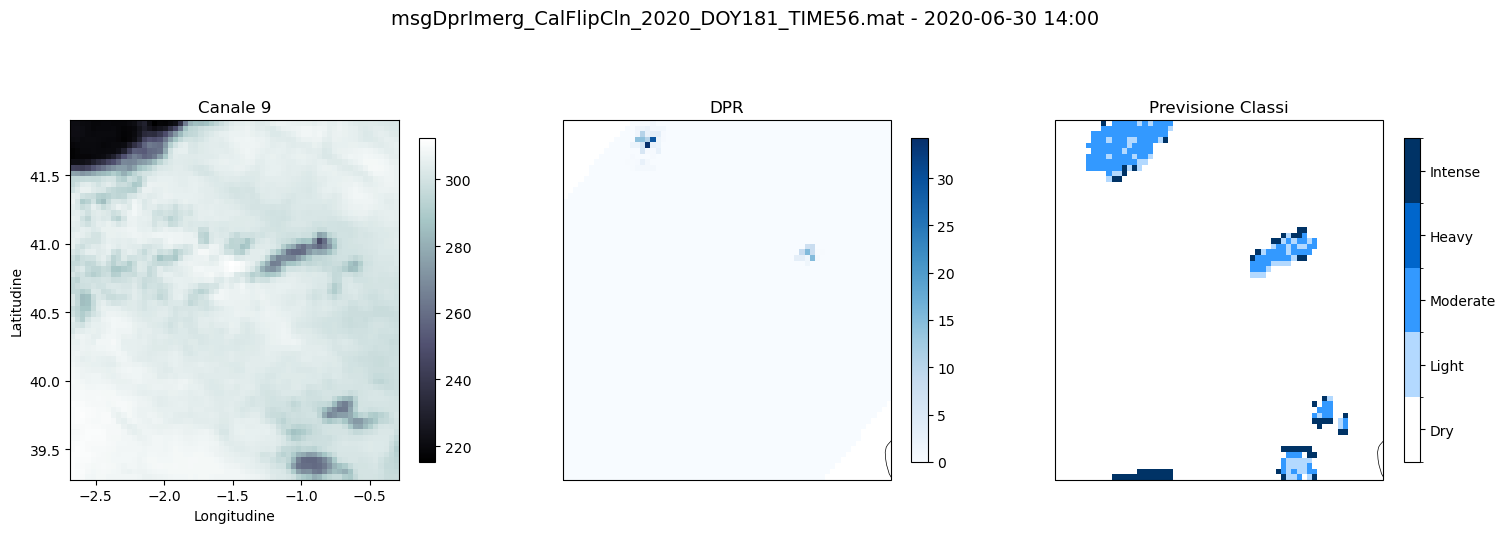

In [17]:
############# MAPPE CANALE 9-DPR-modello ###############

import os
import re
import pickle
import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from datetime import datetime, timedelta

# === PARAMETRI ===
cartella = r'C:\Users\user\Documents\TESI\datigrezzi\DATI_grezzi_2020\OUTPUT_1'
geo_dir = r'C:\Users\user\Documents\TESI\datigrezzi\DATI_grezzi_2020\Dati_processati'
output_maps_dir = r'C:\Users\user\Documents\TESI\datigrezzi\DATI_grezzi_2020\MAPPE_UNITE'
os.makedirs(output_maps_dir, exist_ok=True)

# === COSTANTI ===
DIM_IMMAGINE = 4096
base_date = datetime(2020, 1, 1)
classes = ['Dry', 'Light', 'Moderate', 'Heavy', 'Intense']
class_colors = ['#ffffff', '#b3d9ff', '#3399ff', '#0066cc', '#003366']
cmap_pred = mcolors.ListedColormap(class_colors)
bounds = np.arange(len(classes) + 1) - 0.5
norm = mcolors.BoundaryNorm(bounds, cmap_pred.N)

# === COORDINATE E TEMPI ===
with open(os.path.join(geo_dir, 'LAT.pickle'), 'rb') as f:
    LAT = pickle.load(f)
with open(os.path.join(geo_dir, 'LONG.pickle'), 'rb') as f:
    LONG = pickle.load(f)
with open(os.path.join(geo_dir, 'DAY.pickle'), 'rb') as f:
    DAY = pickle.load(f)
with open(os.path.join(geo_dir, 'TIME.pickle'), 'rb') as f:
    TIME = pickle.load(f)

# === INSERISCI y_pred e label_encoder PRIMA DI QUESTO SCRIPT ===
# y_pred_labels = label_encoder.transform(y_pred)
n_images = len(y_pred_labels) // DIM_IMMAGINE

# === ORDINAMENTO ===
def estrai_doy_time(nome_file):
    match = re.search(r"DOY(\d+)_TIME(\d+)", nome_file)
    if match:
        return int(match.group(1)), int(match.group(2))
    return float('inf'), float('inf')

file_ordinati = sorted(
    [f for f in os.listdir(cartella) if f.endswith('.mat')],
    key=estrai_doy_time
)

# === LOOP FILE ===
for i, nome_file in enumerate(file_ordinati):
    if i >= n_images:
        break

    try:
        data = sio.loadmat(os.path.join(cartella, nome_file))

        lat = np.rot90(data['12'].reshape(64, 64), k=1)
        lon = np.rot90(data['13'].reshape(64, 64), k=1)
        extent = [lon.min(), lon.max(), lat.min(), lat.max()]

        # === CREA FIGURA CON 3 ASSI CARTOPY ===
        fig = plt.figure(figsize=(18, 6))

        # --- Canale 9 (normale Matplotlib, senza confini) ---
        ax1 = fig.add_subplot(1, 3, 1)
        canale9 = np.rot90(data['9'].reshape(64, 64), k=1)
        im1 = ax1.imshow(canale9, cmap='bone', extent=extent)
        ax1.set_title('Canale 9')
        ax1.set_xlabel('Longitudine')
        ax1.set_ylabel('Latitudine')
        fig.colorbar(im1, ax=ax1, orientation='vertical', shrink=0.7)

        # --- DPR con Cartopy ---
        ax2 = fig.add_subplot(1, 3, 2, projection=ccrs.PlateCarree())
        canale_dpr = np.rot90(data['dpr'].reshape(64, 64), k=1)
        im2 = ax2.imshow(canale_dpr, cmap='Blues', extent=extent, transform=ccrs.PlateCarree())
        ax2.set_title('DPR')
        ax2.set_xlabel('Longitudine')
        ax2.set_ylabel('Latitudine')
        ax2.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax2.add_feature(cfeature.COASTLINE, linewidth=0.5)
        fig.colorbar(im2, ax=ax2, orientation='vertical', shrink=0.7)

        # --- Previsione con Cartopy ---
        ax3 = fig.add_subplot(1, 3, 3, projection=ccrs.PlateCarree())
        start_idx = i * DIM_IMMAGINE
        end_idx = start_idx + DIM_IMMAGINE
        pred_map = np.flipud(np.rot90(y_pred_labels[start_idx:end_idx].reshape((64, 64)), k=1))
        im3 = ax3.imshow(pred_map, cmap=cmap_pred, norm=norm, extent=extent, origin='lower', transform=ccrs.PlateCarree(), interpolation='nearest')
        ax3.set_title('Previsione Classi')
        ax3.set_xlabel('Longitudine')
        ax3.set_ylabel('Latitudine')
        ax3.add_feature(cfeature.BORDERS, linewidth=0.5)
        ax3.add_feature(cfeature.COASTLINE, linewidth=0.5)
        cbar = fig.colorbar(im3, ax=ax3, ticks=np.arange(len(classes)), orientation='vertical', shrink=0.7)
        cbar.ax.set_yticklabels(classes)

        # --- Titolo generale ---
        giorno = int(np.squeeze(DAY[i]))
        ora_slot = int(np.squeeze(TIME[i]))
        dt = base_date + timedelta(days=giorno)
        hh = (ora_slot * 15) // 60
        mm = (ora_slot * 15) % 60
        orario_str = f"{dt.strftime('%Y-%m-%d')} {hh:02d}:{mm:02d}"
        fig.suptitle(f"{nome_file} - {orario_str}", fontsize=14)

        plt.tight_layout(rect=[0, 0.03, 1, 0.95])
        output_path = os.path.join(output_maps_dir, f"tripla_{i:03d}_{dt.strftime('%Y%m%d')}_T{hh:02d}{mm:02d}.png")
        plt.savefig(output_path)
        plt.close()

    except Exception as e:
        print(f"Errore nel file {nome_file}: {e}")